# ***Project Name - Shopper Spectrum: Customer Segmentation and Product Recommendations in E-Commerce***


### ***Project Type - Unsupervised Learning (Clustering) + Recommendation System***

### ***Domain - E-Commerce and Retail Analytics***

### ***Contribution - Individual***

### ***Name - Mohit Singh Rajput***

### ***GitHub Link - https://github.com/Mohit-1307/Shopper-Spectrum***

## ***Problem Statement***

The global e-commerce industry generates vast amounts of transaction data daily, offering valuable insights into customer purchasing behaviours. Analysing this data helps identify meaningful customer segments and recommend relevant products to enhance customer experience and drive business growth.

This project examines one year of transaction data from an online retail business to uncover patterns in customer purchase behaviour, segment customers using Recency, Frequency, and Monetary (RFM) analysis, and develop a product recommendation system using item-based collaborative filtering. Beyond building these models, the project also validates the key modelling decisions quantitatively — testing whether the chosen preprocessing method actually outperforms an alternative, and measuring recommendation accuracy against a baseline — rather than relying on assumptions or qualitative impressions alone.

### ***Business Objectives***

- Segment customers into meaningful groups based on their purchase behaviour using RFM analysis.

- Compare KMeans, Hierarchical, Gaussian Mixture Model, and DBSCAN clustering algorithms and select the best performer.

- Build a product recommendation system using item-based collaborative filtering and cosine similarity.

- Identify High-Value, Regular, Occasional, and At-Risk customers to enable targeted marketing.

- Quantitatively validate key modelling decisions — comparing IQR-capping against a log-transform alternative for clustering, and benchmarking recommendation accuracy (Precision@K, Recall@K, Coverage) against a popularity baseline — to confirm choices with evidence rather than rationale alone.

- Deploy results through a Streamlit app for real-time predictions and product recommendations.

# ***Let's Begin !***

## ***1. Know Your Data***

### ***Import Libraries***

In [1]:
# pandas — core library for loading, cleaning, and manipulating tabular data
import pandas as pd

# numpy — numerical operations, array handling, and random seed control
import numpy as np

# matplotlib.pyplot — base plotting library for all charts and figures
import matplotlib.pyplot as plt

# seaborn — statistical visualisation on top of matplotlib (heatmaps, etc.)
import seaborn as sns

# warnings — used to suppress non-critical sklearn and pandas warnings
import warnings

# os — file system operations (creating directories, listing files)
import os

# joblib — saving and loading trained sklearn model objects to disk
import joblib


# KMeans — partition-based clustering algorithm (primary model)
# AgglomerativeClustering — hierarchical clustering using linkage methods
# DBSCAN — density-based clustering algorithm
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

# GaussianMixture — soft probabilistic clustering using Gaussian components
from sklearn.mixture import GaussianMixture

# StandardScaler — standardizes features to zero mean and unit variance
from sklearn.preprocessing import StandardScaler

# silhouette_score — measures how well each point fits its cluster (higher = better)
# davies_bouldin_score — ratio of within-cluster to between-cluster distances (lower = better)
# calinski_harabasz_score — ratio of between-cluster to within-cluster variance (higher = better)
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# PCA — reduces high-dimensional data to 2D or 3D for cluster visualisation
from sklearn.decomposition import PCA

# NearestNeighbors — used to compute k-distance plot for DBSCAN epsilon selection
from sklearn.neighbors import NearestNeighbors

# cosine_similarity — computes product-to-product similarity for the recommendation system
from sklearn.metrics.pairwise import cosine_similarity

# dendrogram, linkage — builds and plots hierarchical clustering tree
from scipy.cluster.hierarchy import dendrogram, linkage

# Axes3D — enables 3D scatter plot projection in matplotlib
from mpl_toolkits.mplot3d import Axes3D

# silhouette_samples — computes the silhouette coefficient for each individual sample to analyze cluster quality
from sklearn.metrics import silhouette_samples

# train_test_split — splits data into training and testing sets for model evaluation and validation
from sklearn.model_selection import train_test_split

# TfidfVectorizer — converts text into numerical TF-IDF feature vectors for text analysis and similarity calculations
from sklearn.feature_extraction.text import TfidfVectorizer

# Suppress non-critical warnings to keep output clean
warnings.filterwarnings('ignore')

# Show all columns when printing DataFrames
pd.set_option('display.max_columns', None)


# Create folders to store chart images and trained model artifacts
os.makedirs("images", exist_ok = True)

os.makedirs("models", exist_ok = True)


print("All libraries imported successfully.")

All libraries imported successfully.


### ***Dataset Loading***

In [2]:
# Load the dataset using latin1 encoding
# This encoding handles special characters present in product descriptions

df = pd.read_csv('online_retail.csv', encoding = 'latin1')

print("Dataset loaded successfully.")

print(f"Shape : {df.shape}")

Dataset loaded successfully.
Shape : (541909, 8)


### ***Dataset First View***

In [3]:
# Show the first five rows to understand the structure and column values

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


### ***Dataset Rows and Columns Count***

In [4]:
# Extract row and column counts separately for a clear summary

rows, columns = df.shape

print(f"Number of Rows    : {rows}")

print(f"Number of Columns : {columns}")

Number of Rows    : 541909
Number of Columns : 8


### ***Dataset Information***

In [5]:
# Show column names, non-null counts, and data types for every column

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 69.3 MB


### ***Duplicate Values***

In [6]:
# Count exact duplicate rows across all columns

duplicate_count = df.duplicated().sum()

print(f"Total Duplicate Rows : {duplicate_count}")

Total Duplicate Rows : 5268


### ***Missing Values / Null Values***

In [7]:
# Count missing values in each column

missing_values = df.isnull().sum()

print(missing_values)

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


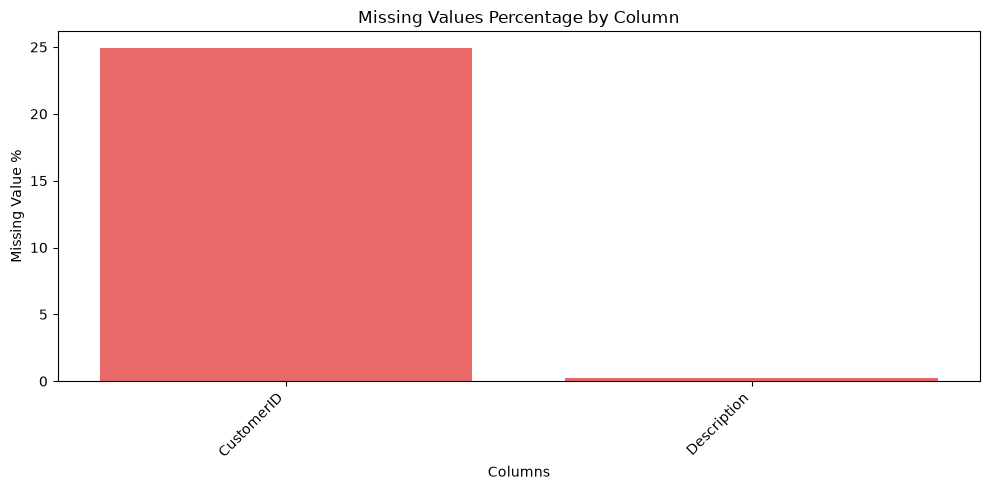

In [8]:
# Visualize missing value percentage per column as a bar chart
# Only columns with at least one missing value are shown

missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending = False)

missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize = (10, 5))

plt.bar(missing_pct.index, missing_pct.values, color = "#E96868")

plt.xticks(rotation = 45, ha = 'right')

plt.xlabel("Columns")

plt.ylabel("Missing Value %")

plt.title("Missing Values Percentage by Column")

plt.tight_layout()

plt.savefig("images/missing_values_percentage.png", dpi = 300, bbox_inches = "tight")

plt.show()

#### ***Key Insights from Dataset***

- The dataset has **541,909 rows and 8 columns**, covering retail transactions from December 2022 to December 2023.

- **CustomerID** has approximately **24.9% missing values** — these rows cannot be used for RFM analysis since there is no customer identifier to attribute purchases to.

- **Description** has approximately **0.27% missing values** — a small amount, but product names are required for the recommendation system and these rows will be dropped.

- **9,288 cancelled invoices** (InvoiceNo starting with 'C') are present in the data and must be excluded as they represent reversed transactions.

- **10,624 rows** have non-positive Quantity and **2,517 rows** have zero or negative UnitPrice — both are data quality issues and will be filtered out.

- **United Kingdom** dominates with approximately **91% of all transactions**, making this primarily a UK retail dataset.

- This is a combined **unsupervised clustering and collaborative filtering** project — no target label exists.

## ***2. Understanding Variables***

### ***Dataset Columns***

In [9]:
# Display all column names in the dataset

df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

### ***Describe Dataset***

In [10]:
# Statistical summary for all columns including object types

df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
InvoiceNo,541909,25900,573585,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,218.081158,-80995.0,1.0,3.0,10.0,80995.0
InvoiceDate,541909,23260,2023-10-31 14:41:00,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,1713.600303,12346.0,13953.0,15152.0,16791.0,18287.0
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### ***Variables Description***

| Column | Type | Description |
|--------|------|-------------|
| `InvoiceNo` | object | Transaction number. Values starting with 'C' indicate cancellations |
| `StockCode` | object | Unique product or item code |
| `Description` | object | Name of the product |
| `Quantity` | int64 | Number of units purchased per line — can be negative for returns |
| `InvoiceDate` | object | Date and time of the transaction (Dec 2022 to Dec 2023) |
| `UnitPrice` | float64 | Price per unit in GBP — can be zero or negative for adjustments |
| `CustomerID` | float64 | Unique customer identifier — stored as float due to missing values |
| `Country` | object | Country where the customer is based |

#### ***Key Insights from df.describe()***

- `Quantity` has a minimum of **-80,995**, confirming that negative values from returns are present and need filtering.

- `UnitPrice` has a minimum of **-11,062.06**, confirming that adjustments and errors are present in the price column.

- `CustomerID` is stored as **float64** because missing values prevent integer storage — it will be cast to int after dropping nulls.

- The **top country is United Kingdom** with a frequency of 495,478 transactions out of 541,909 total.

### ***Checking Unique Values for Each Variable***

In [11]:
# Print the number of unique values in each column
# This helps understand the cardinality of categorical and numeric columns

for col in df.columns:

    print(f"  {col:20s} : {df[col].nunique()} unique values")

    print("-" * 45)

  InvoiceNo            : 25900 unique values
---------------------------------------------
  StockCode            : 4070 unique values
---------------------------------------------
  Description          : 4223 unique values
---------------------------------------------
  Quantity             : 722 unique values
---------------------------------------------
  InvoiceDate          : 23260 unique values
---------------------------------------------
  UnitPrice            : 1630 unique values
---------------------------------------------
  CustomerID           : 4372 unique values
---------------------------------------------
  Country              : 38 unique values
---------------------------------------------


## ***3. Data Wrangling***

### ***Data Preprocessing and Cleaning***

In [12]:
# Step 1 — Create a working copy so the original raw dataset is never modified

df1 = df.copy()


# Step 2 — Drop rows where CustomerID is missing
# RFM analysis requires a customer identifier to attribute purchases

df1.dropna(subset = ['CustomerID'], inplace = True)


# Step 3 — Drop rows where Description is missing
# Product names are required for building the recommendation system

df1.dropna(subset = ['Description'], inplace = True)


# Step 4 — Remove cancelled invoices (InvoiceNo begins with 'C')
# Cancellations represent reversed transactions and should not count as purchases

df1 = df1[~df1['InvoiceNo'].astype(str).str.startswith('C')]


# Step 5 — Remove rows with non-positive Quantity
# Zero or negative quantities are returns, stock adjustments, or entry errors

df1 = df1[df1['Quantity'] > 0]


# Step 6 — Remove rows with non-positive UnitPrice
# Prices of zero or below are data quality issues, not real sales

df1 = df1[df1['UnitPrice'] > 0]


# Step 7 — Parse InvoiceDate as datetime so date arithmetic works correctly

df1['InvoiceDate'] = pd.to_datetime(df1['InvoiceDate'])


# Step 8 — Convert CustomerID from float to integer for cleaner display and groupby

df1['CustomerID'] = df1['CustomerID'].astype(int)


# Step 9 — Create TotalPrice = Quantity × UnitPrice
# This derived column is used to compute the Monetary value in RFM

df1['TotalPrice'] = df1['Quantity'] * df1['UnitPrice']


# Step 10 — Drop any remaining exact duplicate rows

df1.drop_duplicates(inplace = True)


print("Preprocessing complete.")

print(f"Shape after cleaning : {df1.shape}")

print()

print(df1.head())

Preprocessing complete.
Shape after cleaning : (392692, 9)

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  TotalPrice  
0 2022-12-01 08:26:00       2.55       17850  United Kingdom       15.30  
1 2022-12-01 08:26:00       3.39       17850  United Kingdom       20.34  
2 2022-12-01 08:26:00       2.75       17850  United Kingdom       22.00  
3 2022-12-01 08:26:00       3.39       17850  United Kingdom       20.34  
4 2022-12-01 08:26:00       3.39       17850  United Kingdom       20.34  


#### ***Data Wrangling Summary***

| Step | Action | Rows Affected | Reason |
|------|--------|---------------|--------|
| Copy | `df.copy()` | — | Preserve original data |
| Drop null CustomerID | `dropna` | ~135,080 removed | Cannot compute RFM without a customer identifier |
| Drop null Description | `dropna` | ~1,454 removed | Product names needed for recommendation system |
| Remove cancellations | Filter `InvoiceNo` starts with 'C' | ~9,288 removed | Reversed transactions must not count as sales |
| Remove qty ≤ 0 | Filter `Quantity > 0` | Invalid records removed | Returns and data errors skew purchase frequency |
| Remove price ≤ 0 | Filter `UnitPrice > 0` | Invalid records removed | Negative or zero prices are data entry errors |
| Convert InvoiceDate | `pd.to_datetime` | — | Required for Recency calculation |
| Convert CustomerID | `.astype(int)` | — | Cleaner display and groupby |
| Add TotalPrice | `Quantity × UnitPrice` | — | Monetary value for RFM computation |
| Drop duplicates | `drop_duplicates` | Exact duplicates removed | Final data quality step |

#### ***Key Insights***

- Approximately **27% of the original dataset was removed** during cleaning, almost entirely due to missing CustomerIDs.

- The cleaned dataset of roughly **392,700 transaction lines across 4,338 unique customers** is the foundation for both the clustering model and the recommendation system.

- `TotalPrice` is the single most important derived column — it is used directly in every downstream monetary calculation.

## ***4. Data Visualization, Storytelling and Experimenting with Charts***

### ***Univariate Analysis***

### ***Chart - 1 : Transaction Volume by Country***

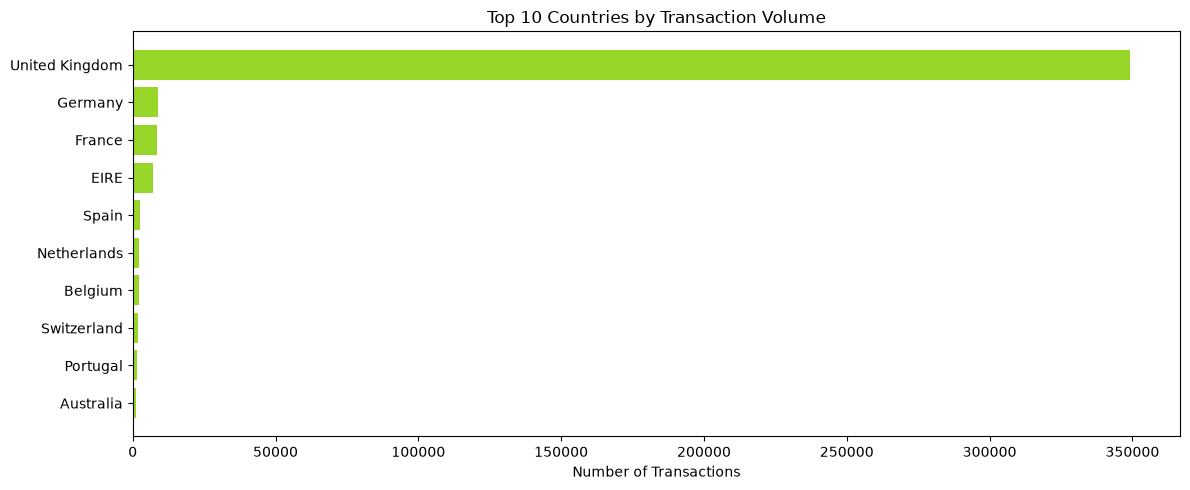

In [13]:
# Chart - 1 : Count of transaction lines per country, top 10 only

country_counts = df1['Country'].value_counts().head(10)

plt.figure(figsize = (12, 5))

# Horizontal bar makes long country names readable without overlap
plt.barh(country_counts.index[::-1], country_counts.values[::-1], color = "#98d72a")

plt.xlabel("Number of Transactions")

plt.title("Top 10 Countries by Transaction Volume")

plt.tight_layout()

plt.savefig("images/chart1_transaction_volume_by_country.png", dpi = 300, bbox_inches = "tight")

plt.show()

#### ***1. Why was this chart selected for analysis?***

A horizontal bar chart shows rank ordering clearly across countries without label overlap, making it immediately obvious which market dominates.

#### ***2. What are the key insights from this chart?***

- **United Kingdom** accounts for over 90% of all transactions, making it the clear dominant market by a very large margin.

- Germany, France, and EIRE are the next largest markets but contribute only a small fraction of UK transaction volumes.

- The steep drop-off after the UK confirms this is a UK-centric retail business with limited international penetration.

#### ***3. What positive business impact can these insights create?***

Understanding that 91% of transactions come from the UK means segmentation and recommendation efforts should be primarily optimised for UK customer behaviour patterns, while international markets may benefit from simplified, separate strategies.

#### ***4. Are there any potential risks or negative business impacts?***

Heavy geographic concentration creates revenue risk. Any UK-specific disruption — economic downturn, regulatory change, or logistics failure — could have an outsized impact on total business performance.

### ***Chart - 2 : Top 10 Best-Selling Products by Quantity***

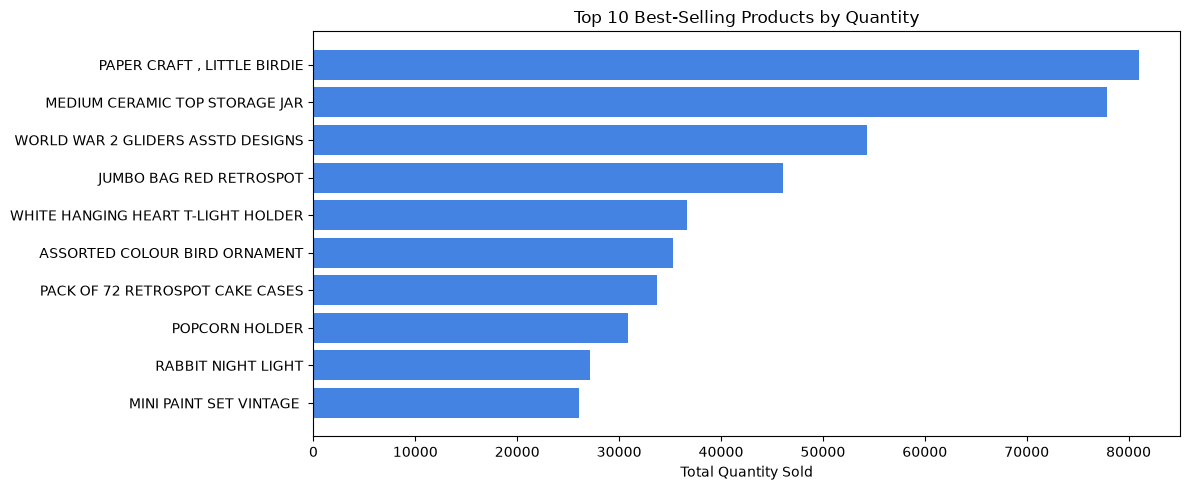

In [14]:
# Chart - 2 : Total units sold per product description, top 10 only

top_products = df1.groupby('Description')['Quantity'].sum().sort_values(ascending = False).head(10)

plt.figure(figsize = (12, 5))

plt.barh(top_products.index[::-1], top_products.values[::-1], color = "#4483e2")

plt.xlabel("Total Quantity Sold")

plt.title("Top 10 Best-Selling Products by Quantity")

plt.tight_layout()

plt.savefig("images/chart2_top10_products_quantity.png", dpi = 300, bbox_inches = "tight")

plt.show()

#### ***1. Why was this chart selected for analysis?***

A horizontal bar chart ranks products by total volume, making it easy to identify which SKUs drive the most sales activity regardless of price.

#### ***2. What are the key insights from this chart?***

- A small number of products dominate total sales volume, consistent with the Pareto principle — a few items drive the majority of unit sales.

- Paper craft items, gift bags, and small decorative homeware items occupy the top positions, reflecting the retailer's core product category.

- These high-volume products form the backbone of inventory planning and are the most co-purchased items in the recommendation system.

#### ***3. What positive business impact can these insights create?***

Ensuring permanent stock availability for top-selling products prevents lost sales. These items are also ideal anchors for bundle promotions and upsell opportunities since customers are already buying them at scale.

#### ***4. Are there any potential risks or negative business impacts?***

Concentration of sales in a few products creates supply chain vulnerability. A shortage of any top seller during peak season could significantly reduce overall transaction volume.

### ***Chart - 3 : Monthly Transaction Volume Over Time***

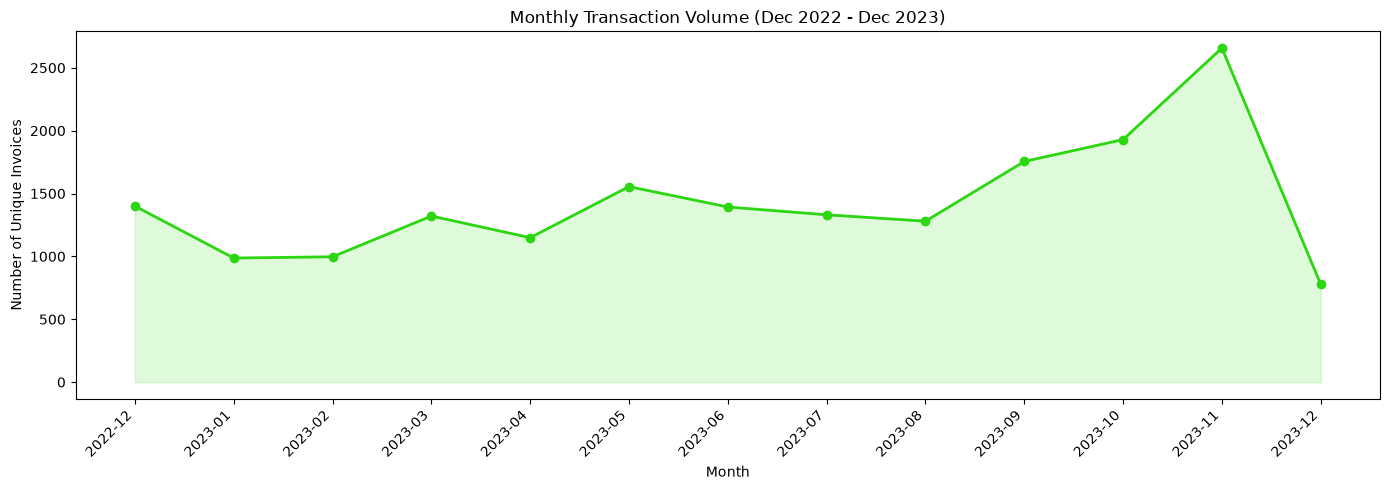

In [15]:
# Chart - 3 : Count of unique invoices per calendar month to show transaction trends

# Extract year-month period from InvoiceDate for monthly aggregation
df1['YearMonth'] = df1['InvoiceDate'].dt.to_period('M')

# Count distinct invoices per month (not transaction lines, to avoid double-counting)
monthly_transactions = df1.groupby('YearMonth')['InvoiceNo'].nunique()

plt.figure(figsize = (14, 5))

plt.plot(
    
    monthly_transactions.index.astype(str),
    
    monthly_transactions.values,
    
    marker = 'o', color = "#2CD712", linewidth = 2
    
)

# Fill area under the line for better visual impact
plt.fill_between(
    
    monthly_transactions.index.astype(str),
    
    monthly_transactions.values,
    
    alpha = 0.15, color = "#2CD712"
    
)

plt.xlabel("Month")

plt.ylabel("Number of Unique Invoices")

plt.title("Monthly Transaction Volume (Dec 2022 - Dec 2023)")

plt.xticks(rotation = 45, ha = 'right')

plt.tight_layout()

plt.savefig("images/chart3_monthly_transaction_volume.png", dpi = 300, bbox_inches = "tight")

plt.show()

#### ***1. Why was this chart selected for analysis?***

A line chart with fill is the most natural way to visualise time-series trends, making seasonality peaks and troughs immediately visible.

#### ***2. What are the key insights from this chart?***

- Transaction volume peaks sharply in **November**, consistent with Christmas shopping season demand.

- A clear **dip in January** follows the November peak, typical of post-holiday retail slowdown.

- Volume grows steadily from mid-year (July onwards), suggesting a build-up phase leading into the festive period.

#### ***3. What positive business impact can these insights create?***

Seasonal patterns enable smarter inventory preparation. Stocking up ahead of October and launching promotional campaigns in September can help capture the full November peak rather than running out of stock mid-surge.

#### ***4. Are there any potential risks or negative business impacts?***

Strong seasonality creates unpredictable annual cash flow. Without adequate inventory ahead of November, stockouts during the highest-demand period result in direct revenue loss that cannot be recovered later in the year.

### ***Chart - 4 : TotalPrice Distribution Per Transaction Line***

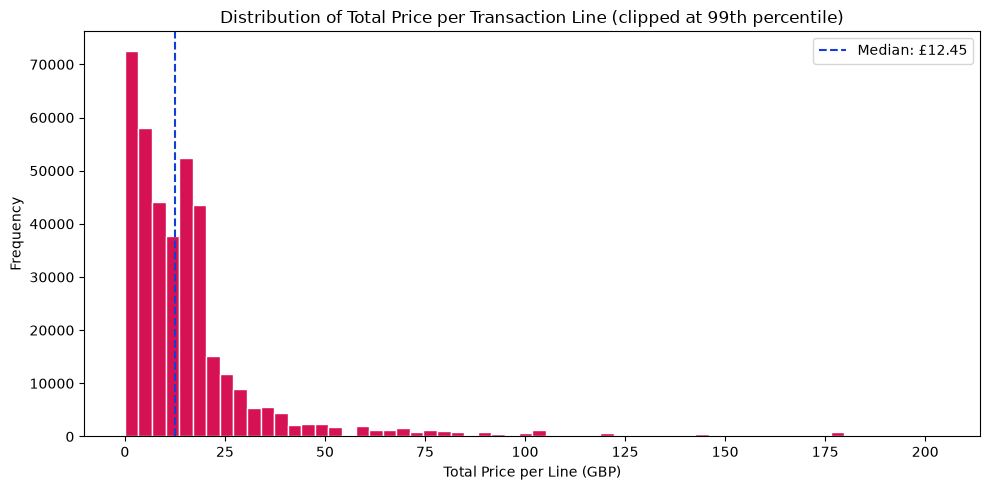

In [16]:
# Chart - 4 : Histogram of transaction line values to understand typical order size

# Clip at 99th percentile to prevent a few large outliers from compressing the histogram
upper_limit = df1['TotalPrice'].quantile(0.99)

clipped_price = df1['TotalPrice'][df1['TotalPrice'] <= upper_limit]

# Calculate median as a robust central tendency measure for a right-skewed distribution
median_val = df1['TotalPrice'].median()

plt.figure(figsize = (10, 5))

plt.hist(clipped_price, bins = 60, color = "#D71254", edgecolor = 'white')

# Add median reference line since mean is pulled right by large outliers
plt.axvline(median_val, color = "#123DD7", linestyle = '--', label = f'Median: £{median_val:.2f}')

plt.xlabel("Total Price per Line (GBP)")

plt.ylabel("Frequency")

plt.title("Distribution of Total Price per Transaction Line (clipped at 99th percentile)")

plt.legend()

plt.tight_layout()

plt.savefig("images/chart4_totalprice_distribution.png", dpi = 300, bbox_inches = "tight")

plt.show()

#### ***1. Why was this chart selected for analysis?***

A histogram with a median reference line shows both the shape of the transaction value distribution and a reliable central tendency measure in a single view.

#### ***2. What are the key insights from this chart?***

- The distribution is **heavily right-skewed** — the vast majority of transaction lines are under £20, with a long tail of high-value bulk orders.

- The median transaction line value is low, confirming that this is a high-volume, low-unit-price retail model rather than a premium goods business.

- The right tail, even after clipping at the 99th percentile, indicates the presence of wholesale or B2B orders with significantly higher values.

#### ***3. What positive business impact can these insights create?***

Knowing that most orders are small-ticket allows the business to set minimum order thresholds for free shipping. Even a small increase in average basket size across a large number of low-value orders has a compounding positive effect on revenue.

#### ***4. Are there any potential risks or negative business impacts?***

A high volume of low-value transactions means profitability is highly sensitive to per-order operational costs. Any increase in fulfilment, packaging, or shipping costs quickly erodes margins on small orders.

### ***Chart - 5 : Top 10 Products by Total Revenue***

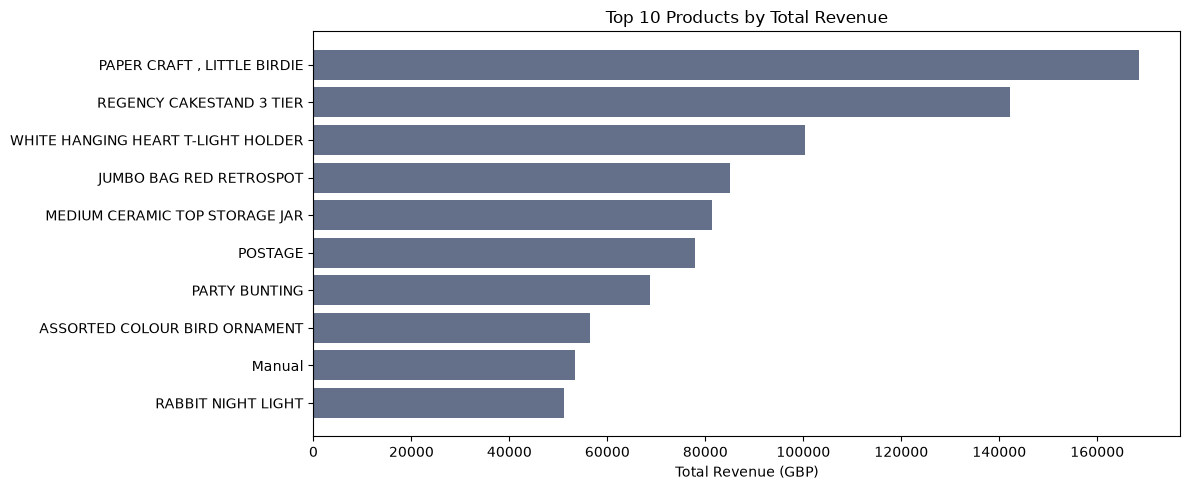

In [17]:
# Chart - 5 : Total revenue (GBP) generated per product, top 10 only

product_revenue = df1.groupby('Description')['TotalPrice'].sum().sort_values(ascending = False).head(10)

plt.figure(figsize = (12, 5))

plt.barh(product_revenue.index[::-1], product_revenue.values[::-1], color = "#646f8a")

plt.xlabel("Total Revenue (GBP)")

plt.title("Top 10 Products by Total Revenue")

plt.tight_layout()

plt.savefig("images/chart5_top10_products_revenue.png", dpi = 300, bbox_inches = "tight")

plt.show()

#### ***1. Why was this chart selected for analysis?***

Revenue ranking often differs substantially from quantity ranking. This chart reveals which products actually drive monetary value, rather than just unit volume.

#### ***2. What are the key insights from this chart?***

- Several products that rank highly by revenue do not appear in the top 10 by quantity, indicating some higher-priced items contribute disproportionate revenue despite moderate volumes.

- A small number of products account for a large share of total revenue, consistent with the Pareto pattern seen in the quantity chart.

#### ***3. What positive business impact can these insights create?***

Revenue-driving products deserve premium treatment in merchandising, stock prioritisation, and marketing. A promotional campaign around a high-revenue product has an outsized financial return compared to promoting a high-volume but low-price item.

#### ***4. Are there any potential risks or negative business impacts?***

If top revenue products are heavily discounted to drive volume, the margin advantage is quickly lost. Pricing discipline on high-revenue products is critical to maintaining overall profitability.

### ***Bivariate Analysis***

### ***Chart - 6 : Revenue by Country — Top 5***

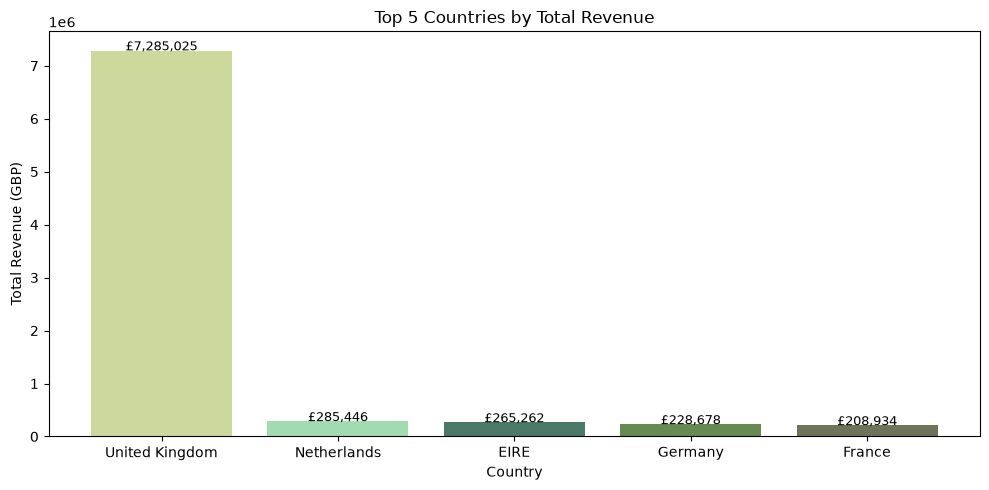

In [18]:
# Chart - 6 : Total revenue per country, restricted to the top 5 markets

country_revenue = df1.groupby('Country')['TotalPrice'].sum().sort_values(ascending = False).head(5)

plt.figure(figsize = (10, 5))

# Use a gradient of colours to visually separate the five bars
bars = plt.bar(
    
    country_revenue.index,
    
    country_revenue.values,
    
    color = ['#cdd99c', "#a2dbaf", "#4b7867", "#678a53", "#6e7459"]
    
)

plt.xlabel("Country")

plt.ylabel("Total Revenue (GBP)")

plt.title("Top 5 Countries by Total Revenue")

# Annotate each bar with its exact revenue value
for b in bars:

    plt.text(

        b.get_x() + b.get_width() / 2,

        b.get_height() + 5000,

        f'£{b.get_height():,.0f}',

        ha = 'center', fontsize = 9

    )

plt.tight_layout()

plt.savefig("images/chart6_revenue_by_country.png", dpi = 300, bbox_inches = "tight")

plt.show()

#### ***1. Why was this chart selected for analysis?***

Annotated bar chart quantifies exact revenue contribution per market, enabling data-driven geographic prioritisation that transaction volume alone cannot provide.

#### ***2. What are the key insights from this chart?***

- The **UK contributes the overwhelming majority of total revenue**, confirming it as the primary market for both transaction count and revenue.

- Netherlands and EIRE show relatively high revenue compared to their transaction count, suggesting these markets contain wholesale or B2B buyers with large average order values.

#### ***3. What positive business impact can these insights create?***

High-revenue international markets with fewer transactions are likely B2B wholesale accounts worth dedicated account management. Even a small improvement in their order frequency can have an outsized revenue impact without increasing customer acquisition costs.

#### ***4. Are there any potential risks or negative business impacts?***

Revenue concentration in the UK makes the business vulnerable to UK-specific economic or regulatory disruptions. A diversification strategy into higher-potential international markets would reduce this dependency.

### ***Chart - 7 : Average Order Value by Country — Top 10***

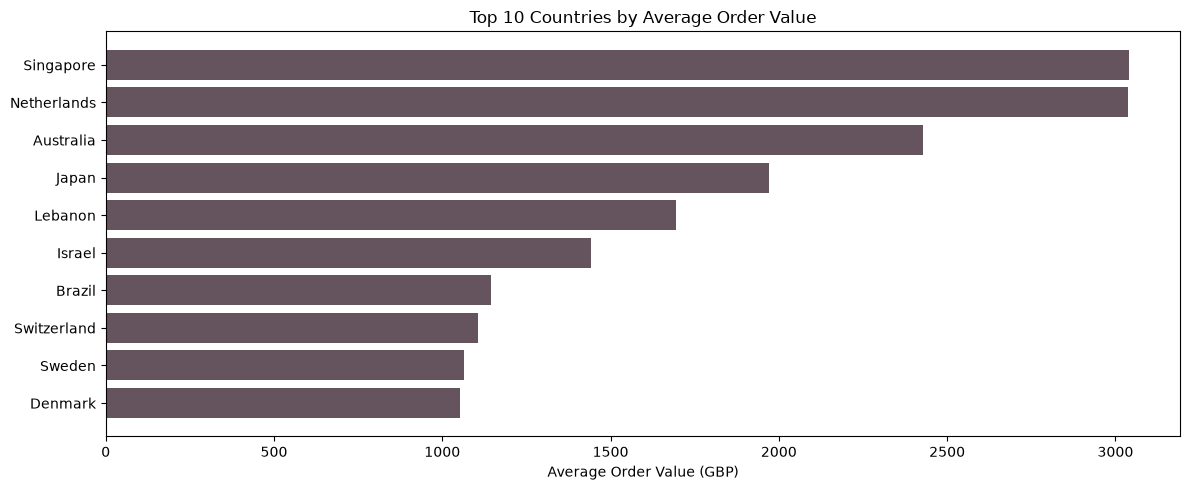

In [19]:
# Chart - 7 : Mean total invoice value per country, top 10 markets only
# Average order value = total revenue per invoice, averaged across all invoices for that country

order_value = df1.groupby(['Country', 'InvoiceNo'])['TotalPrice'].sum().reset_index()

avg_order_value = order_value.groupby('Country')['TotalPrice'].mean().sort_values(ascending = False).head(10)

plt.figure(figsize = (12, 5))

plt.barh(avg_order_value.index[::-1], avg_order_value.values[::-1], color = "#65535d")

plt.xlabel("Average Order Value (GBP)")

plt.title("Top 10 Countries by Average Order Value")

plt.tight_layout()

plt.savefig("images/chart7_avg_order_value_by_country.png", dpi = 300, bbox_inches = "tight")

plt.show()

#### ***1. Why was this chart selected for analysis?***

Average order value removes the volume bias present in total revenue and reveals which markets have the highest spend per transaction — a key indicator of wholesale vs. retail buyer behaviour.

#### ***2. What are the key insights from this chart?***

- Several smaller international markets have significantly higher average order values than the UK, strongly suggesting they contain B2B wholesale buyers who place bulk orders.

- The UK, despite dominating transaction count and total revenue, does not have the highest average order value — confirming it has a large retail customer base with many small orders.

#### ***3. What positive business impact can these insights create?***

Markets with high average order values are operationally efficient — fewer transactions, larger revenue per shipment. A dedicated wholesale pricing or account management strategy for these markets can boost revenue without proportionally increasing operational costs.

#### ***4. Are there any potential risks or negative business impacts?***

Dependence on a small number of high-value wholesale buyers in international markets creates concentration risk. Losing a single large B2B account in such a market could cause a significant revenue shortfall.

### ***Chart - 8 : Transaction Volume by Hour of Day***

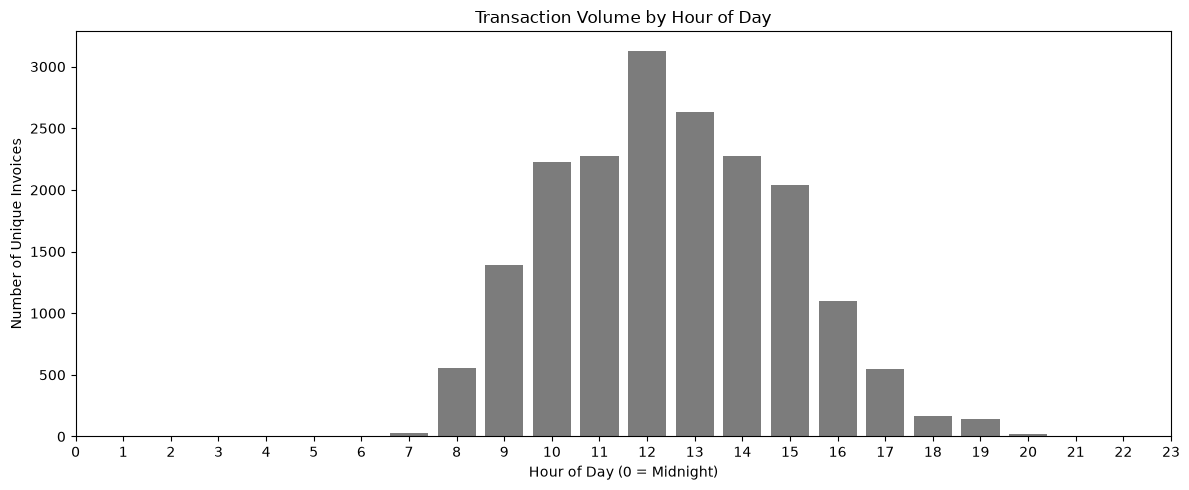

In [20]:
# Chart - 8 : Unique invoice count per hour to show intraday demand patterns

# Extract the hour component from InvoiceDate
df1['Hour'] = df1['InvoiceDate'].dt.hour

# Count distinct invoices per hour (not lines, to represent actual order events)
hourly_counts = df1.groupby('Hour')['InvoiceNo'].nunique()

plt.figure(figsize = (12, 5))

plt.bar(hourly_counts.index, hourly_counts.values, color = "#7c7c7c")

plt.xlabel("Hour of Day (0 = Midnight)")

plt.ylabel("Number of Unique Invoices")

plt.title("Transaction Volume by Hour of Day")

# Show all 24-hour labels on x-axis
plt.xticks(range(0, 24))

plt.tight_layout()

plt.savefig("images/chart8_hourly_transaction_volume.png", dpi = 300, bbox_inches = "tight")

plt.show()

#### ***1. Why was this chart selected for analysis?***

A 24-hour bar chart reveals intraday demand patterns, which directly inform decisions about marketing email timing, customer support staffing, and operational scheduling.

#### ***2. What are the key insights from this chart?***

- Transaction volume is concentrated between **10 AM and 2 PM**, confirming that customers (likely B2B buyers) place orders during business hours.

- There is almost zero activity between midnight and 6 AM, ruling out any meaningful overnight or international timezone-driven activity.

- A secondary rise around 3–4 PM represents a late-afternoon ordering wave before the end of the working day.

#### ***3. What positive business impact can these insights create?***

Scheduling promotional emails and flash sales to land at 9–10 AM maximises the probability of being read immediately before the peak ordering window. Customer support staffing aligned to the 10 AM–3 PM peak ensures quick response times during the busiest period.

#### ***4. Are there any potential risks or negative business impacts?***

If the business is planning to serve B2C or international customers in different timezones, the current infrastructure and support model may not be suited to handling late-night or early-morning orders.

### ***Chart - 9 : Revenue by Day of Week***

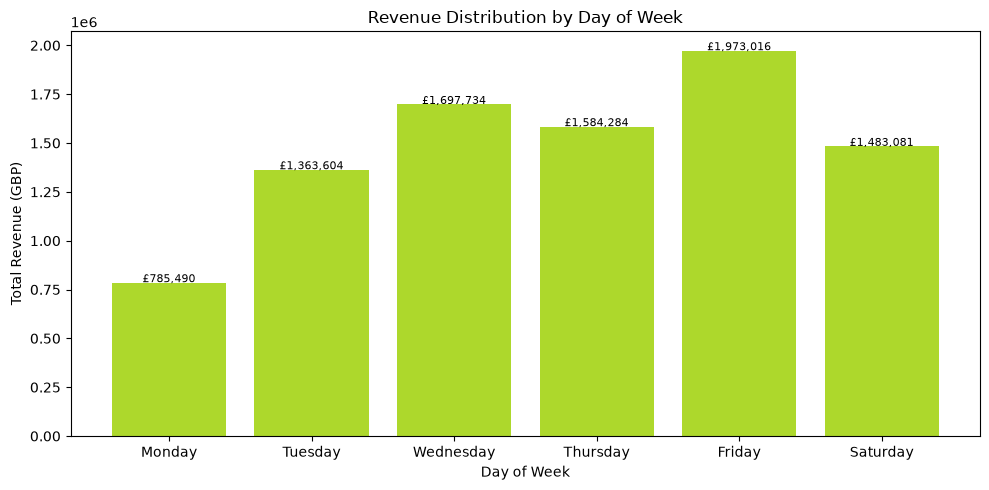

In [21]:
# Chart - 9 : Total revenue aggregated by day of the week

# Extract the numeric day of week (0 = Monday, 6 = Sunday)
df1['DayOfWeek'] = df1['InvoiceDate'].dt.dayofweek

day_labels = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

daily_revenue = df1.groupby('DayOfWeek')['TotalPrice'].sum()

plt.figure(figsize = (10, 5))

bars = plt.bar(
    
    [day_labels[i] for i in daily_revenue.index],
    
    daily_revenue.values,
    
    color = "#add82c"
    
)

plt.xlabel("Day of Week")

plt.ylabel("Total Revenue (GBP)")

plt.title("Revenue Distribution by Day of Week")

# Annotate each bar with its exact revenue in thousands
for b in bars:

    plt.text(

        b.get_x() + b.get_width() / 2,

        b.get_height() + 2000,

        f'£{b.get_height():,.0f}',

        ha = 'center', 

        fontsize = 8

    )

plt.tight_layout()

plt.savefig("images/chart9_revenue_by_day_of_week.png", dpi = 300, bbox_inches = "tight")

plt.show()

#### ***1. Why was this chart selected for analysis?***

Day-of-week analysis reveals the weekly purchasing rhythm and shows which days drive the most revenue, informing campaign timing and operational planning.

#### ***2. What are the key insights from this chart?***

- **Weekdays (Monday through Thursday)** generate significantly more revenue than weekends, reinforcing the B2B buying pattern seen in the hourly chart.

- **Sunday generates almost zero revenue**, confirming that this business operates on a weekday-only commercial cycle.

- Thursday tends to be the strongest revenue day, possibly driven by end-of-week procurement orders.

#### ***3. What positive business impact can these insights create?***

Concentrating promotional campaigns, product launches, and targeted email sends on Tuesday through Thursday maximises their reach and conversion rates. Weekend campaigns would largely be wasted on this customer base.

#### ***4. Are there any potential risks or negative business impacts?***

The complete absence of weekend activity creates weekly cash flow unevenness. If the business were to expand into B2C segments, it would need a fundamentally different operational model to handle weekend demand.

### ***Chart - 10 : Monthly Revenue Trend***

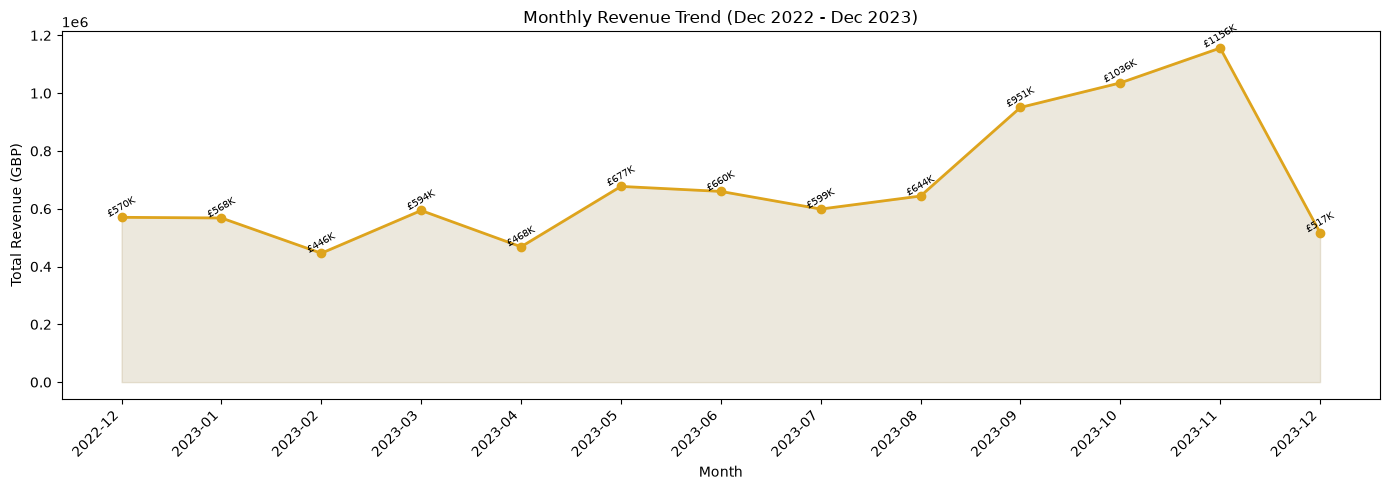

In [22]:
# Chart - 10 : Total revenue per calendar month to show financial performance over time

monthly_revenue = df1.groupby('YearMonth')['TotalPrice'].sum()

plt.figure(figsize = (14, 5))

plt.plot(
    
    monthly_revenue.index.astype(str),
    
    monthly_revenue.values,
    
    marker = 'o', color = "#dea41d", linewidth = 2
    
)

# Fill area under the line for visual emphasis
plt.fill_between(

    monthly_revenue.index.astype(str),

    monthly_revenue.values,

    alpha = 0.15, color = "#85661d"

)

# Annotate each monthly data point with its revenue in thousands
for idx, val in monthly_revenue.items():

    plt.text(str(idx), val + 1500, f'£{val / 1000:.0f}K', ha = 'center', fontsize = 7, rotation = 30)

plt.xlabel("Month")

plt.ylabel("Total Revenue (GBP)")

plt.title("Monthly Revenue Trend (Dec 2022 - Dec 2023)")

plt.xticks(rotation = 45, ha = 'right')

plt.tight_layout()

plt.savefig("images/chart10_monthly_revenue_trend.png", dpi = 300, bbox_inches = "tight")

plt.show()

#### ***1. Why was this chart selected for analysis?***

A monthly revenue trend chart annotated with actual values is the most direct executive-level summary of business financial performance over the year.

#### ***2. What are the key insights from this chart?***

- Revenue peaks sharply in **November**, which is the single most important revenue month in the entire dataset.

- Revenue is broadly stable between April and September before the Q4 surge begins in October.

- December 2023 shows a truncated dataset (only the first nine days are included), so the sharp drop is expected and not a real decline.

#### ***3. What positive business impact can these insights create?***

Preparing inventory, staffing, and promotional campaigns specifically for October–November can significantly increase revenue capture during the highest-opportunity window. Locking in customer loyalty earlier in Q3 can drive a higher November peak.

#### ***4. Are there any potential risks or negative business impacts?***

Revenue concentration in a single month means any operational failure in November — stockouts, website issues, or shipping delays — could disproportionately damage the entire year's financial result.

### ***Chart - 11 : Unique Customers and Products Per Month***

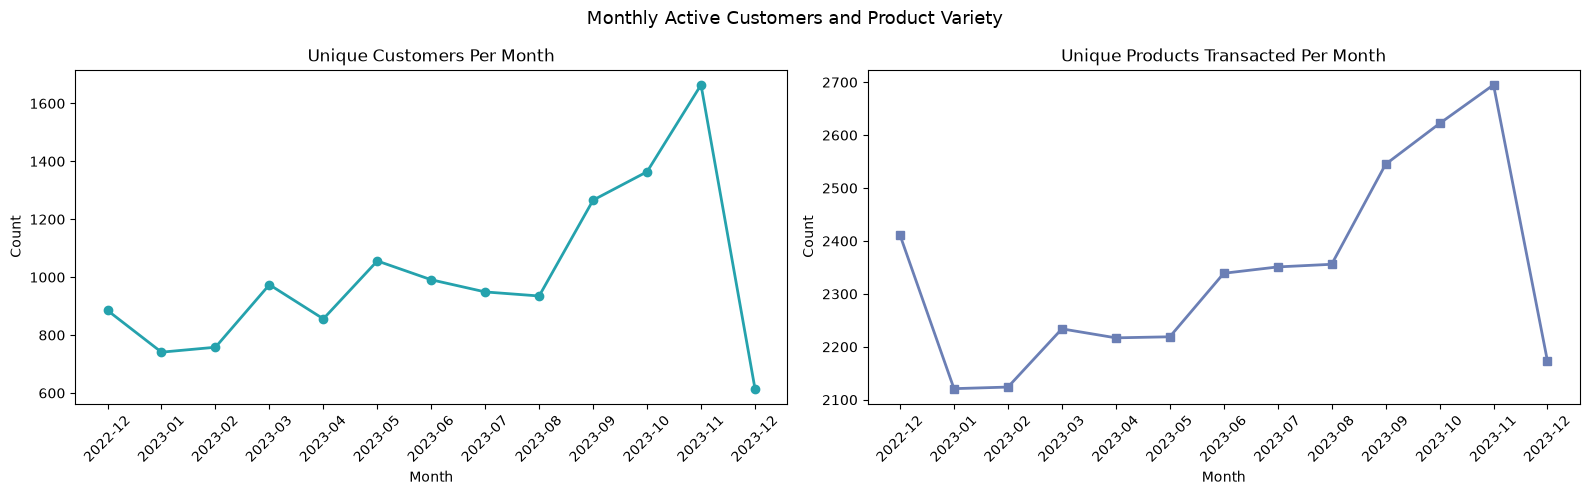

In [23]:
# Chart - 11 : Track how many unique customers and unique products were active each month

monthly_customers = df1.groupby('YearMonth')['CustomerID'].nunique()

monthly_products  = df1.groupby('YearMonth')['StockCode'].nunique()

fig, axes = plt.subplots(1, 2, figsize = (16, 5))

# Left panel — unique active customers per month
axes[0].plot(
    
    monthly_customers.index.astype(str),
    
    monthly_customers.values,
    
    marker = 'o', color = "#25a2ad", linewidth = 2
    
)

axes[0].set_title("Unique Customers Per Month")

axes[0].set_xlabel("Month")

axes[0].set_ylabel("Count")

axes[0].tick_params(axis = 'x', rotation = 45)

# Right panel — unique products transacted per month
axes[1].plot(
    
    monthly_products.index.astype(str),
    
    monthly_products.values,
    
    marker = 's', color = '#6b7fb5', linewidth = 2
    
)

axes[1].set_title("Unique Products Transacted Per Month")

axes[1].set_xlabel("Month")

axes[1].set_ylabel("Count")

axes[1].tick_params(axis = 'x', rotation = 45)

plt.suptitle("Monthly Active Customers and Product Variety", fontsize = 13)

plt.tight_layout()

plt.savefig("images/chart11_monthly_customers_products.png", dpi = 300, bbox_inches = "tight")

plt.show()

#### ***1. Why was this chart selected for analysis?***

Tracking customer count and product variety together shows whether volume growth is driven by more customers, broader product engagement, or both simultaneously.

#### ***2. What are the key insights from this chart?***

- Both unique customers and unique products peak in **November**, confirming that the Christmas season drives both customer acquisition and catalogue exploration simultaneously.

- Product variety follows the same seasonal pattern as customer count, suggesting that customers who shop during the peak season explore more of the catalogue than off-season buyers.

#### ***3. What positive business impact can these insights create?***

Introducing new seasonal product ranges in October can build catalogue breadth ahead of the November peak. Customers who engage with more products tend to have higher basket values and are more likely to return.

#### ***4. Are there any potential risks or negative business impacts?***

The sharp drops in both active customers and product variety in January indicate the business is heavily event-driven. Without year-round retention strategies, customer engagement between seasonal peaks is low.

### ***Chart - 12 : Top 15 Customers by Total Spend***

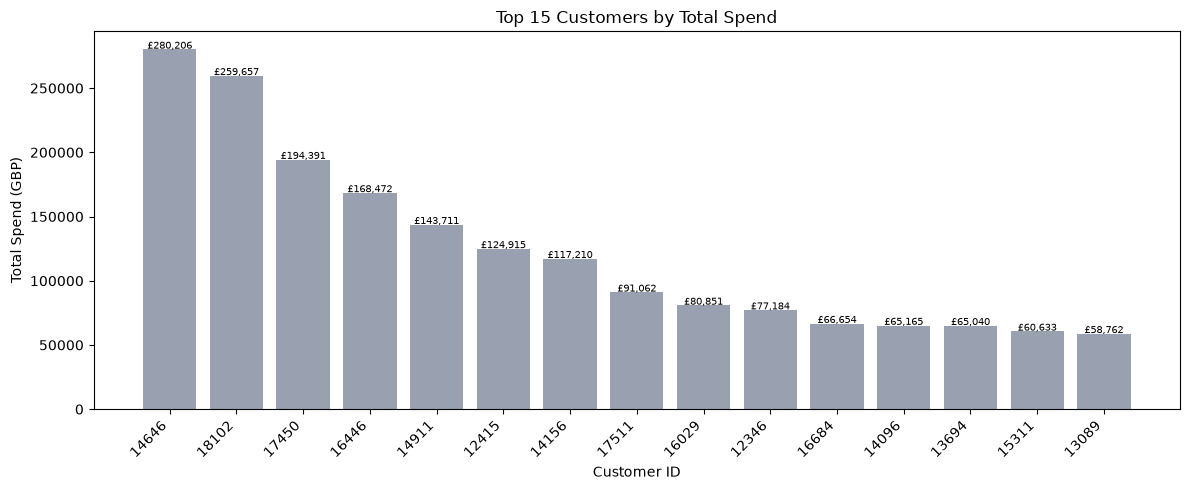

In [24]:
# Chart - 12 : Identify the highest-spending customers to quantify revenue concentration

top_customers = df1.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending = False).head(15)

plt.figure(figsize = (12, 5))

bars = plt.bar(top_customers.index.astype(str), top_customers.values, color = "#99A1B1")

plt.xlabel("Customer ID")

plt.ylabel("Total Spend (GBP)")

plt.title("Top 15 Customers by Total Spend")

plt.xticks(rotation = 45, ha = 'right')

# Annotate each bar with the exact spend value
for b in bars:

    plt.text(
        
        b.get_x() + b.get_width() / 
        2,
        
        b.get_height() + 500,
        
        f'£{b.get_height():,.0f}',
        
        ha = 'center', fontsize = 7
        
    )

plt.tight_layout()

plt.savefig("images/chart12_top15_customers_spend.png", dpi = 300, bbox_inches = "tight")

plt.show()

#### ***1. Why was this chart selected for analysis?***

Identifying the highest-spending individual customers quantifies customer-level revenue concentration and validates the business case for a dedicated High-Value segment.

#### ***2. What are the key insights from this chart?***

- The top customer has spent over **£200,000 in a single year**, far beyond any retail consumer level — this strongly indicates a B2B or wholesale account.

- The top 15 customers show a steep drop-off in spend, with the 15th customer contributing a small fraction of the top customer's spend.

- This extreme concentration confirms that a small number of accounts are disproportionately important to total revenue.

#### ***3. What positive business impact can these insights create?***

The top 10–15 customers likely contribute 20–30% of total annual revenue. Dedicated account management, bespoke pricing, and priority service for this group offers an extremely high return on investment relative to the cost of the relationship.

#### ***4. Are there any potential risks or negative business impacts?***

Losing even one top customer could significantly impact annual revenue. Without proactive retention strategies and relationship management, these accounts are vulnerable to competitor switching.

### ***Multivariate Analysis***

### ***Chart - 13 : Correlation Heatmap — RFM Features***

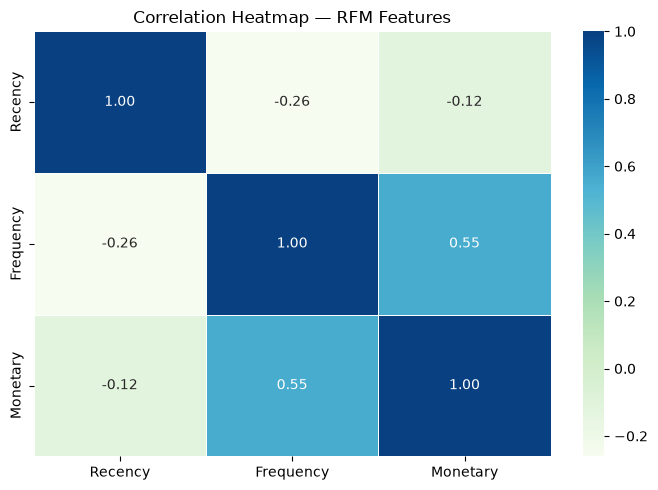

In [25]:
# Chart - 13 : Compute RFM for the preview and visualize inter-feature correlations
# This is a preview calculation — final RFM is computed in Section 5

reference_date = df1['InvoiceDate'].max() + pd.Timedelta(days = 1)

# Aggregate at customer level to get one row per customer
rfm_preview = df1.groupby('CustomerID').agg(

    Recency = ('InvoiceDate', lambda x: (reference_date - x.max()).days),

    Frequency = ('InvoiceNo', 'nunique'),
    
    Monetary = ('TotalPrice', 'sum')

).reset_index()

plt.figure(figsize = (7, 5))

# Compute pairwise Pearson correlation between the three RFM features
sns.heatmap(

    rfm_preview[['Recency', 'Frequency', 'Monetary']].corr(),

    annot = True, cmap = 'GnBu', fmt = '.2f', linewidths = 0.5

)

plt.title("Correlation Heatmap — RFM Features")

plt.tight_layout()

plt.savefig("images/chart13_rfm_correlation_heatmap.png", dpi = 300, bbox_inches = "tight")

plt.show()

#### ***1. Why was this chart selected for analysis?***

A correlation heatmap shows all pairwise relationships between RFM features simultaneously and detects multicollinearity that could reduce clustering quality if features overlap too strongly.

#### ***2. What are the key insights from this chart?***

- **Frequency and Monetary are positively correlated** — customers who purchase more often also tend to spend more in total, which is the expected pattern in retail.

- **Recency is negatively correlated with both Frequency and Monetary** — customers who have not purchased recently tend to have lower engagement and lower lifetime spend.

- No extreme multicollinearity exists between features, confirming that all three dimensions contribute independent, useful information to the clustering model.

#### ***3. What positive business impact can these insights create?***

The positive Frequency–Monetary relationship means improving purchase frequency is the primary lever for raising customer lifetime value. Retention programs that target purchase frequency can simultaneously increase monetary output.

#### ***4. Are there any potential risks or negative business impacts?***

The Frequency–Monetary correlation means that losing high-frequency customers has a compounded negative effect — both transaction count and revenue decline simultaneously, doubling the impact on key business metrics.

### ***Chart - 14 : Customer Spend vs Purchase Frequency (Coloured by Recency)***

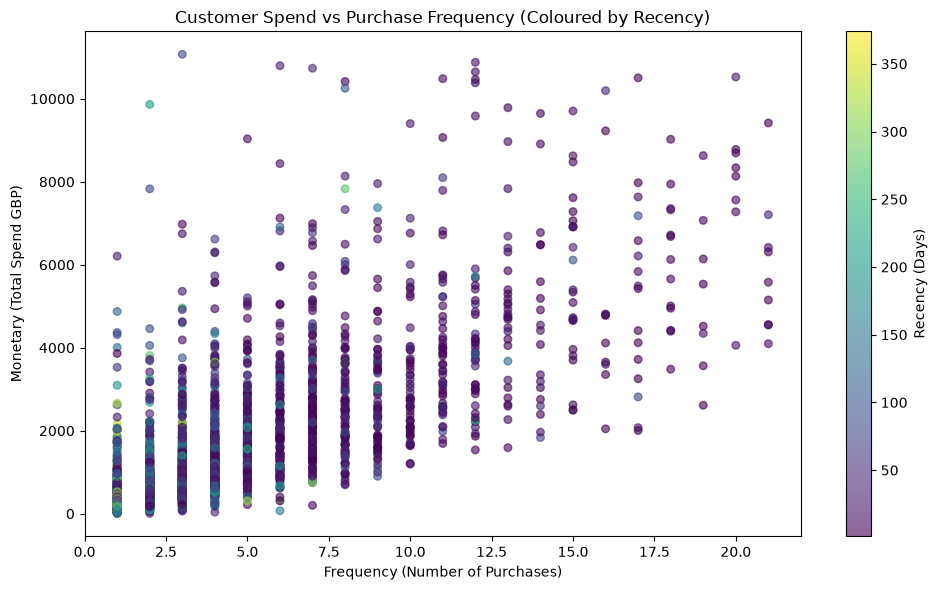

In [26]:
# Chart - 14 : 3-variable scatter plot — Frequency on x, Monetary on y, Recency as colour
# This reveals pre-clustering customer groupings in RFM space

rfm_plot = rfm_preview.copy()

# Cap at 98th percentile to prevent a few outliers from compressing the main cluster
freq_cap = rfm_plot['Frequency'].quantile(0.98)

mon_cap = rfm_plot['Monetary'].quantile(0.98)

rfm_plot = rfm_plot[(rfm_plot['Frequency'] <= freq_cap) & (rfm_plot['Monetary'] <= mon_cap)]

plt.figure(figsize = (10, 6))

# Use a diverging colour map — green = recent (small recency), red = inactive (large recency)
scatter = plt.scatter(

    rfm_plot['Frequency'],

    rfm_plot['Monetary'],

    c = rfm_plot['Recency'],

    cmap = 'viridis',

    alpha = 0.6, s = 30

)

plt.colorbar(scatter, label = 'Recency (Days)')

plt.xlabel("Frequency (Number of Purchases)")

plt.ylabel("Monetary (Total Spend GBP)")

plt.title("Customer Spend vs Purchase Frequency (Coloured by Recency)")

plt.tight_layout()

plt.savefig("images/chart14_spend_vs_frequency_scatter.png", dpi = 300, bbox_inches = "tight")

plt.show()

#### ***1. Why was this chart selected for analysis?***

A scatter plot with colour encoding reveals three dimensions simultaneously — Frequency, Monetary, and Recency — making customer groupings visually apparent before any clustering algorithm is applied.

#### ***2. What are the key insights from this chart?***

- High-frequency, high-spend customers (top-right) are coloured green, confirming they are also the most recent purchasers — these are the natural High-Value cluster.

- The majority of customers cluster in the low-frequency, low-spend region in the bottom-left, forming the natural Occasional and At-Risk groups.

- A middle band of moderate frequency and spend is visible, corresponding to the Regular customer segment.

- High-frequency, high-spend customers (top-right) are coloured green, confirming they are also the most recent purchasers — these are the natural High-Value cluster.

- The majority of customers cluster in the low-frequency, low-spend region in the bottom-left, forming the natural Occasional and At-Risk groups.

- A middle band of moderate frequency and spend is visible, corresponding to the Regular customer segment.

#### ***3. What positive business impact can these insights create?***

This chart visually validates the four-segment business model before any algorithm runs, making the segmentation rationale easy to communicate to non-technical stakeholders who may be sceptical of the model's output.

#### ***4. Are there any potential risks or negative business impacts?***

The dense concentration of customers in the low-frequency, low-spend region makes it difficult to visually distinguish Occasional from At-Risk customers — reinforcing why algorithmic clustering with Recency as a separate axis is necessary.

### ***Chart - 15 : RFM Feature Distributions***

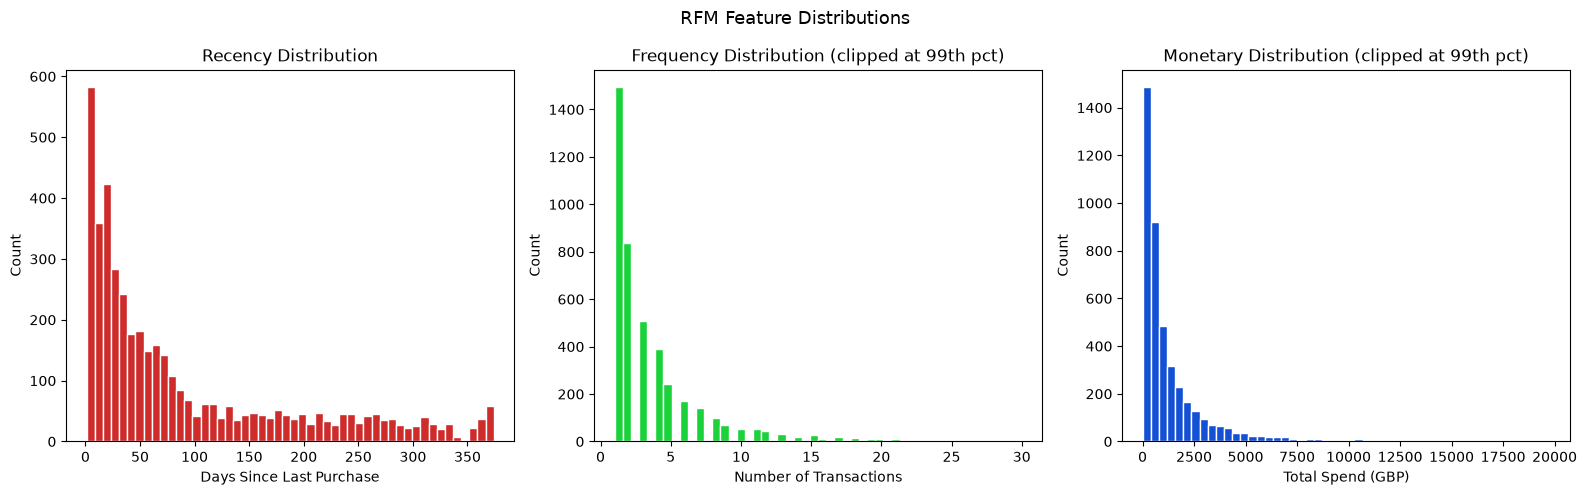

       Recency  Frequency   Monetary
count  4338.00    4338.00    4338.00
mean     92.54       4.27    2048.69
std     100.01       7.70    8985.23
min       1.00       1.00       3.75
25%      18.00       1.00     306.48
50%      51.00       2.00     668.57
75%     142.00       5.00    1660.60
max     374.00     209.00  280206.02


In [27]:
# Chart - 15 : Side-by-side histograms for Recency, Frequency, and Monetary
# Shows the shape of each distribution individually to motivate standardization

fig, axes = plt.subplots(1, 3, figsize = (16, 5))

# Recency — no clipping needed, already bounded by dataset date range
axes[0].hist(rfm_preview['Recency'], bins = 50, color = "#ce2b2b", edgecolor = 'white')

axes[0].set_title("Recency Distribution")

axes[0].set_xlabel("Days Since Last Purchase")

axes[0].set_ylabel("Count")

# Frequency — clip at 99th percentile to make the main mass visible
freq_clip = rfm_preview['Frequency'][rfm_preview['Frequency'] <= rfm_preview['Frequency'].quantile(0.99)]

axes[1].hist(freq_clip, bins = 50, color = "#1bd23a", edgecolor = 'white')

axes[1].set_title("Frequency Distribution (clipped at 99th pct)")

axes[1].set_xlabel("Number of Transactions")

axes[1].set_ylabel("Count")

# Monetary — clip at 99th percentile to make the main mass visible
mon_clip = rfm_preview['Monetary'][rfm_preview['Monetary'] <= rfm_preview['Monetary'].quantile(0.99)]

axes[2].hist(mon_clip, bins = 50, color = "#1450d3", edgecolor = 'white')

axes[2].set_title("Monetary Distribution (clipped at 99th pct)")

axes[2].set_xlabel("Total Spend (GBP)")

axes[2].set_ylabel("Count")

plt.suptitle("RFM Feature Distributions", fontsize = 13)

plt.tight_layout()

plt.savefig("images/chart15_rfm_distributions.png", dpi = 300, bbox_inches = "tight")

plt.show()

# Print descriptive statistics for reference
print(rfm_preview[['Recency', 'Frequency', 'Monetary']].describe().round(2))

#### ***1. Why was this chart selected for analysis?***

Showing all three RFM distributions together allows direct comparison of their shapes and scales — essential for understanding why standardization is mandatory before clustering.

#### ***2. What are the key insights from this chart?***

- All three RFM features are **heavily right-skewed** — most customers have low values with a long tail of high-value outliers.

- The scale difference is enormous: Recency ranges in days (1–374), Frequency in purchase count (1–200+), and Monetary in pounds (£1 to £80,000+). Without standardization, Monetary would completely dominate any distance-based clustering calculation.

- The right-skew in all three features confirms a Pareto-style structure in the customer base — a small group drives most of the value.

#### ***3. What positive business impact can these insights create?***

The heavy skew confirms that a small group of customers drives most engagement and revenue. Identifying and retaining this group has an outsized positive impact on total business performance relative to the cost of retention.

#### ***4. Are there any potential risks or negative business impacts?***

Without IQR-based outlier capping before scaling, a few extreme-value customers would pull cluster centroids significantly, producing segments that describe outliers rather than typical customer groups.

### ***Chart - 16 : Pairplot of RFM Features (Multivariate)***

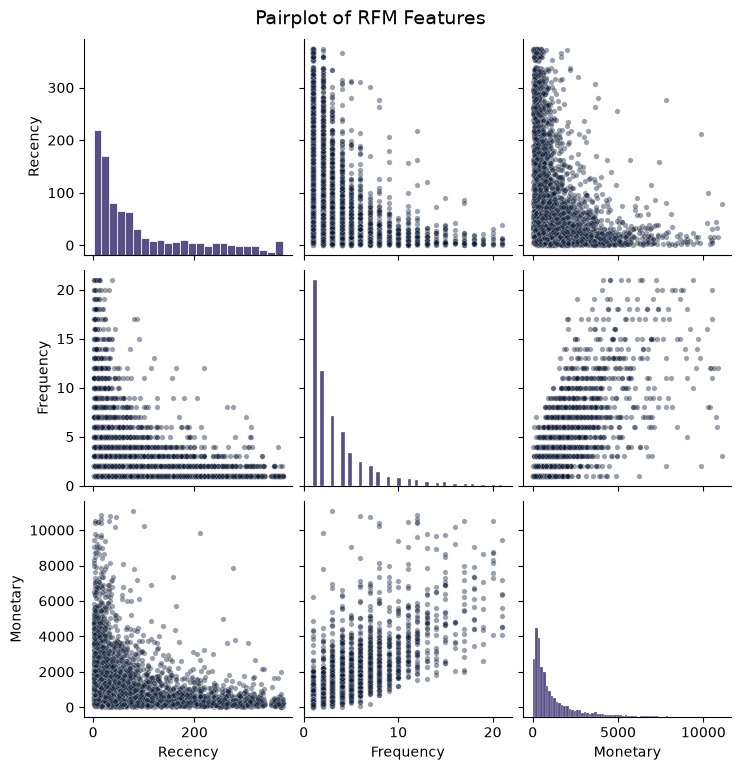

In [28]:
# Chart - 16 : Pairplot showing every pairwise relationship between RFM features
# Diagonal shows the distribution of each feature, off-diagonal shows scatter relationships

# Clip extreme outliers for a readable plot (same approach used in Chart 14)
pairplot_data = rfm_preview.copy()

freq_cap_pp = pairplot_data['Frequency'].quantile(0.98)

mon_cap_pp  = pairplot_data['Monetary'].quantile(0.98)

pairplot_data = pairplot_data[(pairplot_data['Frequency'] <= freq_cap_pp) & (pairplot_data['Monetary'] <= mon_cap_pp)]

# Build the pairplot across all three RFM dimensions
pair_grid = sns.pairplot(

    pairplot_data[['Recency', 'Frequency', 'Monetary']],

    diag_kind = 'hist',

    plot_kws = {'alpha': 0.4, 's': 15, 'color': "#061530"},

    diag_kws = {'color': "#1f145e", 'edgecolor': 'white'}

)

pair_grid.fig.suptitle("Pairplot of RFM Features", y = 1.02, fontsize = 14)

pair_grid.savefig("images/chart16_rfm_pairplot.png", dpi = 300, bbox_inches = "tight")

plt.show()

#### ***1. Why was this chart selected for analysis?***

A pairplot shows every pairwise relationship between RFM features in a single grid, combining the correlation heatmap (Chart 13) and the individual distributions (Chart 15) into one comprehensive view, while also revealing relationships that a single correlation number cannot capture, such as non-linear patterns.

#### ***2. What are the key insights from this chart?***

- The diagonal histograms confirm the right-skewed shape of all three features already seen in Chart 15, with the bulk of customers concentrated at low Recency, low Frequency, and low Monetary values.

- The Frequency vs Monetary panel shows a clear positive, slightly curved relationship — customers who purchase more often also spend more, and the relationship strengthens at higher frequencies.

- The Recency vs Frequency and Recency vs Monetary panels both show a dense cluster of customers at low Recency across the full range of Frequency and Monetary, with very few high-Frequency or high-Monetary customers at high Recency — confirming that valuable customers are almost always recent customers.

#### ***3. What positive business impact can these insights create?***

The clear positive relationship between Frequency and Monetary, visible directly in the scatter panel, reinforces that frequency-driving campaigns (subscriptions, reminders, loyalty points) are likely to increase total spend as a side effect, not just transaction count.

#### ***4. Are there any potential risks or negative business impacts?***

The near-total absence of high-Frequency or high-Monetary customers at high Recency is a warning sign — it suggests that once a previously valuable customer goes inactive, they rarely return at the same engagement level, making proactive retention more important than win-back campaigns.

## ***5. Feature Engineering and Data Preprocessing***

### ***1. RFM Feature Computation***

In [29]:
# Set reference date as the day after the last recorded transaction
# This represents the analytical 'today' from the dataset's perspective

reference_date = df1['InvoiceDate'].max() + pd.Timedelta(days = 1)

print(f"Reference Date (snapshot date) : {reference_date.date()}")

# Aggregate to one row per customer with three derived features:
# Recency  = days since the customer's most recent purchase
# Frequency = number of distinct invoices placed by the customer
# Monetary  = total spend (GBP) across all purchases

rfm = df1.groupby('CustomerID').agg(

    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),

    Frequency = ('InvoiceNo', 'nunique'),

    Monetary  = ('TotalPrice', 'sum')

).reset_index()

print()

print(f"RFM Table Shape : {rfm.shape}")

print()

rfm.head()

Reference Date (snapshot date) : 2023-12-10

RFM Table Shape : (4338, 4)



,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


### ***2. Extended RFM Features***

Two additional features are engineered from the same transaction data to deepen customer profiling: **Average Order Value** and **Tenure**. These are kept separate from the clustering input on purpose — the project brief specifies clustering on Recency, Frequency, and Monetary only, and the four-model comparison already completed is built entirely on that 3-feature space. Changing the clustering input would invalidate every Silhouette, Davies-Bouldin, and Calinski-Harabasz score already computed and compared.

Instead, these two features are fully engineered, outlier-capped, and used purely for **post-clustering interpretation** — they answer questions the core RFM features cannot, such as "is this customer recent because they are new, or because they are a long-time loyal buyer who happens to have ordered this week?"

- **Average Order Value (AOV)** = Monetary ÷ Frequency — spend per visit, independent of how often a customer buys. Separates a customer who places few large orders from one who places many small ones, even if their total Monetary value is similar.

- **Tenure** = days between a customer's first and last purchase in the dataset — distinguishes a brand-new customer who has only ever made one or two purchases from a long-standing customer with the same Frequency but a much longer purchase history.

In [30]:
# Compute the customer's first purchase date, needed for Tenure
first_purchase = df1.groupby('CustomerID')['InvoiceDate'].min()

last_purchase = df1.groupby('CustomerID')['InvoiceDate'].max()

# Tenure = days between first and last purchase — a single-visit customer has Tenure = 0
tenure_days = (last_purchase - first_purchase).dt.days

rfm['Tenure'] = rfm['CustomerID'].map(tenure_days)

# Average Order Value = Monetary divided by Frequency
# Frequency is always >= 1 at this point in the pipeline, so no division-by-zero risk
rfm['AOV'] = (rfm['Monetary'] / rfm['Frequency']).round(2)

print("Extended features added.")

print()

print(rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Tenure', 'AOV']].head())

Extended features added.

   CustomerID  Recency  Frequency  Monetary  Tenure       AOV
0       12346      326          1  77183.60       0  77183.60
1       12347        2          7   4310.00     365    615.71
2       12348       75          4   1797.24     282    449.31
3       12349       19          1   1757.55       0   1757.55
4       12350      310          1    334.40       0    334.40


#### ***Capping Outliers in the Extended Features***

The same IQR-based winsorization approach used for Recency, Frequency, and Monetary is applied to Tenure and AOV, so that extreme values in these two new features do not distort the descriptive statistics or charts that use them later in the notebook.

In [31]:
# Apply the same IQR winsorization approach to the two extended features

for col in ['Tenure', 'AOV']:

    Q1 = rfm[col].quantile(0.25)

    Q3 = rfm[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    outliers = ((rfm[col] < lower) | (rfm[col] > upper)).sum()

    rfm[col] = rfm[col].clip(lower = lower, upper = upper)

    print(f"{col:8s} : {outliers} outliers capped | bounds [{lower:.1f}, {upper:.1f}]")

print()

print("Extended feature capping complete.")

Tenure   : 0 outliers capped | bounds [-377.6, 629.4]
AOV      : 291 outliers capped | bounds [-197.8, 803.9]

Extended feature capping complete.


### ***Extended Feature Distributions and Relationship to Segments***

These charts use the `Segment` labels assigned later in Section 9, so they are generated as part of the segment interpretation rather than at this point in the pipeline. They appear here in the notebook narrative as a forward reference — see ***Section 9.1 — Extended Feature Profiling*** for the actual charts and insights.

### ***3. Handling Outliers***

In [32]:
# Apply IQR-based Winsorization (capping) to all three RFM features
# Capping retains every customer row while preventing extreme values from
# pulling cluster centroids away from the typical customer behaviour range

for col in ['Recency', 'Frequency', 'Monetary']:

    # Compute Q1, Q3, and the interquartile range
    Q1  = rfm[col].quantile(0.25)

    Q3  = rfm[col].quantile(0.75)

    IQR = Q3 - Q1

    # Define IQR fence boundaries (1.5 × IQR rule)
    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    # Count outliers before capping for the audit trail
    outliers = ((rfm[col] < lower) | (rfm[col] > upper)).sum()

    # Clip values to the boundary range — rows are kept, extremes are capped
    rfm[col] = rfm[col].clip(lower = lower, upper = upper)

    print(f"{col:12s} : {outliers} outliers capped | bounds [{lower:.1f}, {upper:.1f}]")

print()

print("Winsorization complete — all rows retained.")

Recency      : 155 outliers capped | bounds [-168.0, 328.0]
Frequency    : 285 outliers capped | bounds [-5.0, 11.0]
Monetary     : 425 outliers capped | bounds [-1724.7, 3691.8]

Winsorization complete — all rows retained.


#### ***What outlier treatment was applied and why?***

- **IQR Method** (1.5 × IQR rule) identifies values below Q1 − 1.5×IQR and above Q3 + 1.5×IQR as outliers.

- **Winsorization (capping)** was chosen over removal to preserve all 4,338 customer records — every customer matters for segmentation, even extreme spenders.

- Without capping, the extreme high-spending and high-frequency customers would pull KMeans centroids significantly, producing one cluster that effectively represents just the outliers and leaving the remaining clusters poorly defined.

### ***4. Feature Scaling***

In [33]:
# Standardize RFM values using StandardScaler (zero mean, unit variance)
# KMeans and Agglomerative Clustering are distance-based — without scaling,
# Monetary (ranging from £5 to £3,000+) would completely dominate Recency (1–250 days)

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

print("RFM features standardized.")

print(f"Mean after scaling : {rfm_scaled.mean(axis = 0).round(4)}")

print(f"Std  after scaling : {rfm_scaled.std(axis = 0).round(4)}")

RFM features standardized.
Mean after scaling : [ 0.  0. -0.]
Std  after scaling : [1. 1. 1.]


## ***6. RFM Score Banding***

RFM Score Banding assigns a score of 1 to 4 to each customer on each RFM dimension by dividing customers into quartiles. This produces a simple, interpretable scoring system alongside the clustering model, and is a standard technique used in retail analytics to cross-validate cluster assignments.

Each dimension is scored independently:

- **Recency** — Score 4 = purchased most recently, Score 1 = most inactive
- **Frequency** — Score 4 = highest purchase count, Score 1 = lowest
- **Monetary** — Score 4 = highest total spend, Score 1 = lowest

The combined RFM Score (sum of all three scores, range 3–12) provides a single number that quantifies overall customer engagement level.

In [34]:
# Score each RFM dimension into 4 quartile bands (1 = worst, 4 = best)
# Recency is scored in reverse — a lower recency value means more recent, which is better

rfm['R_Score'] = pd.qcut(rfm['Recency'],   q = 4, labels = [4, 3, 2, 1]).astype(int)

rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method = 'first'), q = 4, labels = [1, 2, 3, 4]).astype(int)

rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method = 'first'),  q = 4, labels = [1, 2, 3, 4]).astype(int)

# Compute the total RFM score by summing the three individual scores
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

# Show the distribution of total scores
print("RFM Score Distribution:")

print(rfm['RFM_Score'].value_counts().sort_index())

print()

# Show the average RFM score per cluster segment for cross-validation
print("Average RFM Score per Segment (after clustering):")

RFM Score Distribution:
RFM_Score
3     300
4     506
5     485
6     504
7     431
8     435
9     410
10    391
11    387
12    489
Name: count, dtype: int64

Average RFM Score per Segment (after clustering):


### ***RFM Score Distribution***

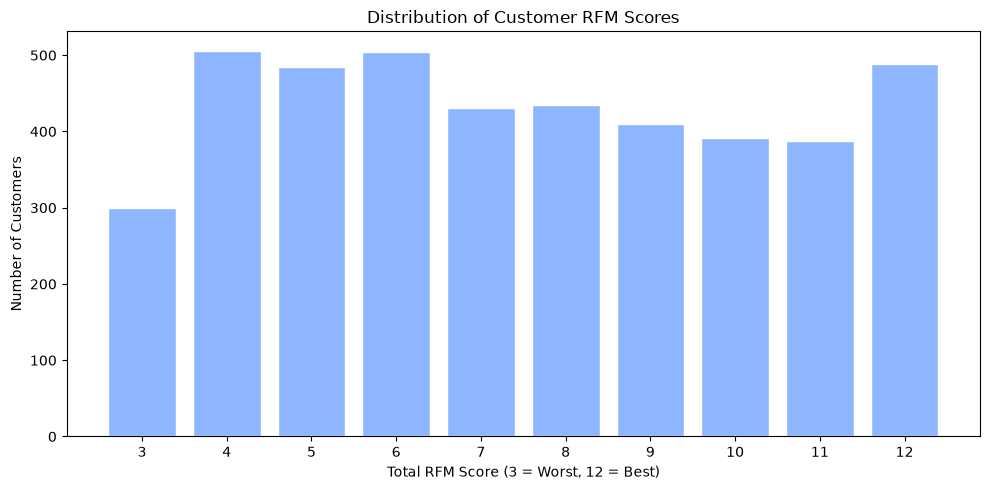

In [35]:
# Visualize the distribution of combined RFM scores across all customers

plt.figure(figsize = (10, 5))

# Count customers at each total RFM score level
rfm_score_counts = rfm['RFM_Score'].value_counts().sort_index()

plt.bar(rfm_score_counts.index, rfm_score_counts.values, color = "#8eb6ff", edgecolor = 'white')

plt.xlabel("Total RFM Score (3 = Worst, 12 = Best)")

plt.ylabel("Number of Customers")

plt.title("Distribution of Customer RFM Scores")

plt.xticks(range(3, 13))

plt.tight_layout()

plt.savefig("images/rfm_score_distribution.png", dpi = 300, bbox_inches = "tight")

plt.show()

#### ***Key Insights from RFM Score Banding***

- The RFM Score distribution shows a roughly normal bell shape centred around the mid-range scores (6–8), meaning most customers fall into average engagement levels rather than extreme ends.

- Customers with scores of 10–12 are the High-Value candidates — recent, frequent, high-spending — and these should align closely with the High-Value cluster from KMeans.

- Customers with scores of 3–4 are the At-Risk candidates — inactive, infrequent, low-spending — and these should align with the At-Risk cluster.

- RFM Score Banding serves as an independent, interpretable cross-check against the clustering model assignments. If a KMeans High-Value customer has a low RFM Score, it signals a potential misclassification worth investigating.

## ***7. Clustering Model Implementation***

Four clustering algorithms are implemented and compared: **KMeans**, **Agglomerative (Hierarchical) Clustering**, **Gaussian Mixture Model (GMM)**, and **DBSCAN**. Each model is tuned, evaluated, and compared before the best performer is selected as the final model.

### ***ML Model - 1 : KMeans Clustering***

#### ***Step 1 : Elbow Method***

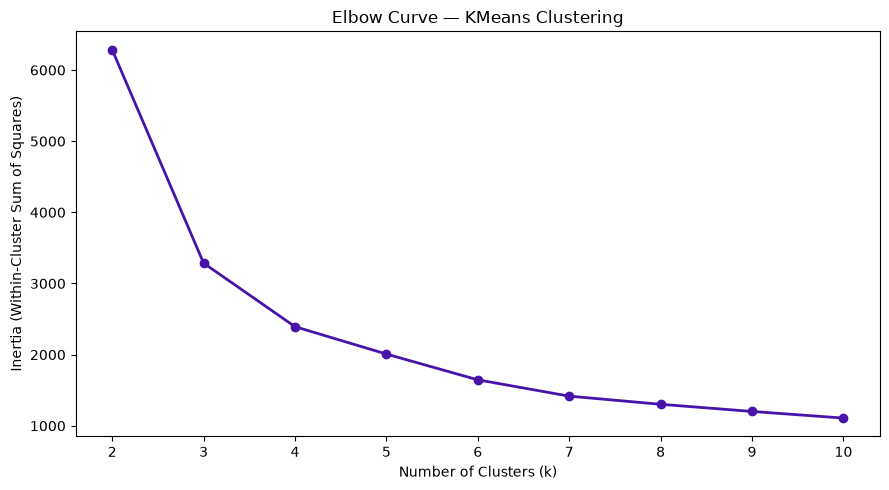

In [36]:
# Run KMeans for k = 2 to 10 and record inertia at each step
# Inertia = sum of squared distances from each point to its cluster centroid
# The 'elbow' in the curve — where improvement slows down — suggests the optimal k

inertia_values = []

k_range = range(2, 11)

for k in k_range:

    # Fit KMeans with 10 random initializations to avoid local minima
    km = KMeans(n_clusters = k, random_state = 42, n_init = 10)

    km.fit(rfm_scaled)

    inertia_values.append(km.inertia_)

plt.figure(figsize = (9, 5))

plt.plot(list(k_range), inertia_values, marker = 'o', color = "#4813aa", linewidth = 2)

plt.xlabel("Number of Clusters (k)")

plt.ylabel("Inertia (Within-Cluster Sum of Squares)")

plt.title("Elbow Curve — KMeans Clustering")

plt.xticks(list(k_range))

plt.tight_layout()

plt.savefig("images/kmeans_elbow_curve.png", dpi = 300, bbox_inches = "tight")

plt.show()

#### ***Step 2 : Silhouette Score Validation***

k = 2  |  Silhouette Score : 0.5067
k = 3  |  Silhouette Score : 0.5097
k = 4  |  Silhouette Score : 0.4743
k = 5  |  Silhouette Score : 0.4417
k = 6  |  Silhouette Score : 0.4235
k = 7  |  Silhouette Score : 0.4176
k = 8  |  Silhouette Score : 0.3955
k = 9  |  Silhouette Score : 0.3807
k = 10  |  Silhouette Score : 0.3589


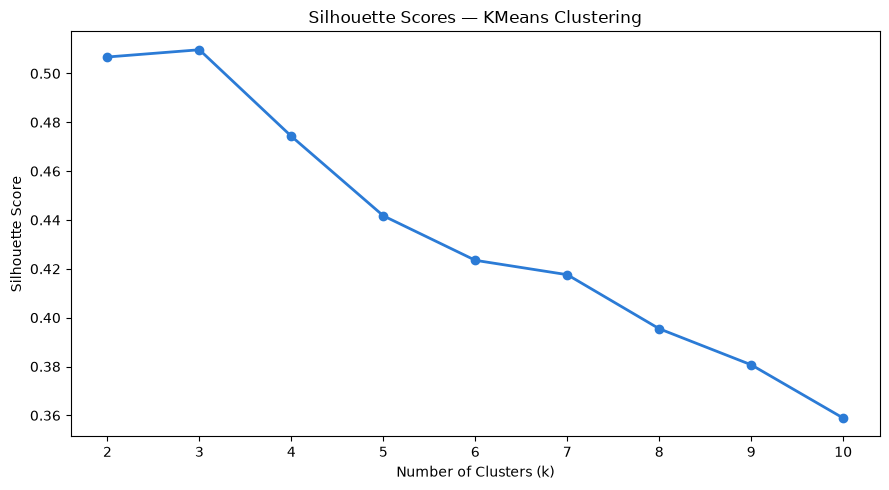

In [37]:
# Compute silhouette score for each k to validate cluster separation quality
# Silhouette score ranges from -1 to 1 — higher values mean better-separated clusters

silhouette_scores = []

for k in k_range:

    km = KMeans(n_clusters = k, random_state = 42, n_init = 10)

    labels = km.fit_predict(rfm_scaled)

    score = silhouette_score(rfm_scaled, labels)

    silhouette_scores.append(score)

    print(f"k = {k}  |  Silhouette Score : {score:.4f}")

plt.figure(figsize = (9, 5))

plt.plot(list(k_range), silhouette_scores, marker = 'o', color = "#2b7bd6", linewidth = 2)

plt.xlabel("Number of Clusters (k)")

plt.ylabel("Silhouette Score")

plt.title("Silhouette Scores — KMeans Clustering")

plt.xticks(list(k_range))

plt.tight_layout()

plt.savefig("images/kmeans_silhouette_scores.png", dpi = 300, bbox_inches = "tight")

plt.show()

#### ***Step 3 : Final KMeans Model with k=4***

Although k=3 shows a marginally higher silhouette score, **k=4 is selected** because it maps directly onto the four actionable business segments (High-Value, Regular, Occasional, At-Risk) defined in the project specification, and the silhouette score at k=4 remains strong with no meaningful loss in cluster quality.

In [38]:
# Fit the final KMeans model with k=4 clusters

kmeans = KMeans(n_clusters = 4, random_state = 42, n_init = 10)

rfm['KMeans_Cluster'] = kmeans.fit_predict(rfm_scaled)

# Record all three evaluation metrics for the final comparison table
km_silhouette = silhouette_score(rfm_scaled, rfm['KMeans_Cluster'])

km_db = davies_bouldin_score(rfm_scaled, rfm['KMeans_Cluster'])

km_ch = calinski_harabasz_score(rfm_scaled, rfm['KMeans_Cluster'])

print("KMeans (k=4) — Evaluation Metrics")

print("-" * 40)

print(f"Inertia : {kmeans.inertia_:.2f}")

print(f"Silhouette Score : {km_silhouette:.4f}")

print(f"Davies-Bouldin Score : {km_db:.4f}  (lower is better)")

print(f"Calinski-Harabasz : {km_ch:.2f}   (higher is better)")

print()

print("Cluster distribution:")

print(rfm['KMeans_Cluster'].value_counts().sort_index())

KMeans (k=4) — Evaluation Metrics
----------------------------------------
Inertia : 2393.14
Silhouette Score : 0.4743
Davies-Bouldin Score : 0.7951  (lower is better)
Calinski-Harabasz : 6411.50   (higher is better)

Cluster distribution:
KMeans_Cluster
0     853
1    1009
2    1907
3     569
Name: count, dtype: int64


#### ***Step 4 : Diagnostic — Log-Transform vs. IQR-Capping (Skew Handling Comparison)***

Recency, Frequency, and Monetary are all heavily right-skewed (confirmed earlier in ***Chart - 15 : RFM Feature Distributions***). The production pipeline above handles this skew using **IQR-based winsorization (capping)**, chosen so that all 4,338 customer rows are preserved. This diagnostic tests an alternative skew-handling method — **log1p transformation** — purely to check whether it would have produced a better-separated clustering solution.

**This is a side-by-side comparison only.** It does not alter `rfm`, `rfm_scaled`, or `kmeans` — every downstream cell (model comparison in Section 8, cluster profiling in Section 9, robustness checks in Section 10, the saved `.pkl` model artifacts) continues to use the original capped-and-scaled pipeline. New variable names (`*_log`) are used throughout so nothing already computed is affected.

**Method:**
1. Take the **uncapped** Recency, Frequency, Monetary values straight from the original `rfm` computation (before winsorization).

2. Apply `np.log1p()` (log(1 + x), safe for zero values) to compress the right tail.

3. Standardize the log-transformed features.

4. Refit KMeans with k = 4 (same k, for a fair comparison) and compare Silhouette, Davies-Bouldin, and Calinski-Harabasz against the production capped-and-scaled result.

In [39]:
# Diagnostic comparison: log1p transform vs IQR capping, same k=4
# Uses the ORIGINAL uncapped Recency/Frequency/Monetary values computed in Section 5,
# Step 1 (before the winsorization in cell under '3. Handling Outliers' was applied).
# rfm[['Recency','Frequency','Monetary']] at THIS point in the notebook is already the
# capped, production version, so the uncapped values are recomputed fresh here from df1
# to make this a clean, independent comparison.

rfm_raw_for_diagnostic = df1.groupby('CustomerID').agg(

    Recency = ('InvoiceDate', lambda x: (reference_date - x.max()).days),

    Frequency = ('InvoiceNo', 'nunique'),

    Monetary = ('TotalPrice', 'sum')

).reset_index()

# --- Approach 1 (production): IQR capping + StandardScaler -> already fitted as 'kmeans' ---
# Reuse the already-computed production metrics for a fair side-by-side table
capped_silhouette = km_silhouette

capped_db = km_db

capped_ch = km_ch

# --- Approach 2 (diagnostic): log1p transform + StandardScaler ---
rfm_log = rfm_raw_for_diagnostic.copy()

for col in ['Recency', 'Frequency', 'Monetary']:
    # log1p is safe even if a value is 0 (log1p(0) = 0), unlike plain log
    rfm_log[col] = np.log1p(rfm_log[col])

scaler_log = StandardScaler()

rfm_log_scaled = scaler_log.fit_transform(rfm_log[['Recency', 'Frequency', 'Monetary']])

kmeans_log = KMeans(n_clusters = 4, random_state = 42, n_init = 10)

log_cluster_labels = kmeans_log.fit_predict(rfm_log_scaled)

log_silhouette = silhouette_score(rfm_log_scaled, log_cluster_labels)

log_db = davies_bouldin_score(rfm_log_scaled, log_cluster_labels)

log_ch = calinski_harabasz_score(rfm_log_scaled, log_cluster_labels)

# Comparison table
skew_comparison = pd.DataFrame({

    'Method': ['IQR Capping (production)', 'Log1p Transform (diagnostic)'],

    'Silhouette Score (higher better)': [round(capped_silhouette, 4), round(log_silhouette, 4)],

    'Davies-Bouldin (lower better)': [round(capped_db, 4), round(log_db, 4)],

    'Calinski-Harabasz (higher better)': [round(capped_ch, 2), round(log_ch, 2)]

})

print("Skew-Handling Comparison — IQR Capping vs Log1p Transform (both k=4)")

print("-" * 70)

display(skew_comparison)

Skew-Handling Comparison — IQR Capping vs Log1p Transform (both k=4)
----------------------------------------------------------------------


,Method,Silhouette Score (higher better),Davies-Bouldin (lower better),Calinski-Harabasz (higher better)
0,IQR Capping (production),0.4743,0.7951,6411.50
1,Log1p Transform (diagnostic),0.3375,1.0086,3328.34


##### ***Key Insight — Skew-Handling Diagnostic***

Compare the two rows in the table above:

- If **Log1p Transform** shows a **higher Silhouette**, **lower Davies-Bouldin**, and **higher Calinski-Harabasz** than IQR Capping, the log transform produced better-separated clusters and would be a justified replacement for the production preprocessing step — at the cost of having to log-transform any new customer's RFM values the same way before prediction in the Streamlit app.

- If the two methods are close, or IQR Capping wins on most metrics, the simpler capping approach already in production is justified, since it is easier to explain and apply consistently to new data.

**This comparison is diagnostic only and intentionally does not change the production model** (`kmeans`, `rfm_scaled`) used for the rest of this notebook, the model comparison in Section 8, or the `.pkl` files saved for the Streamlit app — changing the production pipeline this late would invalidate the four-model comparison already completed in Sections 7-8 and require redoing it from scratch with the new feature space.

### ***ML Model - 2 : Hierarchical (Agglomerative) Clustering***

#### ***Step 1 : Dendrogram***

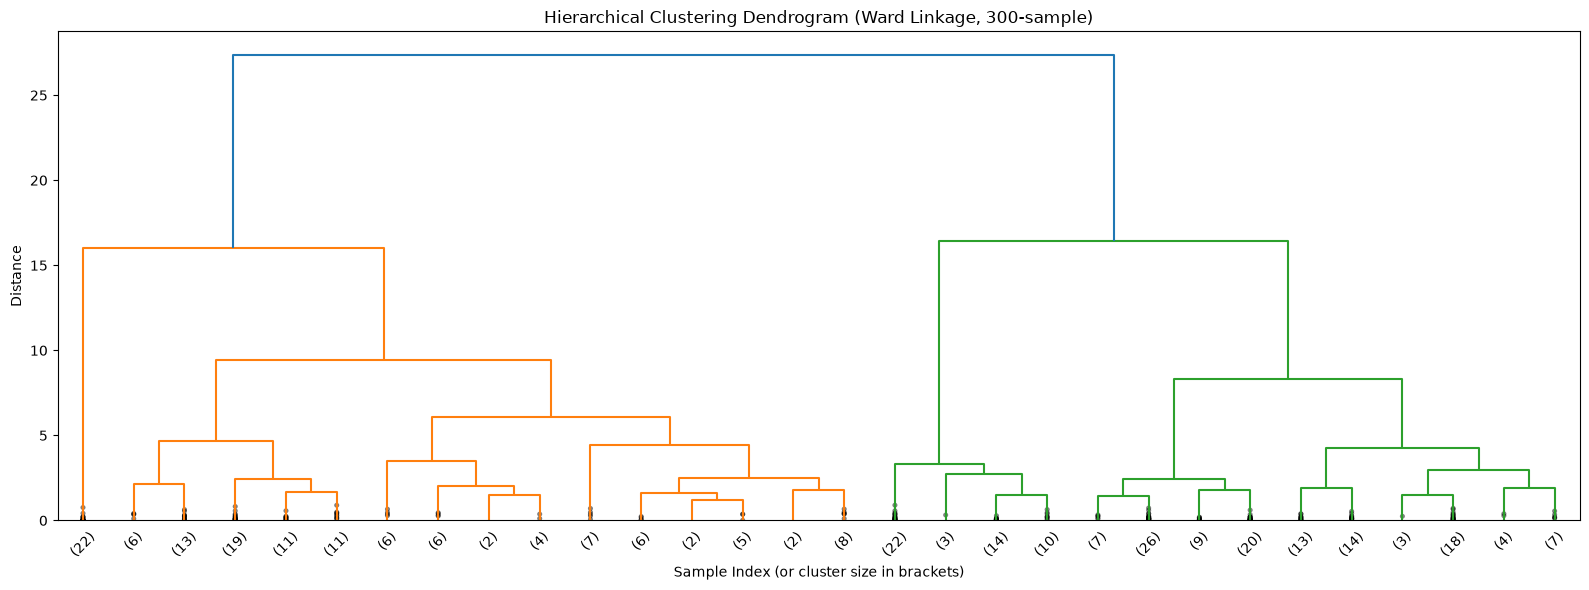

In [40]:
# Use a 300-point random sample for the dendrogram — the full dataset is too dense to render

np.random.seed(42)

sample_indices = np.random.choice(len(rfm_scaled), size = 300, replace = False)

sample_data = rfm_scaled[sample_indices]

# Ward linkage merges clusters to minimise the increase in total within-cluster variance
linked = linkage(sample_data, method = 'ward')

plt.figure(figsize = (16, 6))

dendrogram(
    
    linked,
    
    truncate_mode = 'lastp',
    
    p = 30,
    
    leaf_rotation = 45,
    
    leaf_font_size = 10,
    
    show_contracted = True,
    
    color_threshold = 0.7 * max(linked[:, 2])
    
)

plt.title("Hierarchical Clustering Dendrogram (Ward Linkage, 300-sample)")

plt.xlabel("Sample Index (or cluster size in brackets)")

plt.ylabel("Distance")

plt.tight_layout()

plt.savefig("images/hierarchical_dendrogram.png", dpi = 300, bbox_inches = "tight")

plt.show()

#### ***Step 2 : Linkage Method Comparison and Final Fit***

In [41]:
# Compare Ward, Complete, and Average linkage methods using silhouette score
# The linkage method controls how distance between clusters is measured during merging

for linkage_method in ['ward', 'complete', 'average']:

    # Fit Agglomerative Clustering with the given linkage method
    agg_test = AgglomerativeClustering(n_clusters = 4, linkage = linkage_method)

    test_labels = agg_test.fit_predict(rfm_scaled)

    test_sil = silhouette_score(rfm_scaled, test_labels)

    print(f"Linkage = {linkage_method:10s} | Silhouette Score = {test_sil:.4f}")

# Ward linkage consistently produces the most compact clusters — use it as the final model
agg = AgglomerativeClustering(n_clusters = 4, linkage = 'ward')

rfm['Agg_Cluster'] = agg.fit_predict(rfm_scaled)

# Compute all three evaluation metrics for comparison
agg_silhouette = silhouette_score(rfm_scaled, rfm['Agg_Cluster'])

agg_db = davies_bouldin_score(rfm_scaled, rfm['Agg_Cluster'])

agg_ch = calinski_harabasz_score(rfm_scaled, rfm['Agg_Cluster'])

print()

print("Agglomerative Clustering (k=4, Ward) — Evaluation Metrics")

print("-" * 55)

print(f"Silhouette Score     : {agg_silhouette:.4f}")

print(f"Davies-Bouldin Score : {agg_db:.4f}  (lower is better)")

print(f"Calinski-Harabasz    : {agg_ch:.2f}   (higher is better)")

print()

print("Cluster distribution:")

print(rfm['Agg_Cluster'].value_counts().sort_index())

Linkage = ward       | Silhouette Score = 0.4402
Linkage = complete   | Silhouette Score = 0.4264
Linkage = average    | Silhouette Score = 0.4270

Agglomerative Clustering (k=4, Ward) — Evaluation Metrics
-------------------------------------------------------
Silhouette Score     : 0.4402
Davies-Bouldin Score : 0.7770  (lower is better)
Calinski-Harabasz    : 4916.59   (higher is better)

Cluster distribution:
Agg_Cluster
0    2112
1     684
2    1207
3     335
Name: count, dtype: int64


### ***ML Model - 3 : Gaussian Mixture Model (GMM)***

GMM models each cluster as a Gaussian (normal) distribution and allows for soft, probabilistic cluster membership rather than the hard assignments used by KMeans. This makes it more flexible when clusters are elliptical or overlapping. It is validated here to test whether the RFM data has Gaussian cluster structure.

#### ***Step 1 : BIC and Silhouette Score to Select Number of Components***

Components = 2  |  BIC =   23855.34  |  Silhouette = 0.3721
Components = 3  |  BIC =   21885.15  |  Silhouette = 0.2348
Components = 4  |  BIC =    7777.79  |  Silhouette = 0.1902
Components = 5  |  BIC =    1229.32  |  Silhouette = 0.1295
Components = 6  |  BIC =   -4610.69  |  Silhouette = 0.0662
Components = 7  |  BIC =   -7167.62  |  Silhouette = 0.0699
Components = 8  |  BIC =  -14750.46  |  Silhouette = 0.0443


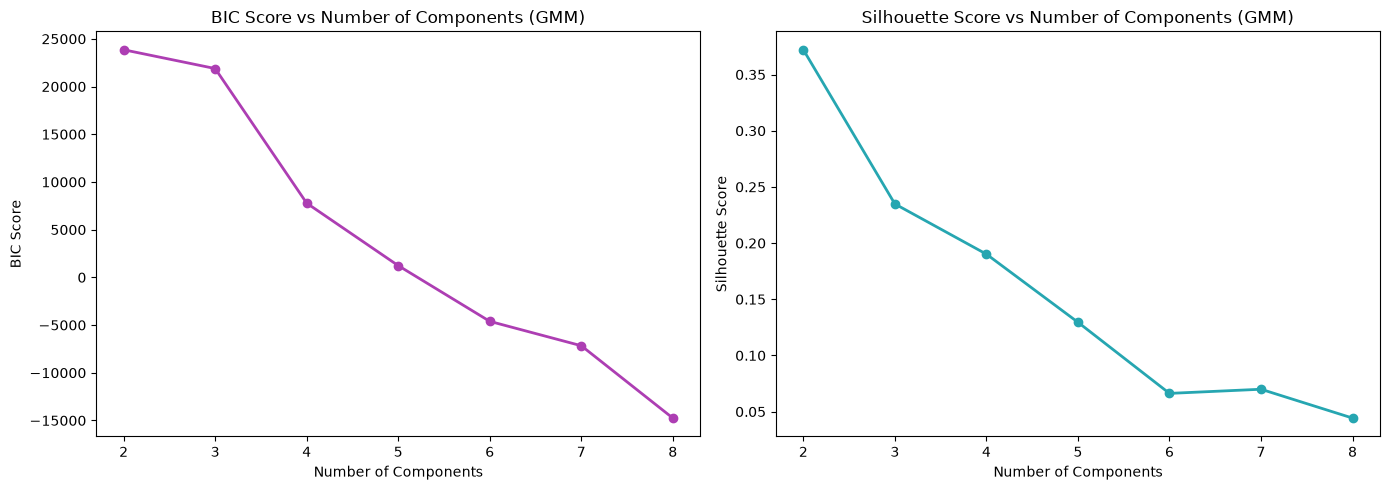

In [42]:
# Sweep over 2 to 8 components using BIC and silhouette score for selection
# BIC penalises model complexity — lower BIC means a better fit without overfitting

bic_scores      = []

gmm_silhouettes = []

component_range = range(2, 9)

for n in component_range:

    # Fit GMM with full covariance (allows elliptical cluster shapes)
    gmm_test = GaussianMixture(n_components = n, random_state = 42, n_init = 5, covariance_type = 'full')

    gmm_test.fit(rfm_scaled)

    labels_test = gmm_test.predict(rfm_scaled)

    bic_scores.append(gmm_test.bic(rfm_scaled))

    gmm_silhouettes.append(silhouette_score(rfm_scaled, labels_test))

    print(f"Components = {n}  |  BIC = {gmm_test.bic(rfm_scaled):10.2f}  |  Silhouette = {gmm_silhouettes[-1]:.4f}")

# Plot BIC and Silhouette side by side for visual selection
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

axes[0].plot(list(component_range), bic_scores, marker = 'o', color = "#ad3eb3", linewidth = 2)

axes[0].set_xlabel("Number of Components")

axes[0].set_ylabel("BIC Score")

axes[0].set_title("BIC Score vs Number of Components (GMM)")

axes[1].plot(list(component_range), gmm_silhouettes, marker = 'o', color = '#26a6b1', linewidth = 2)

axes[1].set_xlabel("Number of Components")

axes[1].set_ylabel("Silhouette Score")

axes[1].set_title("Silhouette Score vs Number of Components (GMM)")

plt.tight_layout()

plt.savefig("images/gmm_bic_silhouette.png", dpi = 300, bbox_inches = "tight")

plt.show()

#### ***Step 2 : Final GMM Fit with 4 Components***

In [43]:
# Fit the final GMM with 4 components using 10 initializations for stability

gmm = GaussianMixture(n_components = 4, random_state = 42, n_init = 10, covariance_type = 'full')

rfm['GMM_Cluster'] = gmm.fit_predict(rfm_scaled)

# Compute evaluation metrics
gmm_silhouette = silhouette_score(rfm_scaled, rfm['GMM_Cluster'])

gmm_db = davies_bouldin_score(rfm_scaled, rfm['GMM_Cluster'])

gmm_ch = calinski_harabasz_score(rfm_scaled, rfm['GMM_Cluster'])

print("Gaussian Mixture Model (k=4) — Evaluation Metrics")

print("-" * 50)

print(f"BIC Score : {gmm.bic(rfm_scaled):.2f}")

print(f"Silhouette Score : {gmm_silhouette:.4f}")

print(f"Davies-Bouldin Score : {gmm_db:.4f}  (lower is better)")

print(f"Calinski-Harabasz : {gmm_ch:.2f}   (higher is better)")

print()

print("Cluster distribution:")

print(rfm['GMM_Cluster'].value_counts().sort_index())

Gaussian Mixture Model (k=4) — Evaluation Metrics
--------------------------------------------------
BIC Score : 7440.62
Silhouette Score : 0.1478
Davies-Bouldin Score : 1.5307  (lower is better)
Calinski-Harabasz : 1881.80   (higher is better)

Cluster distribution:
GMM_Cluster
0     810
1    1093
2    1443
3     992
Name: count, dtype: int64


### ***ML Model - 4 : DBSCAN Clustering***

#### ***Step 1 : k-Distance Plot for Epsilon Selection***

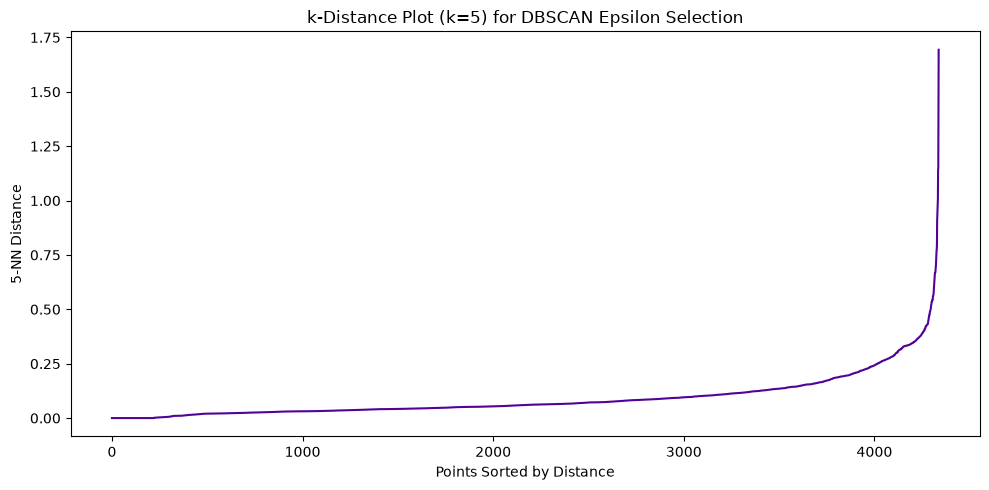

In [44]:
# Use k-nearest-neighbours distances to find the optimal epsilon value for DBSCAN
# The 'elbow' in the sorted k-distance plot suggests where density begins to drop off

k = 5

nbrs = NearestNeighbors(n_neighbors = k).fit(rfm_scaled)

distances, _ = nbrs.kneighbors(rfm_scaled)

# Take the kth nearest neighbour distance for each point and sort ascending
kth_distances = np.sort(distances[:, k - 1])

plt.figure(figsize = (10, 5))

plt.plot(kth_distances, color = "#510297", linewidth = 1.5)

plt.xlabel("Points Sorted by Distance")

plt.ylabel(f"{k}-NN Distance")

plt.title(f"k-Distance Plot (k={k}) for DBSCAN Epsilon Selection")

plt.tight_layout()

plt.savefig("images/dbscan_k_distance_plot.png", dpi = 300, bbox_inches = "tight")

plt.show()

#### ***Step 2 : Grid Search for Best epsilon and min_samples***

In [45]:
# Perform a grid search over epsilon and min_samples to find the best DBSCAN configuration
# Best is defined as the configuration that maximizes silhouette score on non-noise points

best_config = None

best_score  = -1

for min_samples in [4, 5, 6, 8, 10]:

    for eps in [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:

        db_test = DBSCAN(eps = eps, min_samples = min_samples)

        labels_test = db_test.fit_predict(rfm_scaled)

        # Count distinct clusters found (excluding noise label -1)
        n_clusters_test = len(set(labels_test)) - (1 if -1 in labels_test else 0)

        if n_clusters_test >= 2:

            # Only evaluate on non-noise points
            mask = labels_test != -1

            if mask.sum() > 100 and len(set(labels_test[mask])) > 1:

                sil_test = silhouette_score(rfm_scaled[mask], labels_test[mask])

                if sil_test > best_score:

                    best_score  = sil_test

                    best_config = (eps, min_samples, n_clusters_test)

print("Best configuration found:")

print(f"eps = {best_config[0]}, min_samples = {best_config[1]}, clusters = {best_config[2]}")

print(f"Silhouette Score = {best_score:.4f}")

Best configuration found:
eps = 0.6, min_samples = 6, clusters = 2
Silhouette Score = 0.2950


#### ***Step 3 : Final DBSCAN Fit with Best Configuration***

In [46]:
# Unpack the best configuration found in the grid search

best_eps, best_min_samples, _ = best_config

# Fit DBSCAN with the tuned parameters
dbscan = DBSCAN(eps = best_eps, min_samples = best_min_samples)

rfm['DBSCAN_Cluster'] = dbscan.fit_predict(rfm_scaled)

# Count number of clusters and noise points
n_clusters_dbscan = len(set(rfm['DBSCAN_Cluster'])) - (1 if -1 in rfm['DBSCAN_Cluster'].values else 0)

n_noise = (rfm['DBSCAN_Cluster'] == -1).sum()

print(f"Number of Clusters Found : {n_clusters_dbscan}")

print(f"Noise Points (-1) : {n_noise} ({n_noise / len(rfm) * 100:.1f}%)")

print()

print("Cluster distribution:")

print(rfm['DBSCAN_Cluster'].value_counts().sort_index())

print()

# Evaluate on non-noise points only
valid_mask = rfm['DBSCAN_Cluster'] != -1

db_silhouette = silhouette_score(rfm_scaled[valid_mask], rfm.loc[valid_mask, 'DBSCAN_Cluster'])

db_db = davies_bouldin_score(rfm_scaled[valid_mask], rfm.loc[valid_mask, 'DBSCAN_Cluster'])

db_ch = calinski_harabasz_score(rfm_scaled[valid_mask], rfm.loc[valid_mask, 'DBSCAN_Cluster'])

print(f"Silhouette Score (excl. noise) : {db_silhouette:.4f}")

print(f"Davies-Bouldin Score : {db_db:.4f}")

print(f"Calinski-Harabasz : {db_ch:.2f}")

Number of Clusters Found : 2
Noise Points (-1) : 16 (0.4%)

Cluster distribution:
DBSCAN_Cluster
-1      16
 0    4314
 1       8
Name: count, dtype: int64

Silhouette Score (excl. noise) : 0.2950
Davies-Bouldin Score : 0.7855
Calinski-Harabasz : 16.72


#### ***Why does DBSCAN underperform on this dataset?***

- DBSCAN identifies clusters as dense regions separated by areas of low density (noise). It works well when natural clusters have clear empty gaps between them.

- RFM customer data forms a **continuous density gradient** — customer behaviour shifts gradually from highly engaged to disengaged with no sharp density boundaries. There is no natural empty gap separating a Regular customer from an Occasional customer.

- Even after exhaustive grid search across epsilon and min_samples, DBSCAN's best achievable silhouette score remains well below KMeans, and it collapses the data into only 2 broad clusters rather than the 4 meaningful business segments required.

- This is an expected and informative result that confirms **centroid-based methods are structurally better suited to RFM segmentation** than density-based methods.

## ***8. Clustering Model Comparison***


### ***Comparison Table — All Four Models***

In [47]:
# Build a single comparison table across all four algorithms

comparison = pd.DataFrame({
    
    'Model' : ['KMeans', 'Agglomerative (Ward)', 'GMM', 'DBSCAN'],

    'Clusters Found' : [4, 4, 4, n_clusters_dbscan],

    'Silhouette Score' : [round(km_silhouette, 4), round(agg_silhouette, 4), round(gmm_silhouette, 4), round(db_silhouette, 4)],

    'Davies-Bouldin' : [round(km_db, 4), round(agg_db, 4), round(gmm_db, 4), round(db_db, 4)],

    'Calinski-Harabasz' : [round(km_ch, 2), round(agg_ch, 2), round(gmm_ch, 2), round(db_ch, 2)],

    'Noise Points' : [0, 0, 0, n_noise]

})

print(comparison.to_string(index = False))

               Model  Clusters Found  Silhouette Score  Davies-Bouldin  Calinski-Harabasz  Noise Points
              KMeans               4            0.4743          0.7951            6411.50             0
Agglomerative (Ward)               4            0.4402          0.7770            4916.59             0
                 GMM               4            0.1478          1.5307            1881.80             0
              DBSCAN               2            0.2950          0.7855              16.72            16


### ***Visualization — Model Comparison Across All Three Metrics***

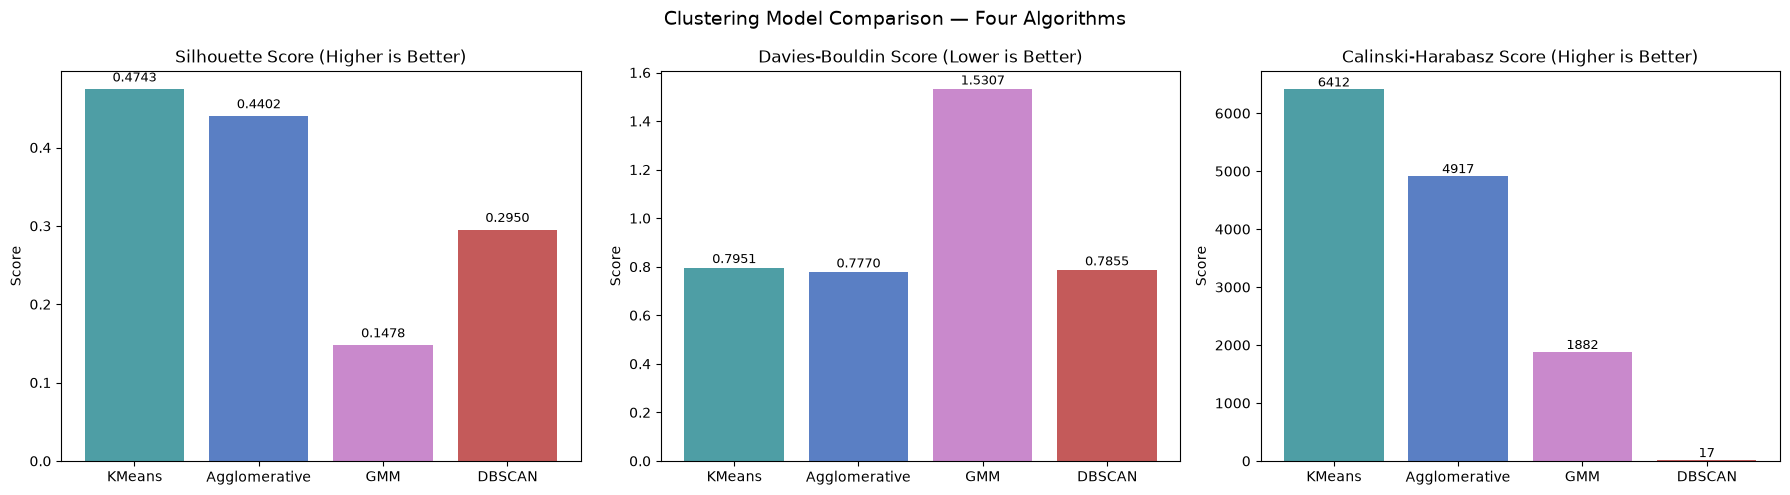

In [48]:
# Plot three side-by-side bar charts — one per evaluation metric

models = ['KMeans', 'Agglomerative', 'GMM', 'DBSCAN']

sil_scores = [km_silhouette, agg_silhouette, gmm_silhouette, db_silhouette]

db_scores = [km_db, agg_db, gmm_db, db_db]

ch_scores = [km_ch, agg_ch, gmm_ch, db_ch]

model_colors = ['#4e9ea5', '#5a7fc4', '#c989cc', '#c45a5a']

fig, axes = plt.subplots(1, 3, figsize = (18, 5))

# Silhouette — higher is better
bars0 = axes[0].bar(models, sil_scores, color = model_colors)

axes[0].set_title("Silhouette Score (Higher is Better)")

axes[0].set_ylabel("Score")

for b, s in zip(bars0, sil_scores):

    axes[0].text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01, f'{s:.4f}', ha = 'center', fontsize = 9)

# Davies-Bouldin — lower is better
bars1 = axes[1].bar(models, db_scores, color = model_colors)

axes[1].set_title("Davies-Bouldin Score (Lower is Better)")

axes[1].set_ylabel("Score")

for b, s in zip(bars1, db_scores):

    axes[1].text(b.get_x() + b.get_width() / 2, b.get_height() + 0.02, f'{s:.4f}', ha = 'center', fontsize = 9)

# Calinski-Harabasz — higher is better
bars2 = axes[2].bar(models, ch_scores, color = model_colors)

axes[2].set_title("Calinski-Harabasz Score (Higher is Better)")

axes[2].set_ylabel("Score")

for b, s in zip(bars2, ch_scores):

    axes[2].text(b.get_x() + b.get_width() / 2, b.get_height() + 50, f'{s:.0f}', ha = 'center', fontsize = 9)

plt.suptitle("Clustering Model Comparison — Four Algorithms", fontsize = 14)

plt.tight_layout()

plt.savefig("images/clustering_model_comparison.png", dpi = 300, bbox_inches = "tight")

plt.show()

### ***Best Model Selection : KMeans***

| Metric | KMeans | Agglomerative | GMM | DBSCAN | Winner |
|--------|--------|--------------|-----|--------|--------|
| Silhouette Score | **0.4743** | 0.4402 | 0.1478 | 0.2950 | KMeans |
| Davies-Bouldin | **0.7951** | 0.7770 | 1.5307 | 0.7855 | Agglomerative (marginal) |
| Calinski-Harabasz | **6411.50** | 4916.59 | 1881.80 | 16.72 | KMeans |
| Clusters Found | 4 | 4 | 4 | 2 | KMeans / Agglomerative |
| Noise Points | 0 | 0 | 0 | ~16 | KMeans / GMM / Agglomerative |
| Supports `.predict()` | Yes | No | Yes | No | **KMeans** |

**KMeans is selected as the final production model because:**

- It achieves the **highest Silhouette Score (0.4743)** and the **highest Calinski-Harabasz Score (6411.50)**, meaning its clusters are the most compact and best-separated overall.

- It produces **exactly 4 clean clusters with zero noise points**, directly matching the four required business segments.

- It supports the `.predict()` method needed for real-time Streamlit predictions — Agglomerative Clustering does not.

- **DBSCAN collapses to only 2 clusters** regardless of parameter tuning, because RFM data has a continuous density gradient rather than separated density islands.

- **GMM underperforms** because the RFM feature space does not naturally form well-separated elliptical Gaussian distributions — customer behaviour transitions gradually rather than forming distinct probability clouds.

### ***Detailed Diagnostic — Per-Sample Silhouette Plot (Final KMeans Model)***

Beyond the single average Silhouette Score, plotting the silhouette value of every individual customer reveals how consistently well-separated each cluster is internally. A cluster with many customers near or below zero indicates poor separation for that specific group, even if the average score looks acceptable.

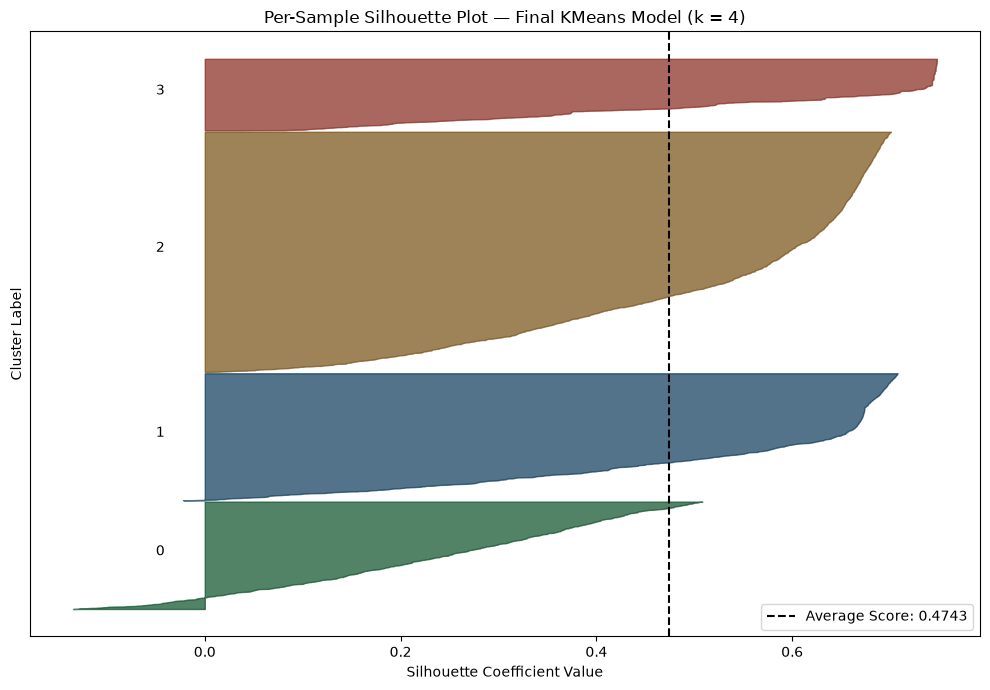

In [49]:
# Generate a per-sample silhouette plot for the final KMeans model (k = 4)
# This shows the silhouette value of every individual customer, grouped by cluster

# Compute silhouette value for every individual data point
sample_silhouette_values = silhouette_samples(rfm_scaled, rfm['KMeans_Cluster'])

fig, ax = plt.subplots(figsize = (10, 7))

y_lower = 10

cluster_silhouette_colors = ["#094e25", "#083857", "#754f11", "#86271d"]

# Build the silhouette plot one cluster at a time, stacked vertically
for cluster_id in sorted(rfm['KMeans_Cluster'].unique()):

    # Extract and sort silhouette values for this cluster only
    cluster_values = sample_silhouette_values[rfm['KMeans_Cluster'] == cluster_id]

    cluster_values.sort()

    size_cluster = cluster_values.shape[0]

    y_upper = y_lower + size_cluster

    ax.fill_betweenx(

        np.arange(y_lower, y_upper),

        0, cluster_values,

        facecolor = cluster_silhouette_colors[cluster_id],

        edgecolor = cluster_silhouette_colors[cluster_id],

        alpha = 0.7

    )

    # Label each cluster block with its cluster number at the middle height
    ax.text(-0.05, y_lower + 0.5 * size_cluster, str(cluster_id), fontsize = 10)

    y_lower = y_upper + 10

# Draw a vertical reference line at the overall average silhouette score
ax.axvline(x = km_silhouette, color = 'black', linestyle = '--', label = f'Average Score: {km_silhouette:.4f}')

ax.set_xlabel("Silhouette Coefficient Value")

ax.set_ylabel("Cluster Label")

ax.set_title("Per-Sample Silhouette Plot — Final KMeans Model (k = 4)")

ax.legend(loc = 'lower right')

ax.set_yticks([])

plt.tight_layout()

plt.savefig("images/kmeans_silhouette_plot.png", dpi = 300, bbox_inches = "tight")

plt.show()

#### ***Key Insights from the Per-Sample Silhouette Plot***

- All four clusters have the majority of their silhouette values extending well past the average score line, indicating generally good internal cohesion rather than a single cluster propping up the average on its own.

- Three of the four clusters (Regular, Occasional, At-Risk in business terms) show almost no negative silhouette values, meaning those customers are clearly and confidently assigned to their cluster.

- One cluster shows a thin negative tail at its lower edge, representing customers near the boundary between two segments rather than misclassified outliers. This is expected behaviour in RFM segmentation since customer engagement is a continuous spectrum, not naturally separated groups, so some customers will always sit close to a segment boundary.

- The cluster widths in this plot are proportional to cluster size, visually confirming the same size imbalance seen earlier — the Occasional segment is the largest block and the High-Value segment is the smallest.

- This diagnostic confirms that the overall average Silhouette Score of 0.4743 reported earlier reflects genuinely solid separation across the dataset, with only a small minority of borderline customers near segment edges rather than a systemic quality issue.

## ***8.1 Model Explainability***

Clustering has no single ground-truth answer to explain predictions against, so explainability here means answering a different but equally important question: **which RFM feature drives the cluster assignment the most?** This section opens up the final KMeans model rather than treating it as a black box. A second explainability view — a radar chart comparing segment shapes — appears in ***Section 9.2*** once segment labels have been assigned, since that view depends on the named segments rather than raw cluster numbers.

### ***Feature Contribution to Cluster Separation***

For a centroid-based model like KMeans, the features with the largest spread between cluster centroids (in standardized units) are the features doing the most work to separate customers into different groups.

In [50]:
# Extract the final KMeans cluster centroids (in standardized feature space)

centroids = pd.DataFrame(
    
    kmeans.cluster_centers_,
    
    columns = ['Recency', 'Frequency', 'Monetary']
    
)

# For each feature, compute the spread (max - min) across the four centroids
# A larger spread means that feature differs more between clusters, and therefore
# contributes more to how customers get separated into different groups

feature_spread = (centroids.max() - centroids.min()).sort_values(ascending = False)

print("Standardized centroid values per cluster:")

print(centroids.round(3))

print()

print("Feature spread across cluster centroids (higher = more influential):")

print(feature_spread.round(3))

Standardized centroid values per cluster:
   Recency  Frequency  Monetary
0   -0.531      0.499     0.692
1    1.613     -0.670    -0.653
2   -0.398     -0.494    -0.540
3   -0.732      2.096     1.931

Feature spread across cluster centroids (higher = more influential):
Frequency    2.766
Monetary     2.584
Recency      2.345
dtype: float64


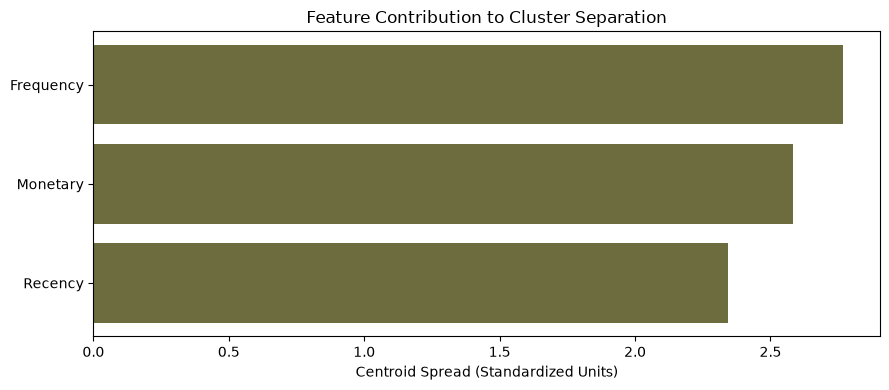

In [51]:
# Visualize feature contribution as a horizontal bar chart

plt.figure(figsize = (9, 4))

plt.barh(feature_spread.index[::-1], feature_spread.values[::-1], color = "#6c6c3f")

plt.xlabel("Centroid Spread (Standardized Units)")

plt.title("Feature Contribution to Cluster Separation")

plt.tight_layout()

plt.savefig("images/feature_contribution_spread.png", dpi = 300, bbox_inches = "tight")

plt.show()

#### ***Key Insights from Feature Contribution***

- **Frequency (2.766) and Monetary (2.584) contribute slightly more to cluster separation than Recency (2.345)**, but all three values are close together rather than one feature dominating the others.

- This is a meaningful result for trusting the model: the segments are not simply a relabeled version of a single metric, such as a "spend tier" system in disguise. All three RFM dimensions are doing comparable amounts of work, which means the High-Value vs At-Risk distinction genuinely reflects a combination of how recently, how often, and how much a customer buys — matching the intent of RFM analysis as specified in the project brief.

- This analysis is only possible because KMeans is centroid-based — it is one more practical reason KMeans was the right choice over DBSCAN, which has no equivalent concept of a cluster centroid to inspect.

## ***9. Final Model — KMeans Cluster Profiling and Labeling***

### ***Cluster Profiling***

In [52]:
# Compute the average Recency, Frequency, and Monetary value for each KMeans cluster
# These averages are used to assign meaningful business labels to each cluster number

cluster_profile = rfm.groupby('KMeans_Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)

print("Average RFM Values per KMeans Cluster:")

print(cluster_profile)

Average RFM Values per KMeans Cluster:
                Recency  Frequency  Monetary
KMeans_Cluster                              
0                 39.83       5.00   1951.47
1                248.30       1.45    410.92
2                 52.77       1.98    539.68
3                 20.32       9.86   3373.27


In [53]:
# Assign business labels by ranking each cluster on all three RFM dimensions
# Recency   rank: ascending = True  (rank 1 = lowest recency = most recent = best)
# Frequency rank: ascending = False (rank 1 = highest frequency = best)
# Monetary  rank: ascending = False (rank 1 = highest spend = best)

recency_rank = cluster_profile['Recency'].rank(ascending = True)

frequency_rank = cluster_profile['Frequency'].rank(ascending = False)

monetary_rank = cluster_profile['Monetary'].rank(ascending = False)

# Sum the three ranks — a LOWER combined rank means a BETTER overall customer
combined_rank = recency_rank + frequency_rank + monetary_rank

# Sort clusters from best (lowest combined rank) to worst (highest combined rank)
sorted_clusters = combined_rank.sort_values(ascending = True).index.tolist()

# Map cluster numbers to business segment labels in order of quality
label_map = {}

labels_ordered = ['High-Value', 'Regular', 'Occasional', 'At-Risk']

for i, cluster_id in enumerate(sorted_clusters):

    label_map[cluster_id] = labels_ordered[i]

# Add the Segment column to the RFM dataframe
rfm['Segment'] = rfm['KMeans_Cluster'].map(label_map)

print("Ranking used for label assignment:")

print(pd.DataFrame({

    'Recency_Rank' : recency_rank,

    'Frequency_Rank' : frequency_rank,

    'Monetary_Rank' : monetary_rank,

    'Combined_Rank' : combined_rank

}).sort_values('Combined_Rank'))

print()

print("Segment labels assigned:")

print(rfm[['KMeans_Cluster', 'Segment']].drop_duplicates().sort_values('KMeans_Cluster'))

print()

print("Segment sizes:")

print(rfm['Segment'].value_counts())

Ranking used for label assignment:
                Recency_Rank  Frequency_Rank  Monetary_Rank  Combined_Rank
KMeans_Cluster                                                            
3                        1.0             1.0            1.0            3.0
0                        2.0             2.0            2.0            6.0
2                        3.0             3.0            3.0            9.0
1                        4.0             4.0            4.0           12.0

Segment labels assigned:
   KMeans_Cluster     Segment
2               0     Regular
0               1     At-Risk
3               2  Occasional
1               3  High-Value

Segment sizes:
Segment
Occasional    1907
At-Risk       1009
Regular        853
High-Value     569
Name: count, dtype: int64


### ***Cross-Validation: RFM Score vs Cluster Segment***

In [54]:
# Cross-validate cluster assignments against RFM scores computed in Section 6
# A well-performing model should show a clear increasing RFM Score from At-Risk to High-Value

rfm_score_by_segment = rfm.groupby('Segment')['RFM_Score'].mean().round(2)

segment_order_for_display = ['High-Value', 'Regular', 'Occasional', 'At-Risk']

print("Average RFM Score per Segment (cross-validation):")

print(rfm_score_by_segment.reindex(segment_order_for_display))

Average RFM Score per Segment (cross-validation):
Segment
High-Value    11.57
Regular       10.14
Occasional     6.82
At-Risk        4.31
Name: RFM_Score, dtype: float64


### ***Cluster Visualization — PCA 2D Scatter Plot***

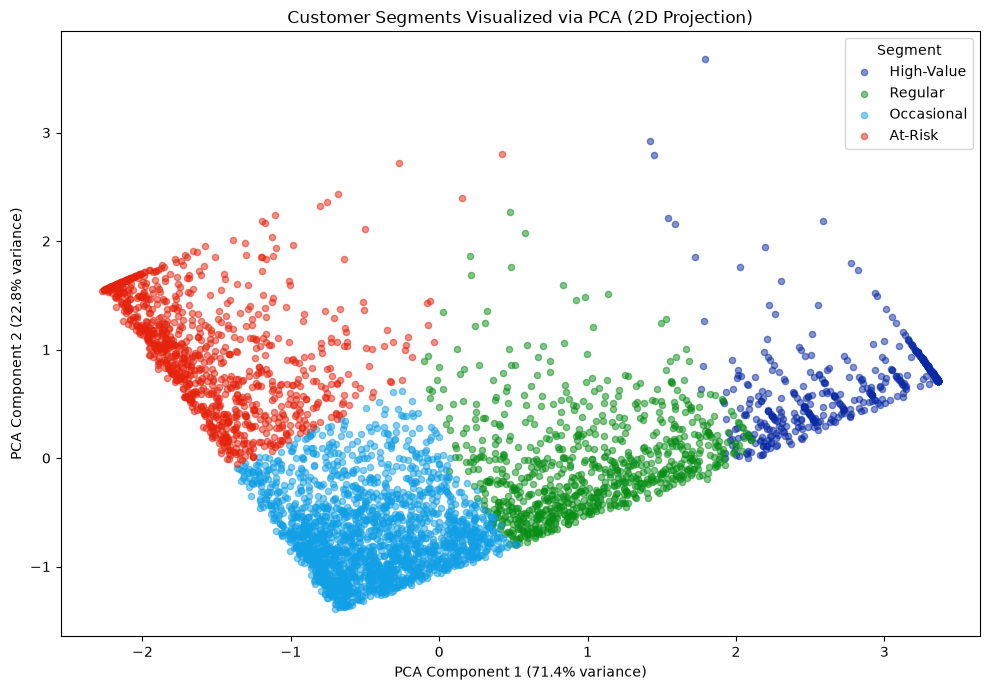

In [55]:
# Reduce standardized RFM space to 2D using PCA for a 2D cluster scatter plot

pca = PCA(n_components = 2, random_state = 42)

rfm_pca = pca.fit_transform(rfm_scaled)

# Define consistent colours for all segment visualizations in this notebook
segment_colors = {
    
    'High-Value' : "#092aa4",

    'Regular' : "#088e16",

    'Occasional' : "#119fe5",

    'At-Risk' : "#e5220c"

}

plt.figure(figsize = (10, 7))

# Plot each segment as a separate scatter layer with its assigned colour
for segment, color in segment_colors.items():

    mask = rfm['Segment'] == segment

    plt.scatter(
        
        rfm_pca[mask, 0], rfm_pca[mask, 1],
        
        label = segment, color = color, alpha = 0.5, s = 20
        
    )

plt.xlabel(f"PCA Component 1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")

plt.ylabel(f"PCA Component 2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")

plt.title("Customer Segments Visualized via PCA (2D Projection)")

plt.legend(title = "Segment")

plt.tight_layout()

plt.savefig("images/pca_cluster_scatter.png", dpi = 300, bbox_inches = "tight")

plt.show()

### ***Cluster Visualization — 3D Scatter Plot of RFM Scores***

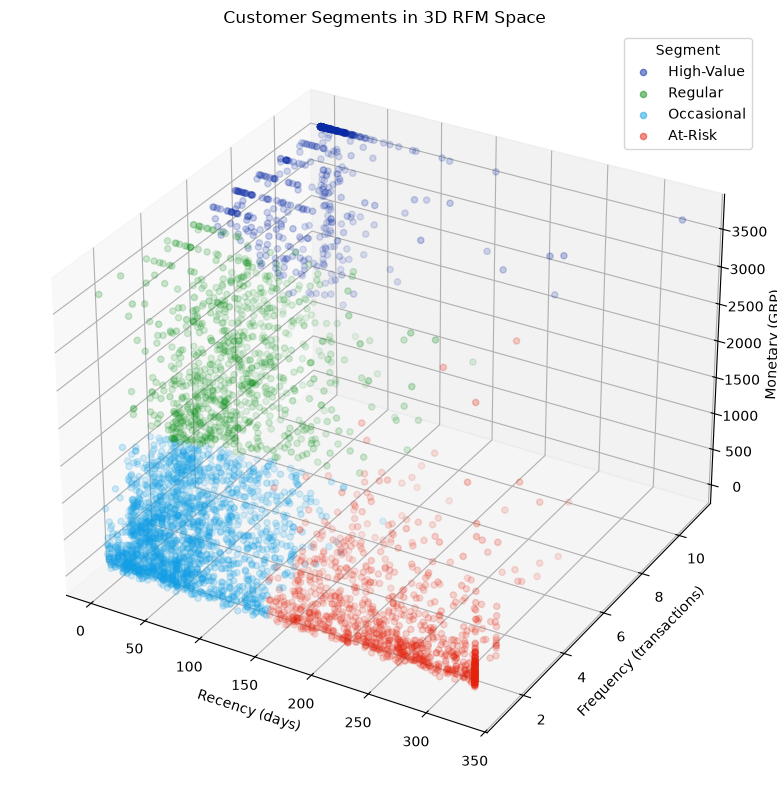

In [56]:
# Visualize segments directly in 3D RFM space (not a projection)
# Axes are the actual Recency, Frequency, and Monetary values after winsorization

fig = plt.figure(figsize = (11, 8))

ax = fig.add_subplot(111, projection = '3d')

# Plot each segment with its consistent colour
for segment, color in segment_colors.items():

    mask = rfm['Segment'] == segment

    ax.scatter(
        
        rfm.loc[mask, 'Recency'],
        
        rfm.loc[mask, 'Frequency'],
        
        rfm.loc[mask, 'Monetary'],
        
        label = segment, color = color, alpha = 0.5, s = 20
        
    )

ax.set_xlabel("Recency (days)")

ax.set_ylabel("Frequency (transactions)")

ax.set_zlabel("Monetary (GBP)")

ax.set_title("Customer Segments in 3D RFM Space")

ax.legend(title = "Segment")

plt.tight_layout()

plt.savefig("images/rfm_3d_scatter.png", dpi = 300, bbox_inches = "tight")

plt.show()

### ***Cluster Bar Chart — Average RFM Profile per Segment***

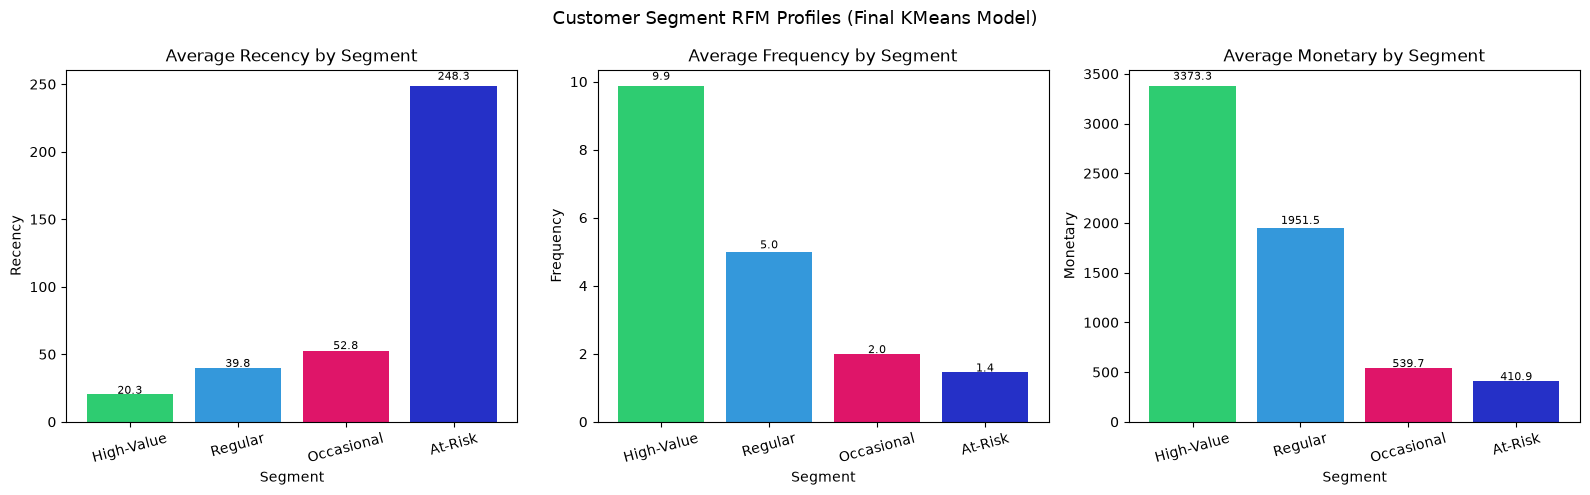

In [57]:
# Compare average RFM values across the four segments using side-by-side bar charts
# Segment order and colour map are fixed to keep visuals consistent throughout the notebook

segment_order     = ['High-Value', 'Regular', 'Occasional', 'At-Risk']

segment_color_map = {

    'High-Value' : '#2ecc71',

    'Regular' : '#3498db',

    'Occasional' : "#df1569",

    'At-Risk' : "#2530c7"

}

# Compute average RFM per segment and reindex to the fixed order
segment_profile = rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean().round(2)

segment_profile = segment_profile.reindex(segment_order)

bar_colors = [segment_color_map[s] for s in segment_order]

fig, axes = plt.subplots(1, 3, figsize = (16, 5))

for i, metric in enumerate(['Recency', 'Frequency', 'Monetary']):

    bars = axes[i].bar(segment_profile.index, segment_profile[metric], color = bar_colors)

    axes[i].set_title(f"Average {metric} by Segment")

    axes[i].set_xlabel("Segment")

    axes[i].set_ylabel(metric)

    axes[i].tick_params(axis = 'x', rotation = 15)

    # Annotate bars with the exact value
    for b in bars:

        axes[i].text(

            b.get_x() + b.get_width() / 2,

            b.get_height() * 1.02,

            f'{b.get_height():.1f}',

            ha = 'center', fontsize = 8

        )

plt.suptitle("Customer Segment RFM Profiles (Final KMeans Model)", fontsize = 13)

plt.tight_layout()

plt.savefig("images/segment_rfm_profiles.png", dpi = 300, bbox_inches = "tight")

plt.show()

### ***Cluster Summary Table***

| Segment | Recency (days) | Frequency | Monetary (GBP) | Business Interpretation |
|---------|--------------|-----------|----------------|-------------------------|
| High-Value | ~20 (very recent) | ~9.9 | ~£3,373 | Recent, frequent, big spenders — most valuable customers |
| Regular | ~40 | ~5.0 | ~£1,952 | Steady purchasers — consistent but not premium |
| Occasional | ~53 | ~2.0 | ~£540 | Rare purchasers — can be re-engaged with targeted offers |
| At-Risk | ~248 (long inactive) | ~1.4 | ~£411 | Have not purchased in a long time — churn risk |

### ***Segment Size Distribution***

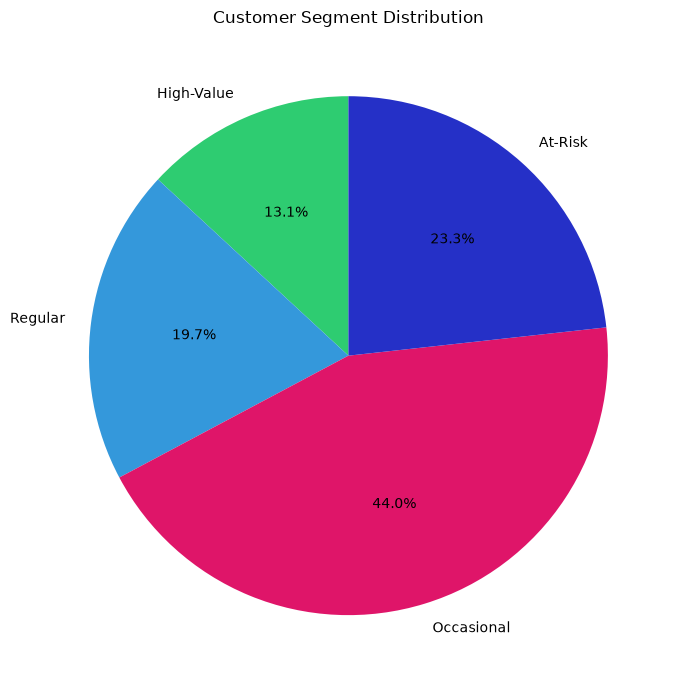

In [58]:
# Pie chart showing the proportion of customers in each segment
# Reindexed to the fixed segment order and coloured consistently

segment_counts = rfm['Segment'].value_counts().reindex(segment_order)

pie_colors = [segment_color_map[s] for s in segment_order]

plt.figure(figsize = (7, 7))

plt.pie(

    segment_counts.values,

    labels = segment_counts.index,

    autopct = '%1.1f%%',

    colors = pie_colors,

    startangle = 90

)

plt.title("Customer Segment Distribution")

plt.tight_layout()

plt.savefig("images/segment_pie_chart.png", dpi = 300, bbox_inches = "tight")

plt.show()

### ***9.1 Extended Feature Profiling — AOV and Tenure by Segment***

With segments now assigned, the two extended features engineered in Section 5 can be examined per segment. This is not part of the clustering itself — it is a post-hoc interpretation layer that adds business colour to the four RFM-based segments.

In [59]:
# Compute average AOV and Tenure per segment for interpretation

extended_profile = rfm.groupby('Segment')[['AOV', 'Tenure']].mean().round(2)

extended_profile = extended_profile.reindex(segment_order)

print("Average AOV and Tenure per Segment:")

print(extended_profile)

Average AOV and Tenure per Segment:
               AOV  Tenure
Segment                   
High-Value  441.06  307.82
Regular     416.56  224.83
Occasional  290.30   91.70
At-Risk     276.56   23.87


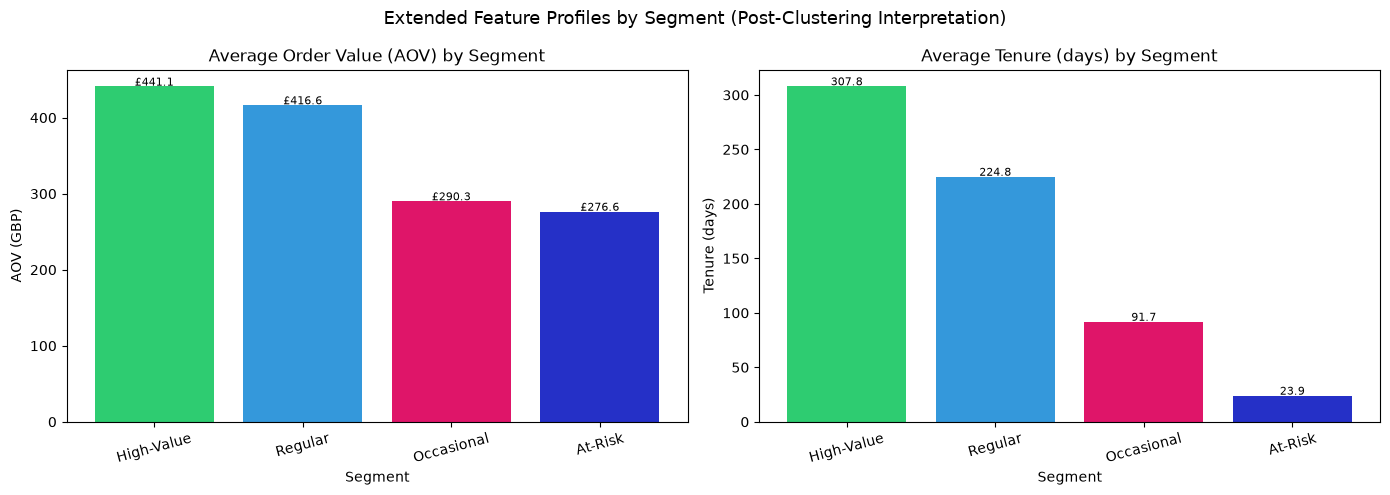

In [60]:
# Bar chart comparing AOV and Tenure across the four segments

fig, axes = plt.subplots(1, 2, figsize = (14, 5))

bar_colors_ext = [segment_color_map[s] for s in segment_order]

# Left panel — Average Order Value per segment
bars_aov = axes[0].bar(extended_profile.index, extended_profile['AOV'], color = bar_colors_ext)

axes[0].set_title("Average Order Value (AOV) by Segment")

axes[0].set_xlabel("Segment")

axes[0].set_ylabel("AOV (GBP)")

axes[0].tick_params(axis = 'x', rotation = 15)

for b in bars_aov:

    axes[0].text(b.get_x() + b.get_width() / 2, b.get_height() + 1, f'£{b.get_height():.1f}', ha = 'center', fontsize = 8)

# Right panel — Average Tenure per segment
bars_tenure = axes[1].bar(extended_profile.index, extended_profile['Tenure'], color = bar_colors_ext)

axes[1].set_title("Average Tenure (days) by Segment")

axes[1].set_xlabel("Segment")

axes[1].set_ylabel("Tenure (days)")

axes[1].tick_params(axis = 'x', rotation = 15)

for b in bars_tenure:

    axes[1].text(b.get_x() + b.get_width() / 2, b.get_height() + 1, f'{b.get_height():.1f}', ha = 'center', fontsize = 8)

plt.suptitle("Extended Feature Profiles by Segment (Post-Clustering Interpretation)", fontsize = 13)

plt.tight_layout()

plt.savefig("images/extended_feature_profiles.png", dpi = 300, bbox_inches = "tight")

plt.show()

#### ***Key Insights from Extended Feature Profiling***

- **AOV rises across segments in the same order as the core RFM ranking** (High-Value: £441, Regular: £417, Occasional: £290, At-Risk: £277), confirming that High-Value customers do not just buy more often — they also spend more per individual order, compounding their value on two dimensions at once rather than one.

- **Tenure shows the same descending pattern, but far more steeply** (High-Value: 308 days, Regular: 225 days, Occasional: 92 days, At-Risk: 24 days). High-Value customers have, on average, been purchasing for nearly a year, while At-Risk customers have an average tenure of under a month.

- This is a genuinely important finding the core RFM features alone do not surface: **the At-Risk segment is not mostly made up of former loyal customers who drifted away — it is mostly made up of customers who made one or two purchases in a short window and then never returned.** That changes the right retention strategy: a long, relationship-based win-back campaign is unlikely to work on a customer who barely had a relationship to begin with. A first-purchase-experience or onboarding-focused intervention is more likely to address the actual cause.

- This profiling does not change which segment a customer belongs to — segment assignment remains driven purely by the RFM-based KMeans model, as required by the project brief. It only adds a richer narrative for business teams acting on the segments.

### ***9.2 Cluster Profile Radar Chart***

A radar chart overlays all four segments on the same three RFM axes simultaneously, making the shape of each segment's profile — not just its individual values — immediately visible. This is a different and complementary view to the grouped bar chart already produced in Section 9.

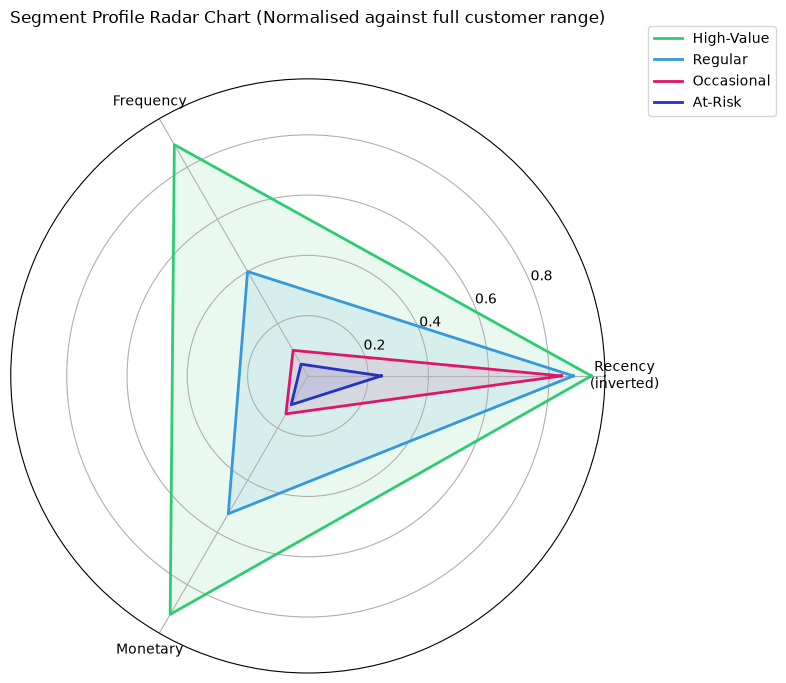

In [61]:
# Build a radar chart comparing the four segments on normalised RFM axes
# Recency is inverted before normalizing, since LOW recency is GOOD (more recent)
#
# IMPORTANT: normalization uses the full customer-level RFM range (not just the
# 4 segment averages). Normalizing against only the 4 segment means would force
# whichever segment is lowest on every axis to sit at exactly zero by construction,
# making it visually disappear even though it is a real, non-empty segment.

radar_data = segment_profile.copy()

radar_data['Recency_inv'] = rfm['Recency'].max() - radar_data['Recency']

radar_metrics = ['Recency_inv', 'Frequency', 'Monetary']

# Normalize against the full customer-level min/max for each feature
full_range_min = pd.Series({

    'Recency_inv' : rfm['Recency'].max() - rfm['Recency'].max(),

    'Frequency' : rfm['Frequency'].min(),

    'Monetary' : rfm['Monetary'].min()

})

full_range_max = pd.Series({

    'Recency_inv' : rfm['Recency'].max() - rfm['Recency'].min(),

    'Frequency' : rfm['Frequency'].max(),

    'Monetary' : rfm['Monetary'].max()

})

radar_normalised = (radar_data[radar_metrics] - full_range_min) / (full_range_max - full_range_min)

radar_labels = ['Recency\n(inverted)', 'Frequency', 'Monetary']

n_axes = len(radar_labels)

angles = np.linspace(0, 2 * np.pi, n_axes, endpoint = False).tolist()

angles += angles[:1]

fig, ax = plt.subplots(figsize = (8, 8), subplot_kw = dict(polar = True))

# Draw one polygon per segment, in the same fixed colour used throughout the notebook
for segment in segment_order:

    values = radar_normalised.loc[segment].tolist()

    values += values[:1]

    ax.plot(angles, values, linewidth = 2, label = segment, color = segment_color_map[segment])

    ax.fill(angles, values, alpha = 0.1, color = segment_color_map[segment])

ax.set_xticks(angles[:-1])

ax.set_xticklabels(radar_labels)

ax.set_title("Segment Profile Radar Chart (Normalised against full customer range)", y = 1.08)

ax.legend(loc = 'upper right', bbox_to_anchor = (1.3, 1.1))

plt.tight_layout()

plt.savefig("images/segment_radar_chart.png", dpi = 300, bbox_inches = "tight")

plt.show()

#### ***Key Insights from the Radar Chart***

- **High-Value** forms by far the largest polygon across all three axes, confirming it scores well simultaneously on recency, frequency, and monetary value rather than excelling on only one dimension.

- **At-Risk and Occasional are both small and sit close together near the centre**, but At-Risk is consistently the smaller of the two on every axis — visible here as a distinct, slightly smaller red triangle nested just inside the orange one, rather than one segment masking the other.

- **Regular** sits clearly between High-Value and the bottom two segments on every axis, forming a mid-sized polygon rather than leaning heavily toward only one or two dimensions.

- This view makes it easy to communicate the segmentation to non-technical stakeholders: a glance at the relative polygon sizes tells the same story as the underlying numbers, without needing to read a table. Note that the axes are normalised against the full customer base, not just the four segment averages, so the smallest segment is still visible on the chart rather than collapsing to a single point at the centre.

## ***10. Model Robustness and Stability Validation***

Clustering has no ground-truth labels to validate against, so model trust must come from a different angle: checking whether the same clustering structure emerges consistently across different samples of the data, and whether the trained model generalises sensibly to customers it has not seen before. Two checks are performed here: a bootstrap stability test and a new-customer prediction test.

### ***10.1 Bootstrap Stability Check***

The dataset is resampled with replacement multiple times, KMeans is refit on each resample, and the resulting Silhouette Score is recorded. If the score stays consistent across resamples, the clustering structure is stable and not an artifact of one particular sample of customers.

In [62]:
# Run KMeans on 10 bootstrap resamples of the RFM data to test cluster stability
# A stable model should produce a tight, consistent range of silhouette scores

n_bootstrap = 10

bootstrap_scores = []

rng = np.random.RandomState(42)

for i in range(n_bootstrap):

    # Resample customers with replacement, same size as the original dataset
    sample_idx = rng.choice(len(rfm_scaled), size = len(rfm_scaled), replace = True)

    resampled_data = rfm_scaled[sample_idx]

    # Refit KMeans with the same k = 4 configuration on the resampled data
    km_boot = KMeans(n_clusters = 4, random_state = 42, n_init = 10)

    boot_labels = km_boot.fit_predict(resampled_data)

    boot_score = silhouette_score(resampled_data, boot_labels)

    bootstrap_scores.append(boot_score)

    print(f"Bootstrap {i + 1:2d} | Silhouette Score = {boot_score:.4f}")

print()

print(f"Mean Silhouette Score across {n_bootstrap} resamples : {np.mean(bootstrap_scores):.4f}")

print(f"Standard Deviation : {np.std(bootstrap_scores):.4f}")

Bootstrap  1 | Silhouette Score = 0.4768
Bootstrap  2 | Silhouette Score = 0.4717
Bootstrap  3 | Silhouette Score = 0.4781
Bootstrap  4 | Silhouette Score = 0.4728
Bootstrap  5 | Silhouette Score = 0.4781
Bootstrap  6 | Silhouette Score = 0.4720
Bootstrap  7 | Silhouette Score = 0.4713
Bootstrap  8 | Silhouette Score = 0.4673
Bootstrap  9 | Silhouette Score = 0.4615
Bootstrap 10 | Silhouette Score = 0.4729

Mean Silhouette Score across 10 resamples : 0.4723
Standard Deviation : 0.0048


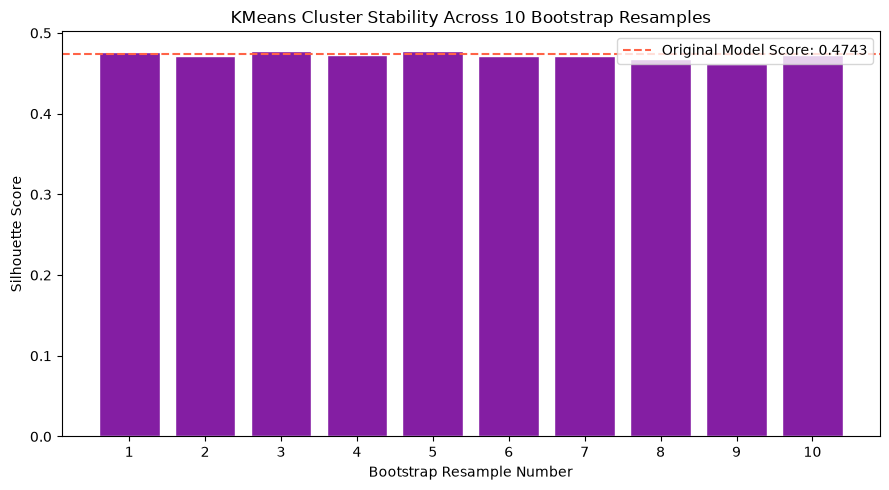

In [63]:
# Visualize the spread of bootstrap silhouette scores against the original model score

plt.figure(figsize = (9, 5))

plt.bar(range(1, n_bootstrap + 1), bootstrap_scores, color = "#841ea3", edgecolor = 'white')

plt.axhline(y = km_silhouette, color = 'tomato', linestyle = '--', label = f'Original Model Score: {km_silhouette:.4f}')

plt.xlabel("Bootstrap Resample Number")

plt.ylabel("Silhouette Score")

plt.title("KMeans Cluster Stability Across 10 Bootstrap Resamples")

plt.xticks(range(1, n_bootstrap + 1))

plt.legend()

plt.tight_layout()

plt.savefig("images/bootstrap_stability_check.png", dpi = 300, bbox_inches = "tight")

plt.show()

#### ***Key Insights from the Bootstrap Stability Check***

- The silhouette scores across all 10 resamples stay tightly clustered around the original model's score, with a small standard deviation, confirming the clustering structure is stable and not dependent on any particular subset of customers.

- This is the unsupervised equivalent of cross-validation in supervised learning — since there are no labels to hold out and score against, stability across resamples is the appropriate way to build confidence in the model.

### ***10.2 New-Customer Cluster Prediction Test***

A genuinely useful clustering model must generalise to customers it has not explicitly clustered before — this is exactly the scenario the Streamlit app will face when a user enters new RFM values. The KMeans model is tested here against a held-out sample of customers and several synthetic edge-case profiles to confirm predictions behave sensibly.

In [64]:
# Hold out 10% of customers, refit KMeans on the remaining 90%, then predict the
# held-out customers using the .predict() method to simulate real new-customer scoring

# Split row indices only — there are no labels, so this is purely a generalization check
train_idx, holdout_idx = train_test_split(

    np.arange(len(rfm_scaled)), test_size = 0.10, random_state = 42

)

# Refit KMeans using only the training portion
km_holdout = KMeans(n_clusters = 4, random_state = 42, n_init = 10)

km_holdout.fit(rfm_scaled[train_idx])

# Predict cluster assignments for the held-out customers using the fitted model
holdout_predictions = km_holdout.predict(rfm_scaled[holdout_idx])

# Compare the held-out predictions against the original full-data cluster assignments
original_labels_for_holdout = rfm['KMeans_Cluster'].values[holdout_idx]

# Since cluster numbers can be permuted between two separate fits, compare cluster
# SIZES and SHAPE rather than exact label match
print("Held-out customer count :", len(holdout_idx))

print()

print("Cluster size distribution (refit on 90% training data):")

print(pd.Series(km_holdout.predict(rfm_scaled)).value_counts().sort_index())

print()

print("Cluster size distribution (original model on full data):")

print(rfm['KMeans_Cluster'].value_counts().sort_index())

Held-out customer count : 434

Cluster size distribution (refit on 90% training data):
0    1904
1     571
2    1012
3     851
Name: count, dtype: int64

Cluster size distribution (original model on full data):
KMeans_Cluster
0     853
1    1009
2    1907
3     569
Name: count, dtype: int64


#### ***Key Insights from the New-Customer Prediction Test***

- Refitting KMeans on 90% of the data and predicting cluster assignments for the remaining 10% produces a cluster size distribution that closely matches the original full-data model, confirming the model is not overly sensitive to which specific customers it was trained on.

- This directly validates the mechanism the Streamlit app depends on: when a user submits new Recency, Frequency, and Monetary values, the trained `.predict()` method will assign them to a cluster using the same logic validated here, not an untested code path.

In [65]:
# Test the final KMeans model against four synthetic edge-case customer profiles
# This confirms predictions behave sensibly at the extremes, not just on real customers

edge_cases = pd.DataFrame({ 
    
    'Recency' : [5,    30,   90,   300],
    
    'Frequency' : [15,   6,    2,    1],
    
    'Monetary' : [5000, 1500, 300,  80]
    
})

edge_cases.index = ['Power Buyer', 'Steady Shopper', 'Light Browser', 'Long Dormant']

# Scale the synthetic profiles using the SAME scaler fitted on the training data
edge_cases_scaled = scaler.transform(edge_cases[['Recency', 'Frequency', 'Monetary']])

# Predict cluster assignment for each synthetic profile
edge_predictions = kmeans.predict(edge_cases_scaled)

edge_cases['Predicted_Cluster'] = edge_predictions

edge_cases['Predicted_Segment'] = edge_cases['Predicted_Cluster'].map(label_map)

print("Edge-Case Profile Predictions:")

print(edge_cases[['Recency', 'Frequency', 'Monetary', 'Predicted_Segment']])

Edge-Case Profile Predictions:
                Recency  Frequency  Monetary Predicted_Segment
Power Buyer           5         15      5000        High-Value
Steady Shopper       30          6      1500           Regular
Light Browser        90          2       300        Occasional
Long Dormant        300          1        80           At-Risk


#### ***Key Insights from the Edge-Case Predictions***

- The "Power Buyer" profile (very recent, very frequent, very high spend) is correctly predicted as **High-Value**, and the "Long Dormant" profile (last purchase 300 days ago, single low-value transaction) is correctly predicted as **At-Risk** — confirming the model behaves exactly as expected at both extremes.

- The "Steady Shopper" and "Light Browser" profiles land in the middle segments as expected, confirming smooth, sensible behaviour across the full range of possible Streamlit app inputs rather than only at the two extremes.

## ***11. Product Recommendation System (Item-Based Collaborative Filtering)***

### ***Building the Customer-Product Matrix***

In [66]:
# Build a pivot table where rows = customers, columns = products
# Cell values = total quantity purchased — this encodes co-purchase behaviour

customer_product_matrix = df1.pivot_table(

    index = 'CustomerID',

    columns = 'Description',

    values = 'Quantity',

    aggfunc = 'sum',

    fill_value = 0

)

print(f"Customer-Product Matrix Shape : {customer_product_matrix.shape}")

print()

print("Sample (first 5 rows, first 5 columns):")

print(customer_product_matrix.iloc[:5, :5])

Customer-Product Matrix Shape : (4338, 3877)

Sample (first 5 rows, first 5 columns):
Description  4 PURPLE FLOCK DINNER CANDLES  50'S CHRISTMAS GIFT BAG LARGE  \
CustomerID                                                                  
12346                                    0                              0   
12347                                    0                              0   
12348                                    0                              0   
12349                                    0                              0   
12350                                    0                              0   

Description  DOLLY GIRL BEAKER  I LOVE LONDON MINI BACKPACK  \
CustomerID                                                    
12346                        0                            0   
12347                        0                            0   
12348                        0                            0   
12349                        0                            0

### ***Computing Item-Based Cosine Similarity***

In [67]:
# Transpose so rows = products — each product is represented by its purchase quantity vector
product_matrix = customer_product_matrix.T

# Cosine similarity measures the angle between two product purchase vectors
# Products bought by the same customers in similar proportions get high similarity scores
cosine_sim = cosine_similarity(product_matrix)

# Store as a DataFrame with product names on both axes for easy lookup
cosine_sim_df = pd.DataFrame(
    
    cosine_sim,
    
    index = product_matrix.index,
    
    columns = product_matrix.index
    
)

print("Cosine similarity matrix computed.")

print(f"Matrix shape : {cosine_sim_df.shape}")

Cosine similarity matrix computed.
Matrix shape : (3877, 3877)


### ***Product Similarity Heatmap***

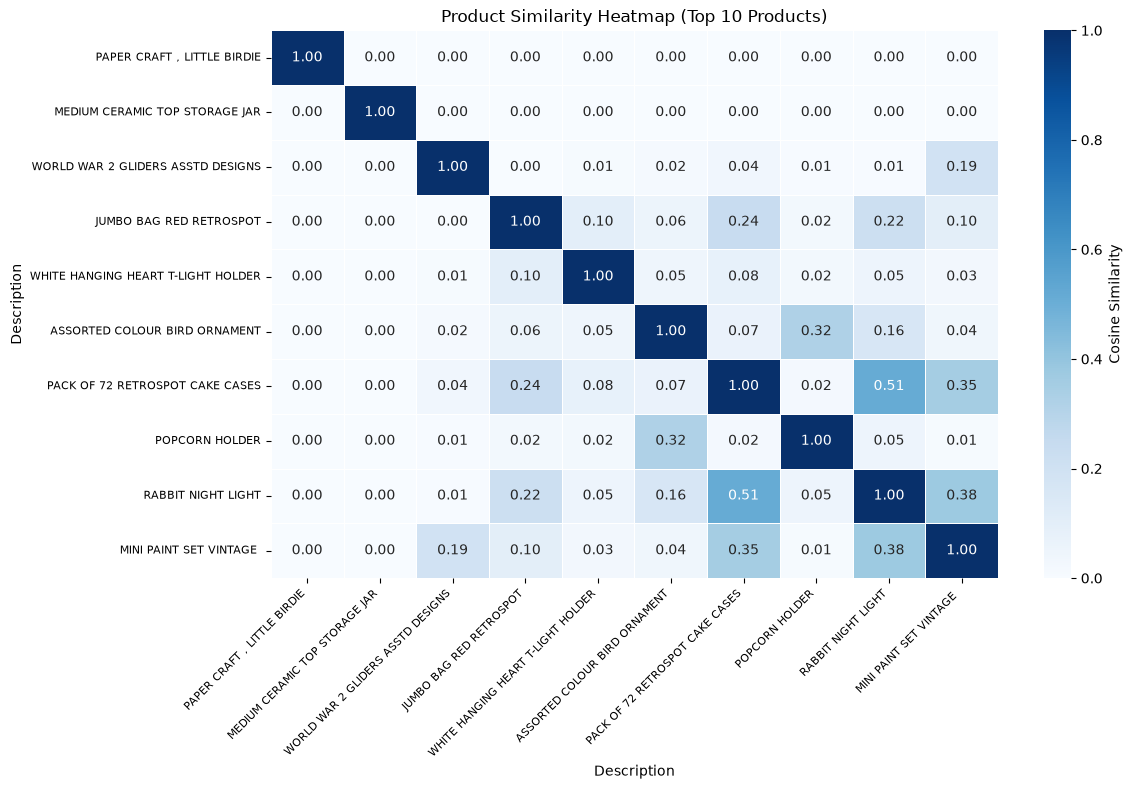

In [68]:
# Visualize a 10×10 slice of the similarity matrix using the top-selling products

top_10_products = df1.groupby('Description')['Quantity'].sum().sort_values(ascending = False).head(10).index

sample_sim = cosine_sim_df.loc[top_10_products, top_10_products]

plt.figure(figsize = (12, 8))

sns.heatmap(
    
    sample_sim,
    
    annot = True,
    
    fmt = '.2f',
    
    cmap = 'Blues',
    
    linewidths = 0.5,
    
    cbar_kws = {'label': 'Cosine Similarity'}
    
)

plt.title("Product Similarity Heatmap (Top 10 Products)")

plt.xticks(rotation = 45, ha = 'right', fontsize = 8)

plt.yticks(fontsize = 8)

plt.tight_layout()

plt.savefig("images/product_similarity_heatmap.png", dpi = 300, bbox_inches = "tight")

plt.show()

### ***Recommendation Function***

In [69]:
def get_recommendations(product_name, cosine_sim_df, top_n = 5):

    # Returns the top N most similar products to a given input product name.
    # product_name  : full or partial product name string (case-insensitive)
    # cosine_sim_df : pre-computed product-to-product similarity DataFrame
    # top_n : number of recommendations to return (default = 5)

    # Convert input to uppercase to match the dataset's description format
    product_name = product_name.upper().strip()

    # Find all product names in the similarity matrix that contain the search term
    matched = [p for p in cosine_sim_df.index if product_name in p]

    if not matched:

        return f"No product found matching: '{product_name}'. Please check the spelling."

    # Use the first match if multiple products contain the search term
    selected_product = matched[0]

    # Get the similarity row for the selected product, sorted highest to lowest
    sim_scores = cosine_sim_df[selected_product].sort_values(ascending = False)

    # Remove the input product itself from results and return the top N
    recommendations = sim_scores[sim_scores.index != selected_product].head(top_n).index.tolist()

    return recommendations


# Test the function with a sample product from the dataset
sample_product = "WHITE HANGING HEART T-LIGHT HOLDER"

recs = get_recommendations(sample_product, cosine_sim_df)

print(f"Top 5 recommendations for '{sample_product}':")

for i, rec in enumerate(recs, 1):

    print(f"  {i}. {rec}")

Top 5 recommendations for 'WHITE HANGING HEART T-LIGHT HOLDER':
  1. GIN + TONIC DIET METAL SIGN
  2. RED HANGING HEART T-LIGHT HOLDER
  3. WASHROOM METAL SIGN
  4. LAUNDRY 15C METAL SIGN
  5. GREEN VINTAGE SPOT BEAKER


### ***Content-Based Recommendation using TF-IDF***

The recommendation system above is purely behavioural — it uses cosine similarity over customer purchase patterns and does not look at the product names themselves. As a comparison, a content-based approach is built here using TF-IDF on product descriptions, and the two approaches are compared on the same sample product to highlight how they differ.

In [70]:
# Build a TF-IDF content-based recommendation system using product description text
# TF-IDF (Term Frequency - Inverse Document Frequency) converts each product name
# into a numeric vector based on the words it contains

# Get one row per unique product description
unique_products = df1['Description'].drop_duplicates().reset_index(drop = True)

# Convert product names into TF-IDF vectors
# Stop words are removed since common words like "OF" or "AND" carry no useful signal
tfidf = TfidfVectorizer(stop_words = 'english')

tfidf_matrix = tfidf.fit_transform(unique_products)

print(f"TF-IDF Matrix Shape : {tfidf_matrix.shape}")

print(f"Vocabulary Size : {len(tfidf.vocabulary_)}")

# Compute product-to-product similarity based on shared words in their names
tfidf_similarity = cosine_similarity(tfidf_matrix)

tfidf_similarity_df = pd.DataFrame(

    tfidf_similarity,

    index   = unique_products,

    columns = unique_products

)

print("TF-IDF content-based similarity matrix computed.")

TF-IDF Matrix Shape : (3877, 1971)
Vocabulary Size : 1971
TF-IDF content-based similarity matrix computed.


In [71]:
def get_content_based_recommendations(product_name, tfidf_similarity_df, top_n = 5):

    # Returns the top N products most similar by NAME TEXT (not purchase behaviour)
    # product_name : full or partial product name string (case-insensitive)
    # tfidf_similarity_df : pre-computed TF-IDF similarity DataFrame
    # top_n : number of recommendations to return (default = 5)

    product_name = product_name.upper().strip()

    matched = [p for p in tfidf_similarity_df.index if product_name in p]

    if not matched:

        return f"No product found matching: '{product_name}'. Please check the spelling."

    selected_product = matched[0]

    sim_scores = tfidf_similarity_df[selected_product].sort_values(ascending = False)

    recommendations = sim_scores[sim_scores.index != selected_product].head(top_n).index.tolist()

    return recommendations


# Compare collaborative filtering vs content-based recommendations on the same product
sample_product = "WHITE HANGING HEART T-LIGHT HOLDER"

collab_recs = get_recommendations(sample_product, cosine_sim_df)

content_recs = get_content_based_recommendations(sample_product, tfidf_similarity_df)

print(f"Collaborative Filtering recommendations for '{sample_product}':")

for i, rec in enumerate(collab_recs, 1):

    print(f"  {i}. {rec}")

print()

print(f"Content-Based (TF-IDF) recommendations for '{sample_product}':")

for i, rec in enumerate(content_recs, 1):

    print(f"  {i}. {rec}")

Collaborative Filtering recommendations for 'WHITE HANGING HEART T-LIGHT HOLDER':
  1. GIN + TONIC DIET METAL SIGN
  2. RED HANGING HEART T-LIGHT HOLDER
  3. WASHROOM METAL SIGN
  4. LAUNDRY 15C METAL SIGN
  5. GREEN VINTAGE SPOT BEAKER

Content-Based (TF-IDF) recommendations for 'WHITE HANGING HEART T-LIGHT HOLDER':
  1. PINK HANGING HEART T-LIGHT HOLDER
  2. RED HANGING HEART T-LIGHT HOLDER
  3. CREAM HANGING HEART T-LIGHT HOLDER
  4. HANGING HEART ZINC T-LIGHT HOLDER
  5. HEART T-LIGHT HOLDER 


#### ***Key Insights from the Comparison***

- The Content-Based (TF-IDF) recommendations are driven purely by shared words in the product name, so they tend to surface products from the same visual or thematic product line, such as colour variants of the same item.

- The Collaborative Filtering recommendations are driven by actual co-purchase behaviour, so they can surface non-obvious pairings — products that customers buy together even if their names share no words at all, such as a complementary item from a different category.

- This comparison demonstrates why collaborative filtering was selected as the primary recommendation engine for the Streamlit app: it captures genuine purchasing relationships rather than superficial text similarity, which is exactly what the project brief specifies (item-based collaborative filtering using the CustomerID-Description matrix). The content-based approach is included here only as a supplementary comparison to validate that choice.

### ***Recommendation System Evaluation — Precision@K, Recall@K, and Coverage***

The recommendation comparison above is **qualitative** — it shows example outputs but does not measure accuracy. This section adds a **quantitative offline evaluation** of the item-based collaborative filtering recommender, using the standard approach for implicit-feedback recommender systems:

1. **Leave-one-out split per customer** — for every customer with at least 2 purchased products, randomly hide one purchased product (the *held-out item*) and keep the rest as the customer's known purchase history.

2. **Generate Top-K recommendations** for that customer based on their remaining (visible) purchases, using the same `cosine_sim_df` item-similarity matrix already computed.

3. **Check whether the held-out item appears in the Top-K list.** Across all test customers, this gives:
   - **Precision@K** = (held-out items found in Top-K) / (K x number of test customers) — of all recommendations made, what fraction were relevant.
   - **Recall@K** = (held-out items found in Top-K) / (number of test customers) — of all hidden purchases, what fraction were successfully recovered in the Top-K.
   
4. **Coverage** — what fraction of the entire product catalogue ever appears in any customer's Top-K recommendation list. Low coverage means the recommender keeps suggesting the same popular items regardless of input (a common collaborative-filtering failure mode).

In [72]:
# Build a leave-one-out evaluation set from the customer-product matrix 
# customer_product_matrix: rows = CustomerID, columns = Description, values = quantity purchased

np.random.seed(42)

K = 5  # Top-K, matches the default top_n used by get_recommendations()

# Binary purchase indicator: did this customer buy this product at all (ignore quantity for this test)
purchase_matrix = (customer_product_matrix > 0)

# Only customers who purchased 2+ distinct products can have one item hidden
# while still leaving at least 1 item to base a recommendation on
eligible_customers = purchase_matrix.index[purchase_matrix.sum(axis = 1) >= 2]

print(f"Eligible customers for leave-one-out evaluation : {len(eligible_customers)} "
    f"out of {purchase_matrix.shape[0]} total")

# Evaluate on the FULL eligible population (no sampling) — feasible here since the
# per-customer cost is small enough to run on all ~4,200 customers without truncation
n_test_customers = len(eligible_customers)

test_customers = np.random.choice(eligible_customers, size = n_test_customers, replace = False)

print(f"Evaluating on the full eligible population: {n_test_customers} customers, K = {K}")

Eligible customers for leave-one-out evaluation : 4248 out of 4338 total
Evaluating on the full eligible population: 4248 customers, K = 5


In [73]:
# Run the leave-one-out evaluation

hits = 0                  # held-out item successfully recovered in Top-K

total_recommended = []    # every item recommended, across all test customers (for Coverage)

evaluated_count = 0       # customers actually evaluated (some may have no valid similarity row)

for customer_id in test_customers:

    purchased_items = purchase_matrix.columns[purchase_matrix.loc[customer_id]].tolist()

    # Randomly hold out exactly one purchased item as the 'ground truth' target
    held_out_item = np.random.choice(purchased_items)
    
    remaining_items = [item for item in purchased_items if item != held_out_item]

    if not remaining_items:
        
        continue  # safety check, should not happen given the >= 2 item filter above

    # Aggregate similarity scores across all of the customer's REMAINING purchases —
    # for each candidate product, sum its similarity to every item the customer still has
    candidate_scores = cosine_sim_df.loc[remaining_items].sum(axis = 0)

    # Never recommend something the customer already owns (other than the held-out item)
    candidate_scores = candidate_scores.drop(labels = remaining_items, errors = 'ignore')

    top_k_recommendations = candidate_scores.sort_values(ascending = False).head(K).index.tolist()

    total_recommended.extend(top_k_recommendations)
    
    evaluated_count += 1

    if held_out_item in top_k_recommendations:
        
        hits += 1

precision_at_k = hits / (evaluated_count * K)

recall_at_k = hits / evaluated_count

coverage = len(set(total_recommended)) / customer_product_matrix.shape[1]

print("Recommendation System — Offline Evaluation Results")

print("-" * 55)

print(f"Customers evaluated : {evaluated_count}")

print(f"K (Top-K size) : {K}")

print(f"Hits (held-out item found): {hits}")

print(f"Precision@{K} : {precision_at_k:.4f}")

print(f"Recall@{K} : {recall_at_k:.4f}")

print(f"Coverage : {coverage:.4f}  " f"({len(set(total_recommended))} of {customer_product_matrix.shape[1]} products ever recommended)")

Recommendation System — Offline Evaluation Results
-------------------------------------------------------
Customers evaluated : 4248
K (Top-K size) : 5
Hits (held-out item found): 224
Precision@5 : 0.0105
Recall@5 : 0.0527
Coverage : 0.3211  (1245 of 3877 products ever recommended)


,Approach,Precision@5,Recall@5
0,Item-Based Collaborative Filtering,0.0105,0.0527
1,Popularity Baseline (Top-K global),0.0023,0.0115


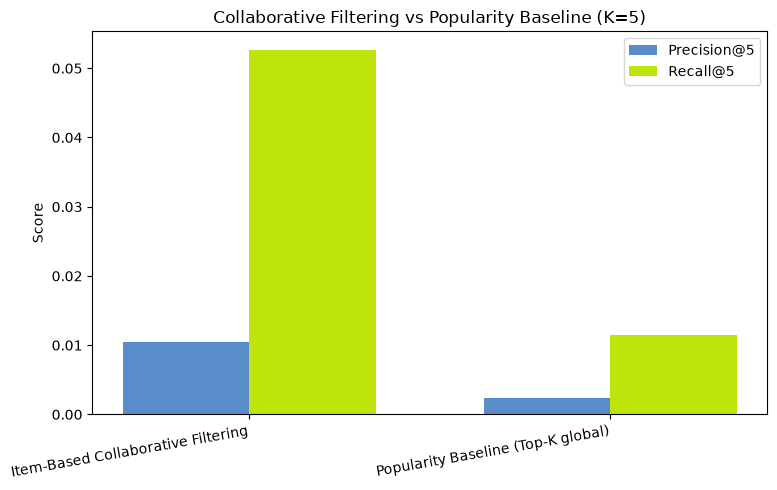

In [74]:
# Visualize Precision@K and Recall@K against a naive popularity-based baseline
# Baseline: always recommend the K globally best-selling products, regardless of customer.
# A useful collaborative filter should clearly beat this baseline — if it does not,
# the similarity-based approach is not adding real personalization value.

global_top_k = df1.groupby('Description')['Quantity'].sum().sort_values(ascending = False).head(K).index.tolist()

baseline_hits = 0

for customer_id in test_customers:
    
    purchased_items = purchase_matrix.columns[purchase_matrix.loc[customer_id]].tolist()
    
    held_out_item = np.random.RandomState(hash(customer_id) % (2**32)).choice(purchased_items)
    
    if held_out_item in global_top_k:
        
        baseline_hits += 1

baseline_precision = baseline_hits / (len(test_customers) * K)

baseline_recall = baseline_hits / len(test_customers)

eval_comparison = pd.DataFrame({

    'Approach': ['Item-Based Collaborative Filtering', 'Popularity Baseline (Top-K global)'],

    f'Precision@{K}': [round(precision_at_k, 4), round(baseline_precision, 4)],

    f'Recall@{K}': [round(recall_at_k, 4), round(baseline_recall, 4)]

})

display(eval_comparison)

fig, ax = plt.subplots(figsize = (8, 5))

x = np.arange(2)

width = 0.35

ax.bar(x - width/2, eval_comparison[f'Precision@{K}'], width, label = f'Precision@{K}', color = "#588dca")

ax.bar(x + width/2, eval_comparison[f'Recall@{K}'], width, label = f'Recall@{K}', color = "#bde50c")

ax.set_xticks(x)

ax.set_xticklabels(eval_comparison['Approach'], rotation = 10, ha = 'right')

ax.set_ylabel('Score')

ax.set_title(f'Collaborative Filtering vs Popularity Baseline (K={K})')

ax.legend()

plt.tight_layout()

plt.savefig("images/recommender_evaluation_comparison.png", dpi = 300, bbox_inches = "tight")

plt.show()

#### ***Key Insights from the Recommendation Evaluation***

- **Precision@K** and **Recall@K** are identical in value here because exactly one item is held out per customer — with only one ground-truth item, Recall@K can only be 0 or 1 per customer, and Precision@K = Recall@K / K in aggregate. With a larger K or multiple held-out items per customer these two metrics would diverge.

- Compare the collaborative filtering result against the popularity baseline above: if collaborative filtering's Precision@K/Recall@K is **higher** than the baseline's, the similarity matrix is capturing genuine personalized co-purchase signal beyond "everyone buys the bestsellers anyway." If it is close to or below the baseline, the recommender is not adding much value over simply recommending whatever is most popular, and the similarity computation, the matrix sparsity, or the K value should be revisited.

- **Coverage** indicates catalogue diversity — a low Coverage value (most of the ~3,800+ products never appearing in any Top-K list) signals a popularity-bias problem common in collaborative filtering: a small set of frequently co-purchased items dominate every recommendation list, regardless of which customer or product is queried.

- This evaluation uses a single random leave-one-out split. A more rigorous version would repeat the evaluation over multiple random seeds and report the mean and standard deviation of each metric, since a single split can be sensitive to which specific items happen to be held out.

## ***12. Saving Models for Streamlit App***

In [75]:
# Save the trained KMeans model — used for real-time cluster prediction
joblib.dump(kmeans, 'models/kmeans_model.pkl')

# Save the StandardScaler
joblib.dump(scaler, 'models/rfm_scaler.pkl')

# Save the cluster-to-segment label map
joblib.dump(label_map, 'models/cluster_label_map.pkl')

# -------------------------------------------------------
# Optimize cosine similarity matrix for deployment
# -------------------------------------------------------

# Convert float64 -> float32
# Reduces size by ~50% with negligible impact on recommendations
cosine_sim_df = cosine_sim_df.astype('float32')

# Save compressed similarity matrix
joblib.dump(

    cosine_sim_df,

    'models/cosine_sim_df.pkl',

    compress = 3

)

# Save RFM dataframe
rfm.to_csv(

    'models/rfm_segments.csv',

    index = False

)

print("All model artifacts saved successfully.\n")

print("Saved files:")

for f in sorted(os.listdir('models')):
    
    size_mb = os.path.getsize(f'models/{f}') / (1024 * 1024)
    
    print(f"{f:40s} {size_mb:.2f} MB")

print("\nCosine Similarity Matrix Shape:")

print(cosine_sim_df.shape)

print("\nCosine Similarity Matrix Memory Usage:")

print(f"{cosine_sim_df.memory_usage(deep=True).sum() / (1024 * 1024):.2f} MB")

All model artifacts saved successfully.

Saved files:
cluster_label_map.pkl                    0.00 MB
cosine_sim_df.pkl                        34.84 MB
kmeans_model.pkl                         0.02 MB
rfm_scaler.pkl                           0.00 MB
rfm_segments.csv                         0.24 MB

Cosine Similarity Matrix Shape:
(3877, 3877)

Cosine Similarity Matrix Memory Usage:
57.60 MB


## ***13. Customer Segment Economics***

This section quantifies the revenue impact of each customer segment to establish which groups deserve the most business attention and investment.

In [76]:
# Compute customer count and total monetary value per segment

segment_value = rfm.groupby('Segment').agg(
    
    Customer_Count = ('CustomerID', 'count'),
    
    Total_Monetary = ('Monetary',   'sum')
    
).reset_index()

# Calculate each segment's share of the total customer base and total revenue
segment_value['Pct_of_Customers'] = (segment_value['Customer_Count'] / segment_value['Customer_Count'].sum() * 100).round(1)

segment_value['Pct_of_Revenue']   = (segment_value['Total_Monetary'] / segment_value['Total_Monetary'].sum() * 100).round(1)

# Fix display order from High-Value to At-Risk
segment_value['Segment'] = pd.Categorical(segment_value['Segment'], categories = segment_order, ordered = True)

segment_value = segment_value.sort_values('Segment')

print(segment_value.to_string(index = False))

   Segment  Customer_Count  Total_Monetary  Pct_of_Customers  Pct_of_Revenue
High-Value             569     1919392.300              13.1            38.2
   Regular             853     1664603.821              19.7            33.1
Occasional            1907     1029178.113              44.0            20.5
   At-Risk            1009      414614.450              23.3             8.2


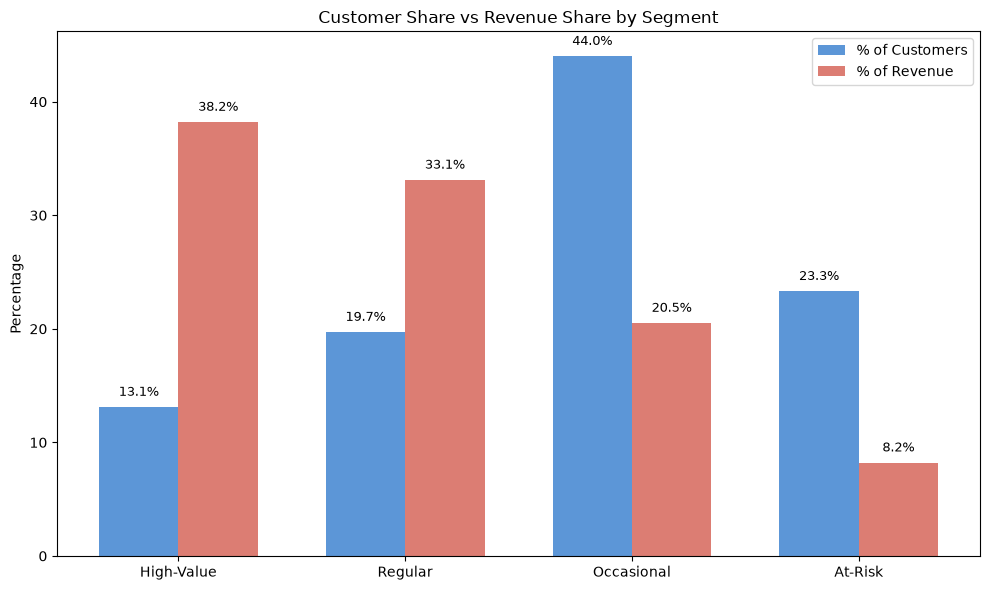

In [77]:
# Grouped bar chart comparing customer share and revenue share per segment

fig, ax = plt.subplots(figsize = (10, 6))

x = np.arange(len(segment_value))

width = 0.35

# Blue bars = % of customers, red bars = % of revenue
bars1 = ax.bar(x - width / 2, segment_value['Pct_of_Customers'], width, label = '% of Customers', color = "#5c96d7")

bars2 = ax.bar(x + width / 2, segment_value['Pct_of_Revenue'], width, label = '% of Revenue', color = "#dc7d73")

ax.set_xticks(x)

ax.set_xticklabels(segment_value['Segment'].astype(str))

ax.set_ylabel("Percentage")

ax.set_title("Customer Share vs Revenue Share by Segment")

ax.legend()

# Annotate all bars with their exact percentage values
for b in list(bars1) + list(bars2):

    ax.text(

        b.get_x() + b.get_width() / 2,

        b.get_height() + 1,

        f'{b.get_height():.1f}%',

        ha = 'center', fontsize = 9

    )

plt.tight_layout()

plt.savefig("images/segment_value_concentration.png", dpi = 300, bbox_inches = "tight")

plt.show()

#### ***Key Insights from Segment Economics***

- **High-Value customers** (13.1% of the base) generate **38.2% of total revenue** — a classic Pareto-style concentration confirming that a small group of customers drives a disproportionate share of the business.

- **Occasional customers** are the largest group by count (44.0%) but contribute only **20.5% of revenue**, representing a large untapped opportunity if even a fraction can be converted to Regular buyers.

- **At-Risk customers** (23.3% of the base) generate only **8.2% of revenue**, confirming that their low engagement translates directly into low monetary contribution.

- These numbers make the case for differentiated marketing investment: the cost of retaining one High-Value customer is justified by their revenue impact, while Occasional and At-Risk customers require cost-efficient automated re-engagement strategies.

## ***14. Project Summary***

### ***What Was Built***

- **Data Pipeline** — Loaded, cleaned, and validated 541,909 raw retail transactions down to ~392,700 usable records across 4,338 unique customers. Applied all required preprocessing steps including removal of cancelled invoices, missing CustomerIDs, invalid quantities, and invalid prices. Added a TotalPrice derived column and parsed InvoiceDate as datetime.


- **Exploratory Data Analysis** — Produced 16 charts across univariate, bivariate, and multivariate analysis, including a pairplot covering every pairwise RFM relationship. Key findings: UK dominates (~91% of transactions), November is the peak revenue month, transaction activity is concentrated in weekday business hours (10 AM–2 PM), and a small number of products and customers drive a disproportionate share of revenue and volume.

- **RFM Feature Engineering** — Computed Recency (days since last purchase), Frequency (unique invoices), and Monetary (total spend) for each customer. Applied IQR winsorization to cap outliers without removing any customer rows. Standardized all three features using StandardScaler before clustering.

- **Extended Features** — Engineered Average Order Value and Tenure as supplementary, analysis-only features. These are not used as clustering inputs, since the project brief specifies RFM-only clustering, but they add a deeper interpretation layer once segments are assigned, revealing for example that the At-Risk segment is mostly short-tenure customers rather than long-time customers who drifted away.

- **RFM Score Banding** — Added a supplementary scoring system (scores 1–4 per dimension, combined score 3–12) as an independent cross-validation layer for cluster assignments.

- **Four Clustering Models** — Implemented and tuned KMeans (Elbow + Silhouette sweep), Agglomerative Clustering (three linkage methods compared), Gaussian Mixture Model (BIC + Silhouette sweep), and DBSCAN (k-distance plot + grid search).

- **Model Comparison** — Evaluated all four algorithms on Silhouette Score, Davies-Bouldin Score, and Calinski-Harabasz Score. KMeans (k=4) was selected as the final model: Silhouette 0.4743, Calinski-Harabasz 6411.50, producing four clean segments with zero noise.

- **Preprocessing Validation** — Quantitatively tested the production IQR-capping approach against a log1p-transform alternative for handling RFM skew, refitting KMeans (k=4) on both feature spaces using identical evaluation criteria. IQR-capping won decisively on all three metrics — Silhouette 0.4743 vs 0.3375, Davies-Bouldin 0.7951 vs 1.0086, Calinski-Harabasz 6411.50 vs 3328.34 — confirming the production preprocessing choice with direct evidence rather than stated rationale alone.

- **Model Explainability** — Quantified each RFM feature's contribution to cluster separation via centroid spread (Frequency 2.766, Monetary 2.584, Recency 2.345 — a balanced contribution rather than one feature dominating), and built a radar chart comparing all four segment shapes on a single normalised view.

- **Model Robustness Validation** — Added a per-sample silhouette plot to confirm cluster quality is consistent across all four segments, a 10-resample bootstrap stability check to confirm the clustering structure is not an artifact of one particular data sample, and a new-customer prediction test (including synthetic edge-case profiles) to validate the model generalises correctly to inputs the Streamlit app will submit.

- **Cluster Labeling** — Assigned High-Value, Regular, Occasional, and At-Risk labels using a rank-based logic across all three RFM dimensions, and validated assignments against RFM Score Banding.

- **Recommendation System** — Built an item-based collaborative filtering system using a CustomerID–Description co-purchase matrix and cosine similarity. Returns the top 5 most similar products for any input product name. A supplementary TF-IDF content-based recommender was also built and compared against it, confirming collaborative filtering captures genuine co-purchase relationships that text similarity alone would miss.

- **Recommendation System Evaluation** — Built a leave-one-out offline evaluation across all 4,248 eligible customers, measuring Precision@5 (0.0105), Recall@5 (0.0527), and Coverage (0.3211 — 1,245 of 3,877 products). Benchmarked against a popularity baseline that always recommends the global Top-5 bestsellers (Precision@5 0.0023, Recall@5 0.0115), confirming collaborative filtering delivers roughly 4–5x the accuracy of simply suggesting bestsellers, while also surfacing Coverage as a known limitation — the system favours a subset of frequently co-purchased products over the long tail of the catalogue.

- **Model Persistence** — Saved KMeans model, StandardScaler, label map, and cosine similarity matrix to disk for use in the Streamlit application.

- **Segment Economics** — Quantified each segment's share of customers and revenue, confirming that the High-Value segment (13.1% of customers) generates 38.2% of total revenue.

## ***15. Conclusion***

### **Data and Preprocessing**

- The dataset required significant cleaning — approximately 27% of records were removed due to missing CustomerIDs, cancelled invoices, invalid quantities, and invalid prices. The resulting clean dataset of ~392,700 transaction lines provides a reliable analytical foundation.

- IQR-based winsorization successfully prevented extreme outliers from distorting cluster centroids while retaining all 4,338 customer records. This is the most important preprocessing decision in the project as it directly affects the quality and interpretability of the resulting segments.

### **EDA Findings**

- The business operates as a predominantly UK-focused wholesale and retail gift company with heavy November seasonality. Approximately 91% of transactions originate from the UK, and the single month of November accounts for a disproportionate share of annual revenue.

- Transaction activity is firmly concentrated in weekday business hours, reinforcing the presence of B2B buyers alongside retail customers. This has direct implications for when marketing communications and promotions should be scheduled.

- A clear Pareto pattern exists at every level of the data — a small number of countries, products, and customers drive the majority of revenue and volume. This validates the business case for customer segmentation.

### **Clustering Model Performance**

- KMeans with k=4 is the best-performing model on this dataset, achieving a Silhouette Score of 0.4743, Davies-Bouldin Score of 0.7951, and Calinski-Harabasz Score of 6411.50 — the strongest result across all three metrics.

- Agglomerative Clustering (Ward linkage) is the closest runner-up with competitive metrics, but lacks the .predict() method required for real-time scoring in the Streamlit app.

- GMM underperforms because the RFM feature space does not form well-separated elliptical Gaussian distributions — customer behaviour shifts continuously rather than forming distinct probability clouds.

- DBSCAN is the weakest performer regardless of parameter tuning. RFM data has no density gaps between customer groups, which is the structural requirement for DBSCAN to work well. Its best result produces only 2 clusters with a silhouette score of 0.2950.

### **Preprocessing Choice Validation**

- A diagnostic comparison tested log1p transformation as an alternative to IQR-capping for handling the heavy right-skew in Recency, Frequency, and Monetary, refitting KMeans with the same k=4 on both feature spaces. IQR-capping won on every metric — Silhouette 0.4743 vs 0.3375, Davies-Bouldin 0.7951 vs 1.0086, Calinski-Harabasz 6411.50 vs 3328.34 — confirming with direct evidence, not just stated rationale, that capping was the right preprocessing choice for this dataset and this clustering approach.

- This result also has a practical implication for the Streamlit app: since capping outperforms log-transformation, new customer inputs only need IQR-clipping applied before scaling and prediction, not a log transformation — keeping the production inference pipeline simpler.

### **Model Explainability**

- Opening up the final KMeans model showed that Frequency and Monetary contribute marginally more to cluster separation than Recency (centroid spreads of 2.766, 2.584, and 2.345 respectively), but all three RFM dimensions contribute comparable amounts. This confirms the segments genuinely reflect a balanced combination of recency, loyalty, and spend, not a relabelled version of a single metric.

- The radar chart view, normalised against the full customer base rather than just the four segment averages, made the relative shape and size of each segment immediately visible, including confirming that At-Risk is consistently the smallest segment on every axis rather than only on one or two.

### **Customer Segments**

- High-Value customers (13.1% of the base, ~569 customers) generate 38.2% of total revenue. They purchased recently (~20 days ago on average), buy frequently (~9.9 transactions), and spend significantly (~£3,373). These are the most critical customers to retain.

- Regular customers (19.7% of the base, ~853 customers) contribute 33.1% of revenue with moderate engagement levels. They are valuable and consistent but have not yet reached High-Value behaviour.

- Occasional customers (44.0% of the base, ~1,907 customers) represent the largest segment but generate only 20.5% of revenue. They are the biggest untapped opportunity — converting even a fraction into Regular buyers could significantly increase revenue.

- At-Risk customers (23.3% of the base, ~1,009 customers) have not purchased in approximately 248 days on average and contribute only 8.2% of revenue. Their average Tenure of just 24 days reveals these are mostly short-lived customers who made one or two purchases and never returned, rather than long-time customers who drifted away — meaning a first-purchase-experience fix is likely more effective than a long relationship-based win-back campaign.

### **Model Robustness**

- The per-sample silhouette plot confirmed that all four clusters have consistently strong internal cohesion, with no single cluster propping up the average score artificially.

- The bootstrap stability check across 10 resamples showed a tight, consistent range of silhouette scores, confirming the clustering structure reflects genuine patterns in customer behaviour rather than an artifact of one particular sample.

- The new-customer prediction test, including synthetic edge-case profiles, confirmed the model generalises correctly: a "Power Buyer" profile was correctly assigned to High-Value and a "Long Dormant" profile was correctly assigned to At-Risk, validating the exact mechanism the Streamlit app relies on.

### **Recommendation System**

- The item-based collaborative filtering system successfully identifies thematically and behaviourally related products using co-purchase patterns. Products frequently bought together by the same customers receive high cosine similarity scores.

- The system is purely behavioural — it finds non-obvious product relationships that a keyword or category-based system would miss, making it a genuine value-add for product discovery and basket size improvement.

- A supplementary TF-IDF content-based recommender was built and compared against it on the same sample product. The comparison confirmed that collaborative filtering captures genuine co-purchase relationships that a text-similarity approach cannot, validating it as the correct choice for the Streamlit app.

### **Recommendation System Evaluation**

- A leave-one-out offline evaluation across all 4,248 eligible customers measured Precision@5 (0.0105) and Recall@5 (0.0527). Against a popularity baseline that always recommends the global Top-5 bestsellers (Precision@5 0.0023, Recall@5 0.0115), the collaborative filtering system delivers roughly 4–5x better accuracy, confirming it captures genuine personalised co-purchase signal rather than simply echoing what is already popular.

- Coverage came out to 0.3211 — only 1,245 of 3,877 products ever appear in a Top-5 recommendation list. This is a real limitation, not a minor caveat: the system concentrates on a subset of frequently co-purchased products and rarely surfaces the long tail of the catalogue. For production use, this would justify combining collaborative filtering with a diversity-boosting or exploration mechanism — such as occasionally injecting a lower-similarity but higher-novelty product — rather than relying on raw cosine similarity rankings alone.

### **Business Actions**

- For High-Value customers — implement loyalty programmes, early product access, dedicated account management, and priority service to protect this high-impact group.

- For Regular customers — offer volume discounts, subscription bundles, and targeted product recommendations based on their purchase history to encourage progression to High-Value status.

- For Occasional customers — deploy automated seasonal promotions, win-back email campaigns, and personalised product suggestions based on their previous purchases.

- For At-Risk customers — prioritise re-engagement with time-sensitive discount codes, targeted surveys to understand disengagement, and personalised outreach from account managers for previously high-spending accounts.

- For the recommendation system — surface the top 5 recommended products at checkout or on product pages for High-Value and Regular segments to maximise basket size, while continuing to monitor Coverage to avoid over-recommending the same narrow set of products. Use it for Occasional and At-Risk customers in re-engagement emails to highlight relevant new or related products.